In [188]:
import matplotlib.pyplot as plt  
import numpy as np               
import pandas as pd              
import seaborn as sns           

sns.set()

import warnings
from itertools import product
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import scipy.stats as scs
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.tsa.api as smt
from dateutil.relativedelta import relativedelta
from scipy.optimize import minimize
from tqdm.notebook import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from xgboost import XGBRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_squared_log_error, median_absolute_error,
                             r2_score)

warnings.filterwarnings("ignore")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [189]:
file_path = r"M:/accenture/ds-ml-training/ds-ai-assignments-maksym-bondar/weeks/week2/data/day.csv"
df = pd.read_csv(file_path)

df["dteday"] = pd.to_datetime(df["dteday"])
df = df.sort_values("dteday").set_index("dteday")
ts = df[["cnt"]]

ts.head(), ts.tail()

(             cnt
 dteday          
 2011-01-01   985
 2011-01-02   801
 2011-01-03  1349
 2011-01-04  1562
 2011-01-05  1600,
              cnt
 dteday          
 2012-12-27  2114
 2012-12-28  3095
 2012-12-29  1341
 2012-12-30  1796
 2012-12-31  2729)

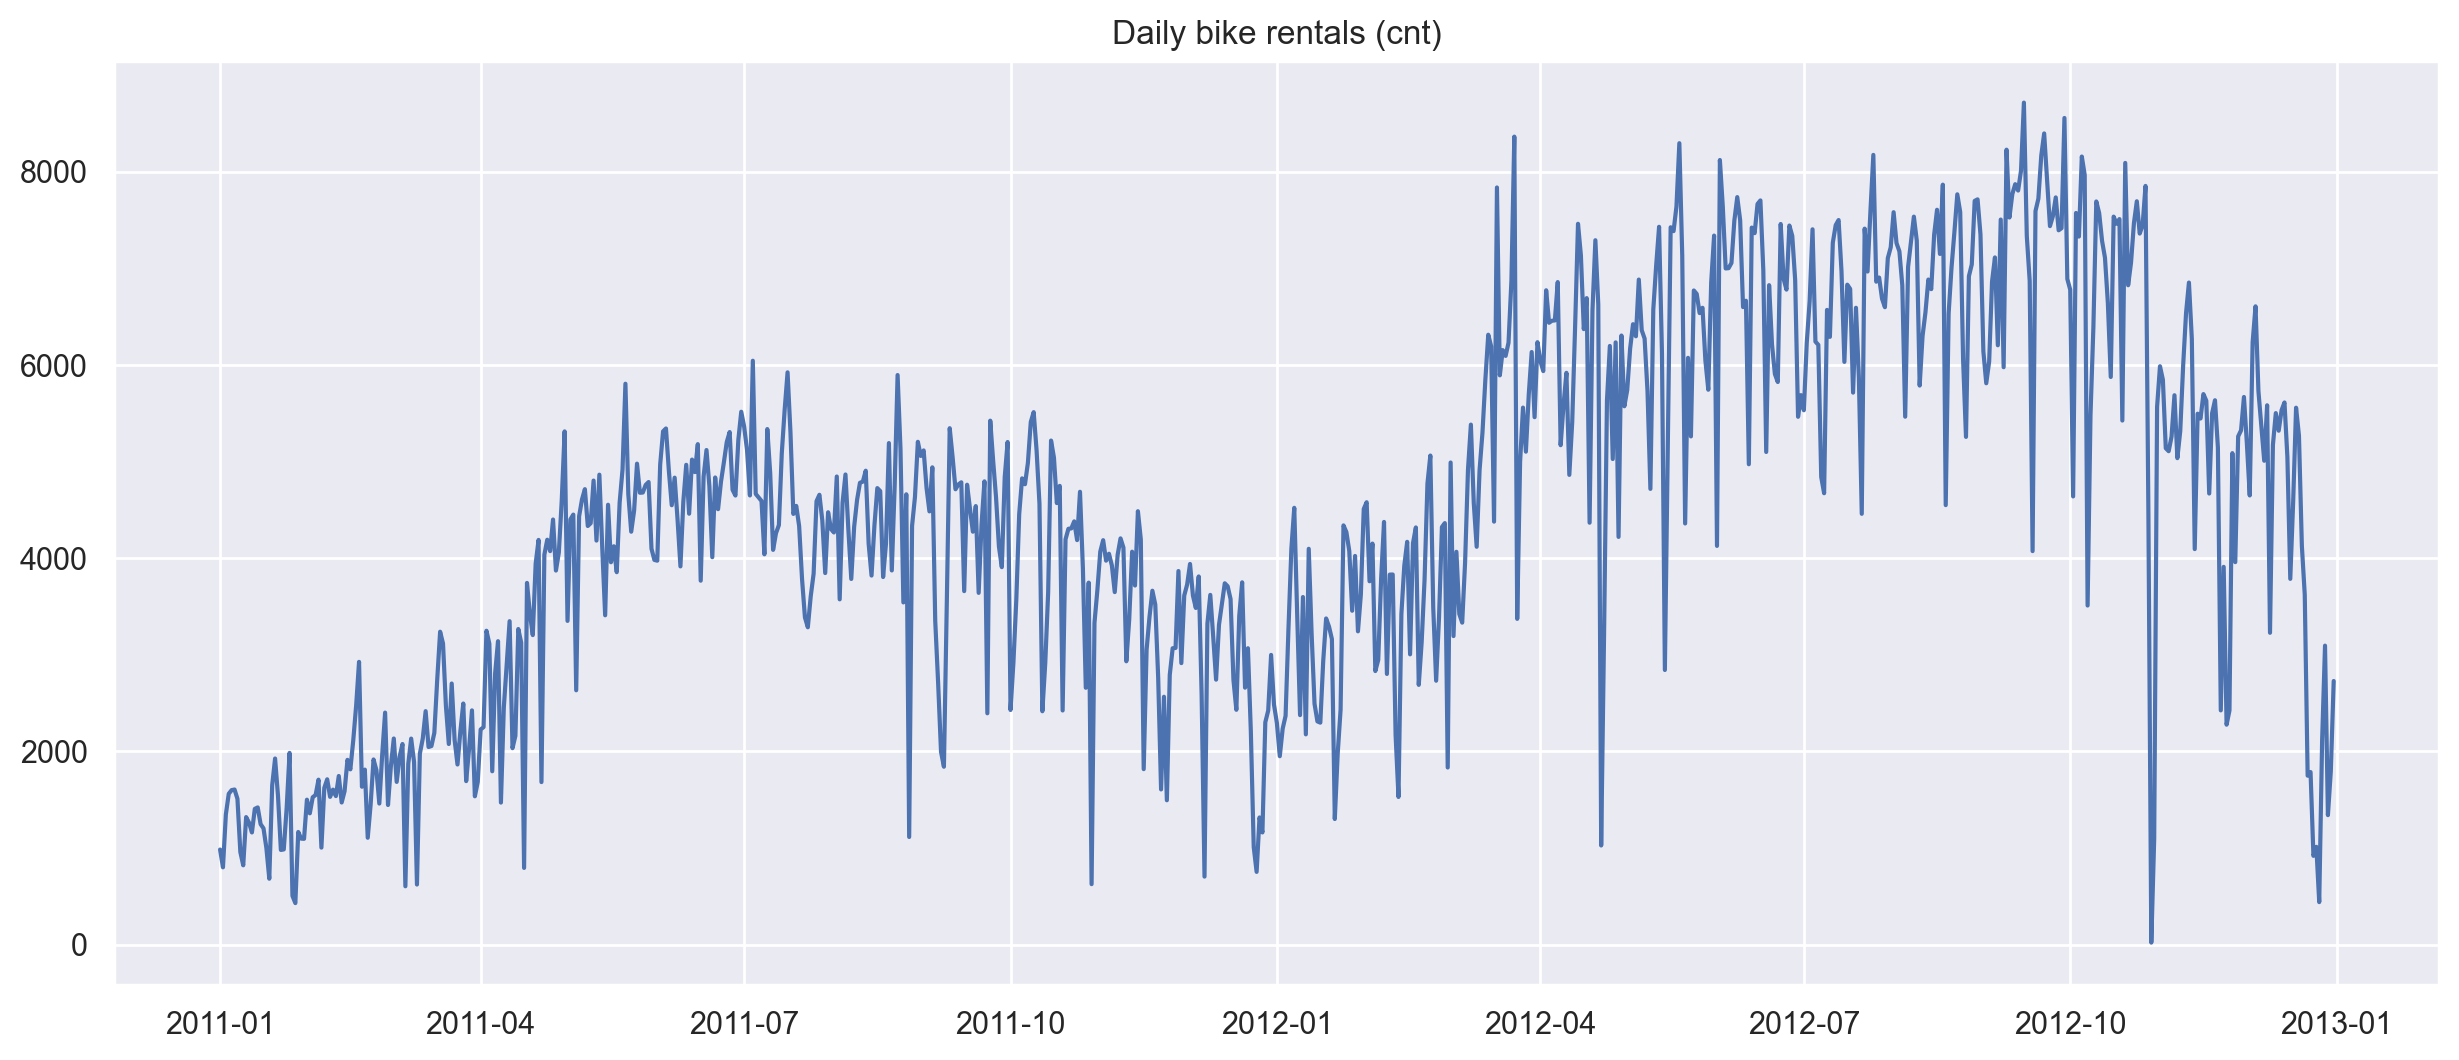

In [190]:
plt.figure(figsize=(15, 6))
plt.plot(ts["cnt"])
plt.title("Daily bike rentals (cnt)")
plt.grid(True)

Checking the forecast quality metrics

In [191]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


MAE – absolute error in “number of rentals”.

MSE – same but squared.

MAPE – relative error in % 

Move, smooth, evaluate as moving average and anomaly detection

In [192]:
def moving_average(series, n):
    return np.average(series[-n:])


Example: “average rentals for last 7 days”

In [193]:
moving_average(ts["cnt"], 7)

np.float64(1789.857142857143)

Rolling smoothing with confidence intervals and anomalies

In [194]:
def plotMovingAverage(
    series, window, plot_intervals=False, scale=1.96, plot_anomalies=False
):
    rolling_mean = series.rolling(window=window).mean()

    plt.figure(figsize=(15, 5))
    plt.title(f"Moving average  (window = {window})")
    plt.plot(rolling_mean, "g", label="Rolling mean trend")

    if plot_intervals:
        mae = mean_absolute_error(series[window:], rolling_mean[window:])
        deviation = np.std(series[window:] - rolling_mean[window:])
        lower_bond = rolling_mean - (mae + scale * deviation)
        upper_bond = rolling_mean + (mae + scale * deviation)
        plt.plot(upper_bond, "r--", label="Upper/Lower bound")
        plt.plot(lower_bond, "r--")

        if plot_anomalies:
            anomalies = pd.Series(index=series.index, dtype=float)
            anomalies[series < lower_bond] = series[series < lower_bond]
            anomalies[series > upper_bond] = series[series > upper_bond]
            plt.plot(anomalies, "ro", markersize=6, label="Anomalies")

    plt.plot(series[window:], label="Actual values")
    plt.legend(loc="upper left")
    plt.grid(True)


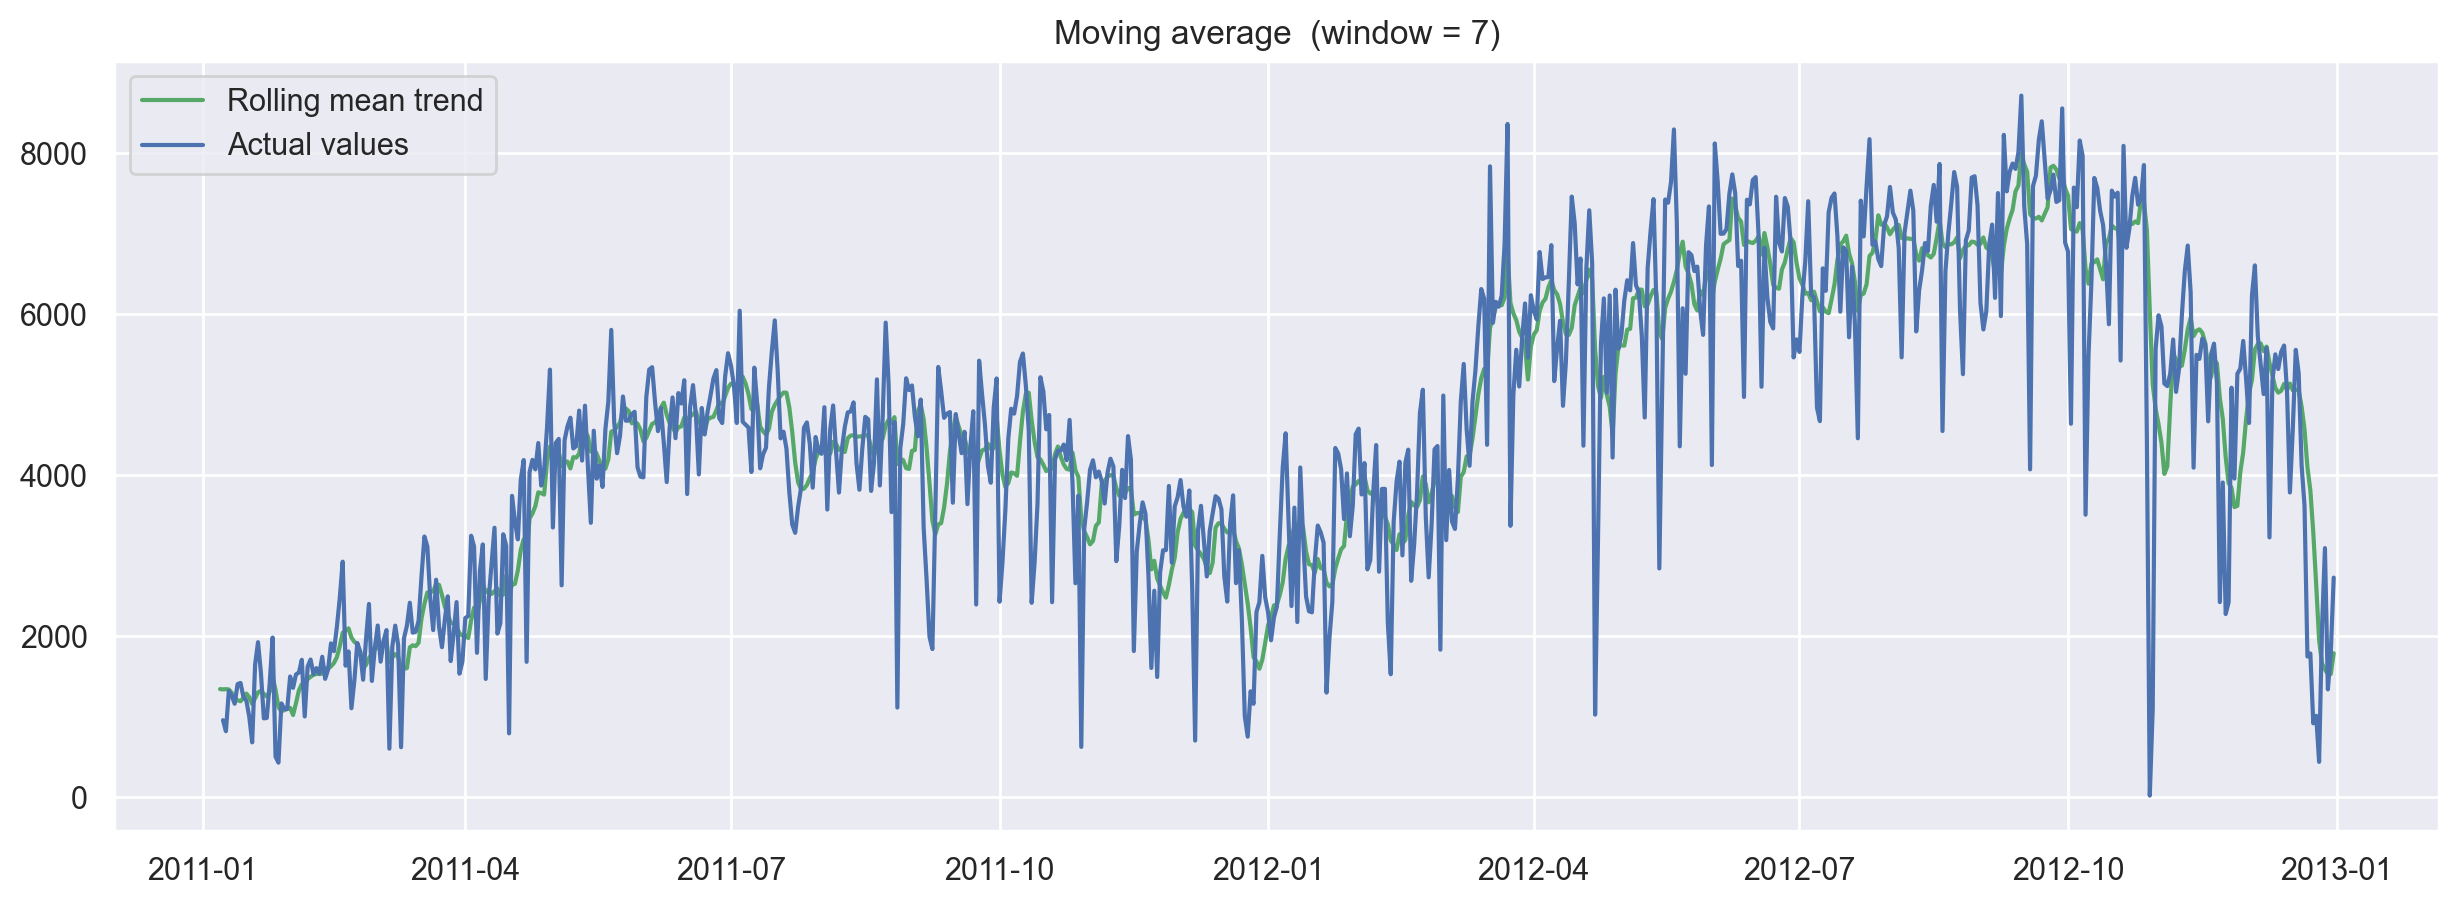

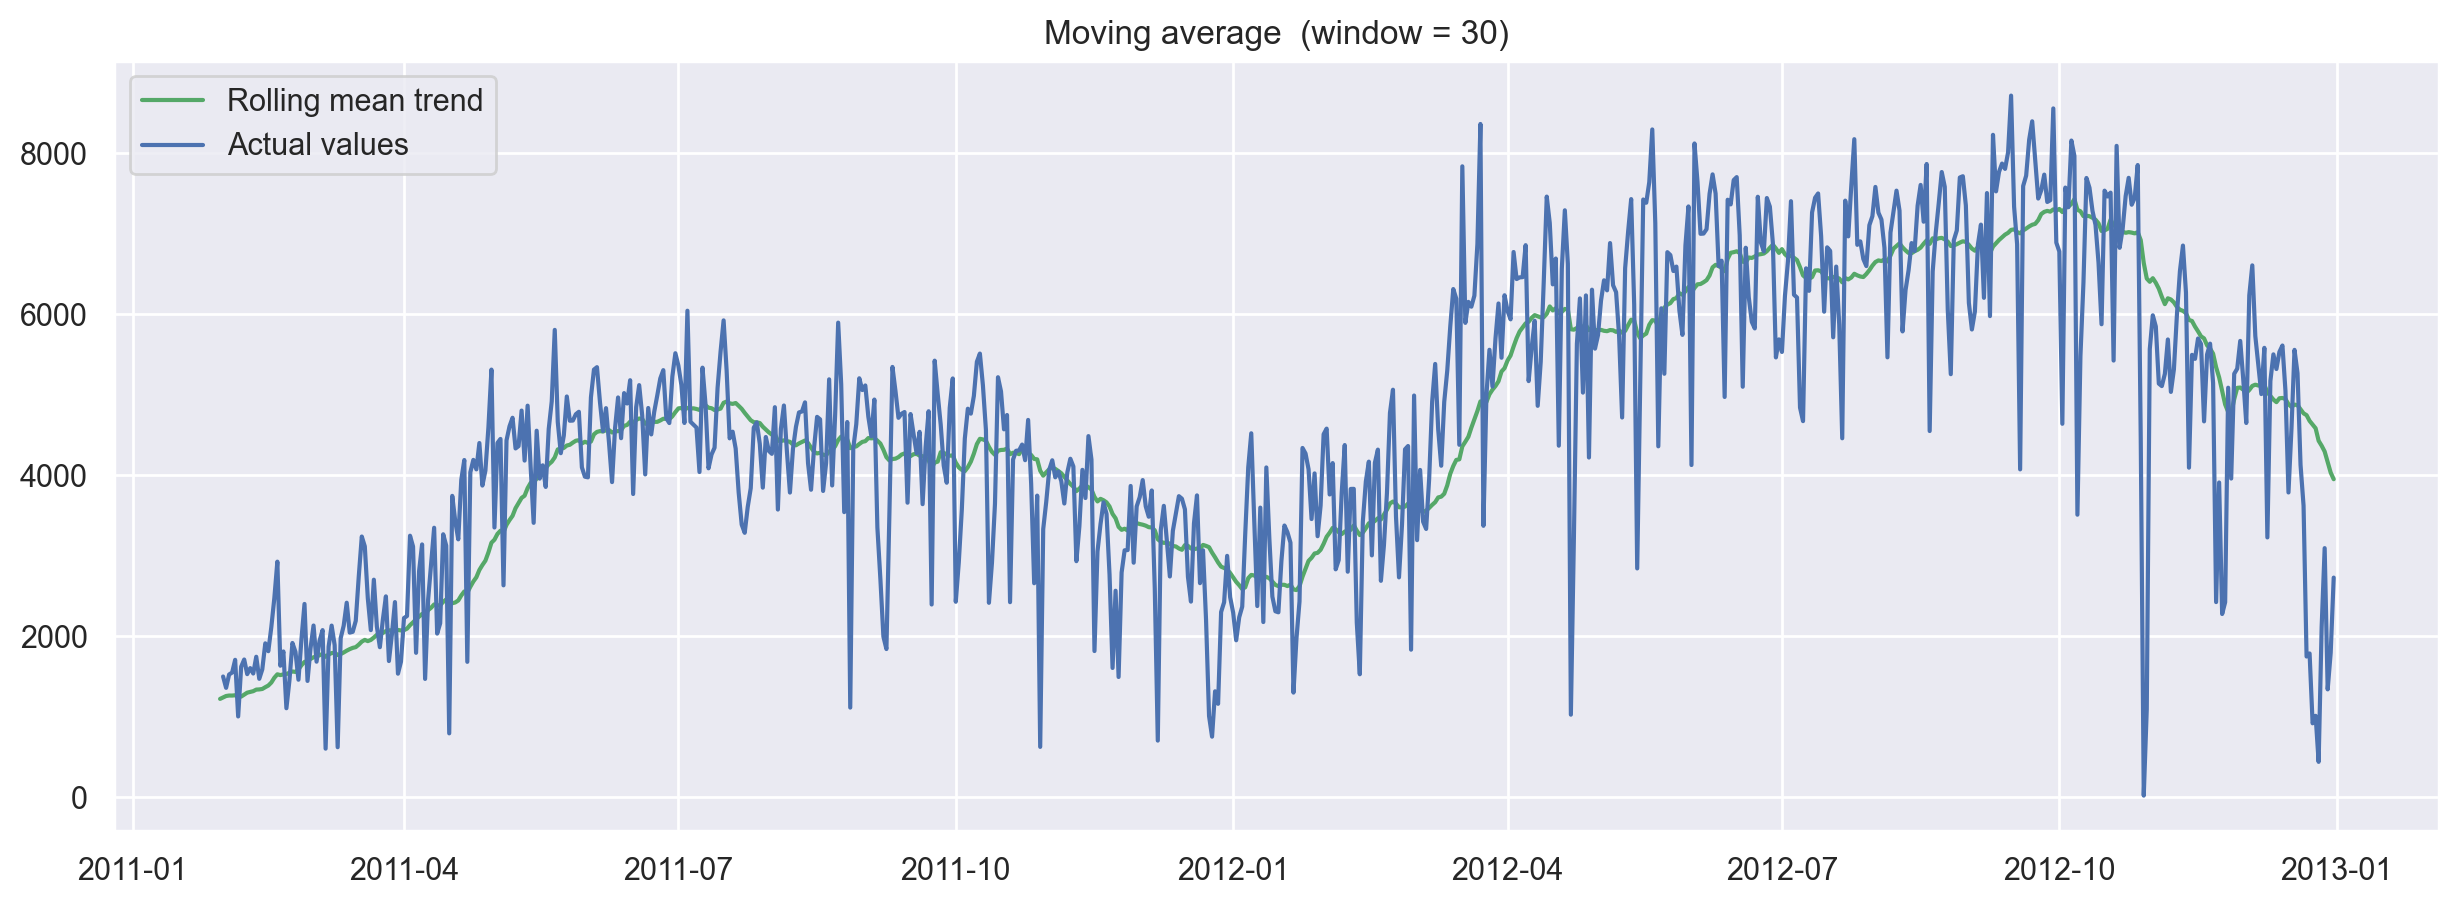

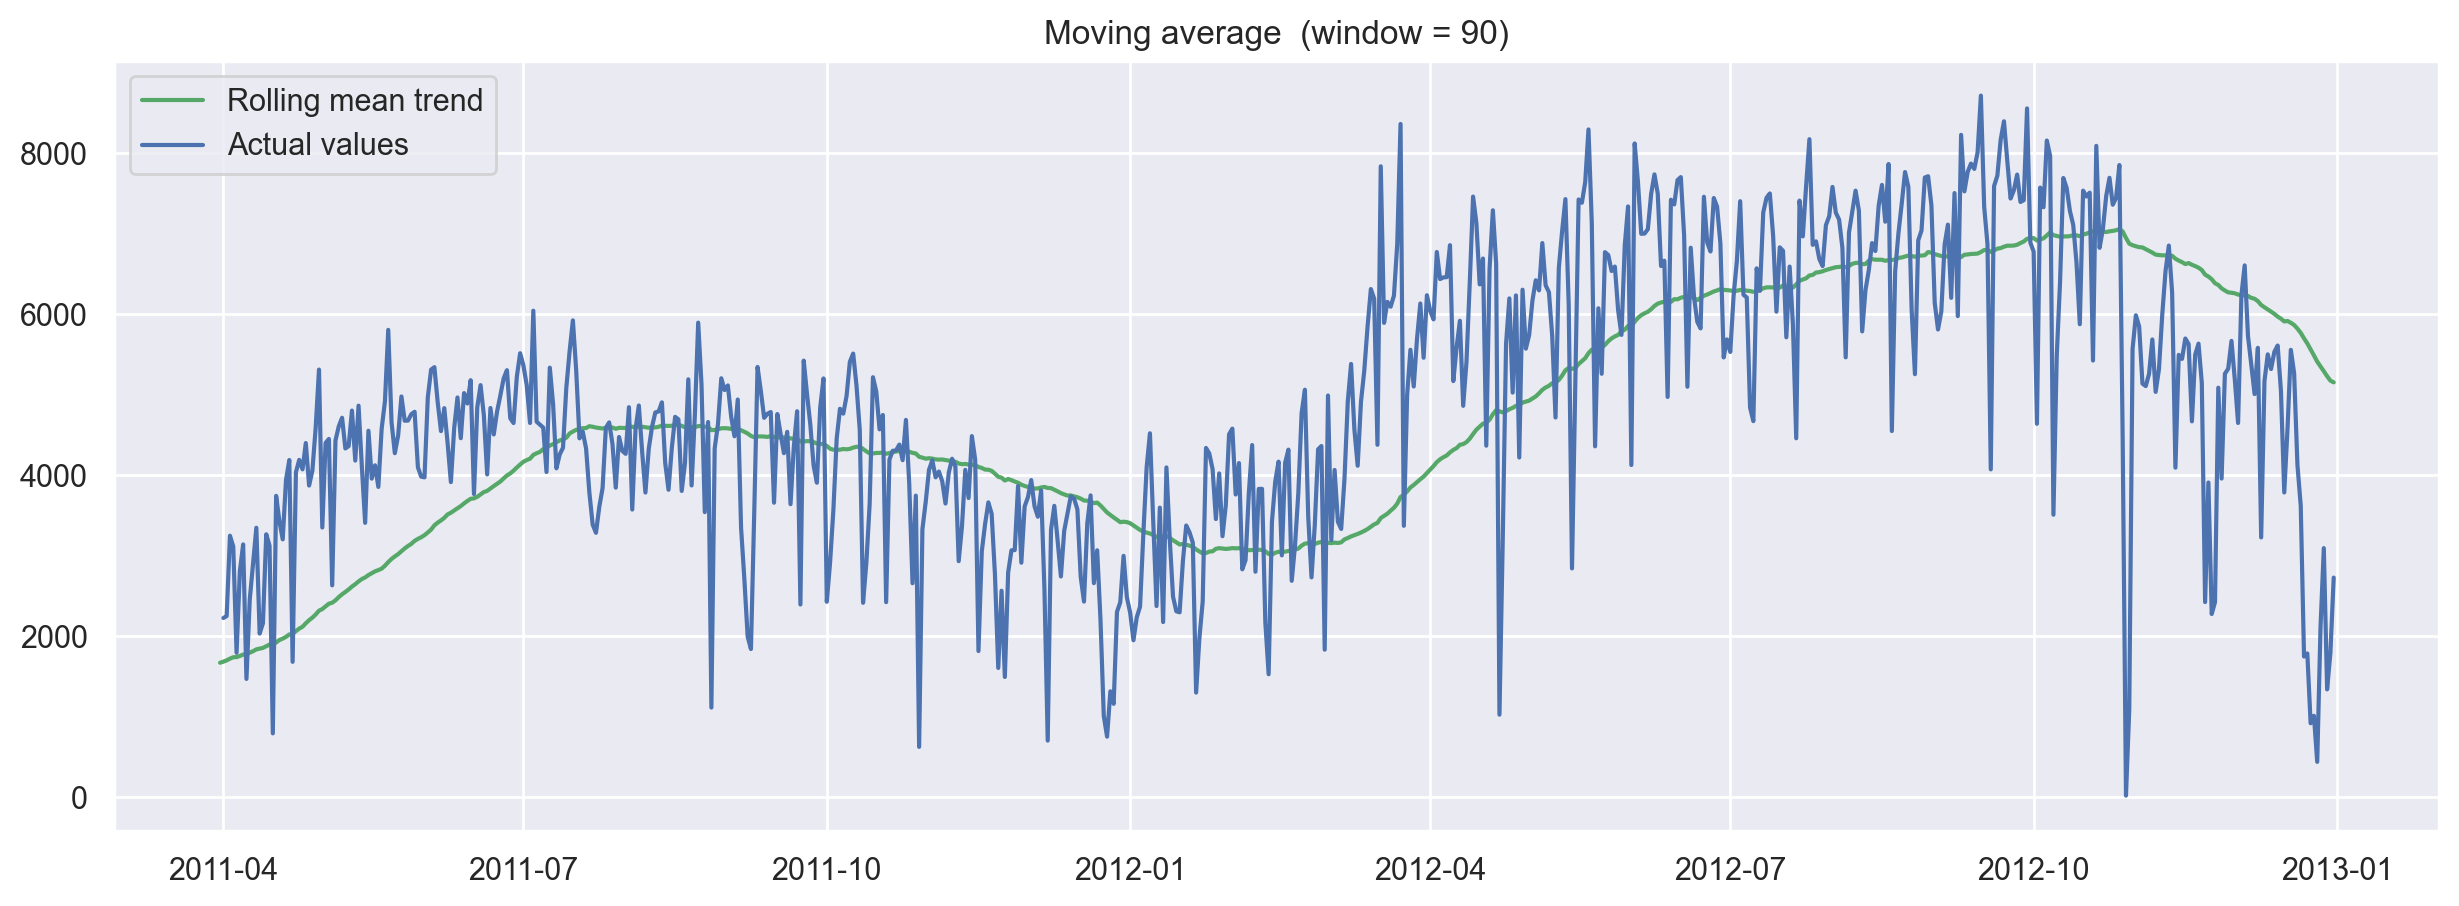

In [195]:
plotMovingAverage(ts["cnt"], 7)    # weekly smoothing
plotMovingAverage(ts["cnt"], 30)   # monthly-ish smoothing
plotMovingAverage(ts["cnt"], 90)   # seasonal/long-term

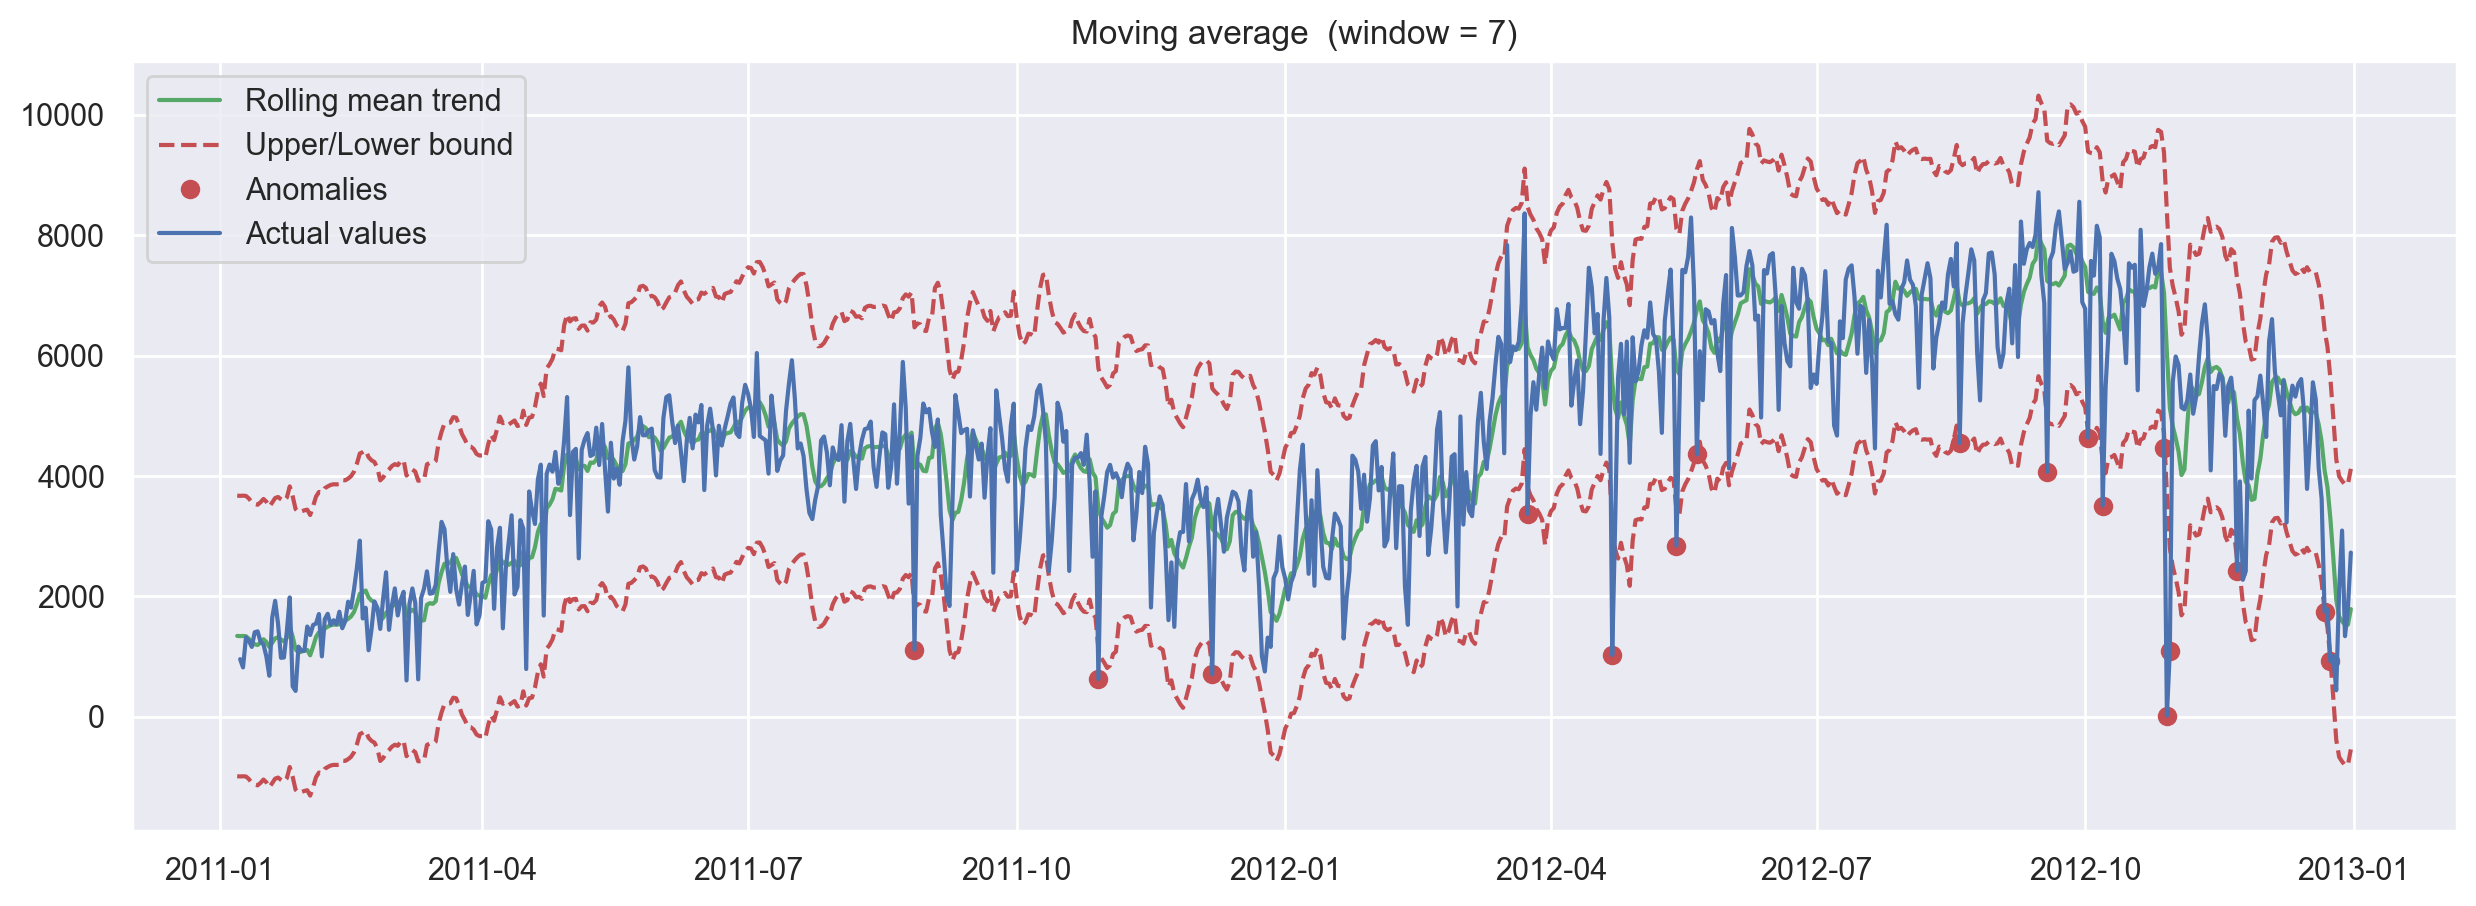

In [196]:
plotMovingAverage(ts["cnt"], 7, plot_intervals=True, plot_anomalies=True)

Weighted average

In [197]:
def weighted_average(series, weights):
    result = 0.0
    for n in range(len(weights)):
        result += series.iloc[-n - 1] * weights[n]
    return float(result)

In [198]:
weighted_average(ts["cnt"], [0.6, 0.3, 0.1])

2310.2999999999997

Exponential smoothing

Simple exponential smoothing (manual)

In [199]:
def exponential_smoothing(series, alpha):
    result = [series[0]]
    for n in range(1, len(series)):
        result.append(alpha * series[n] + (1 - alpha) * result[n - 1])
    return result

def plotExponentialSmoothing(series, alphas):
    with plt.style.context("bmh"):
        plt.figure(figsize=(15, 7))
        for alpha in alphas:
            plt.plot(
                exponential_smoothing(series.values, alpha),
                label=f"Alpha {alpha}"
            )
        plt.plot(series.values, "c", label="Actual")
        plt.legend(loc="best")
        plt.title("Exponential Smoothing (bike cnt)")
        plt.grid(True)

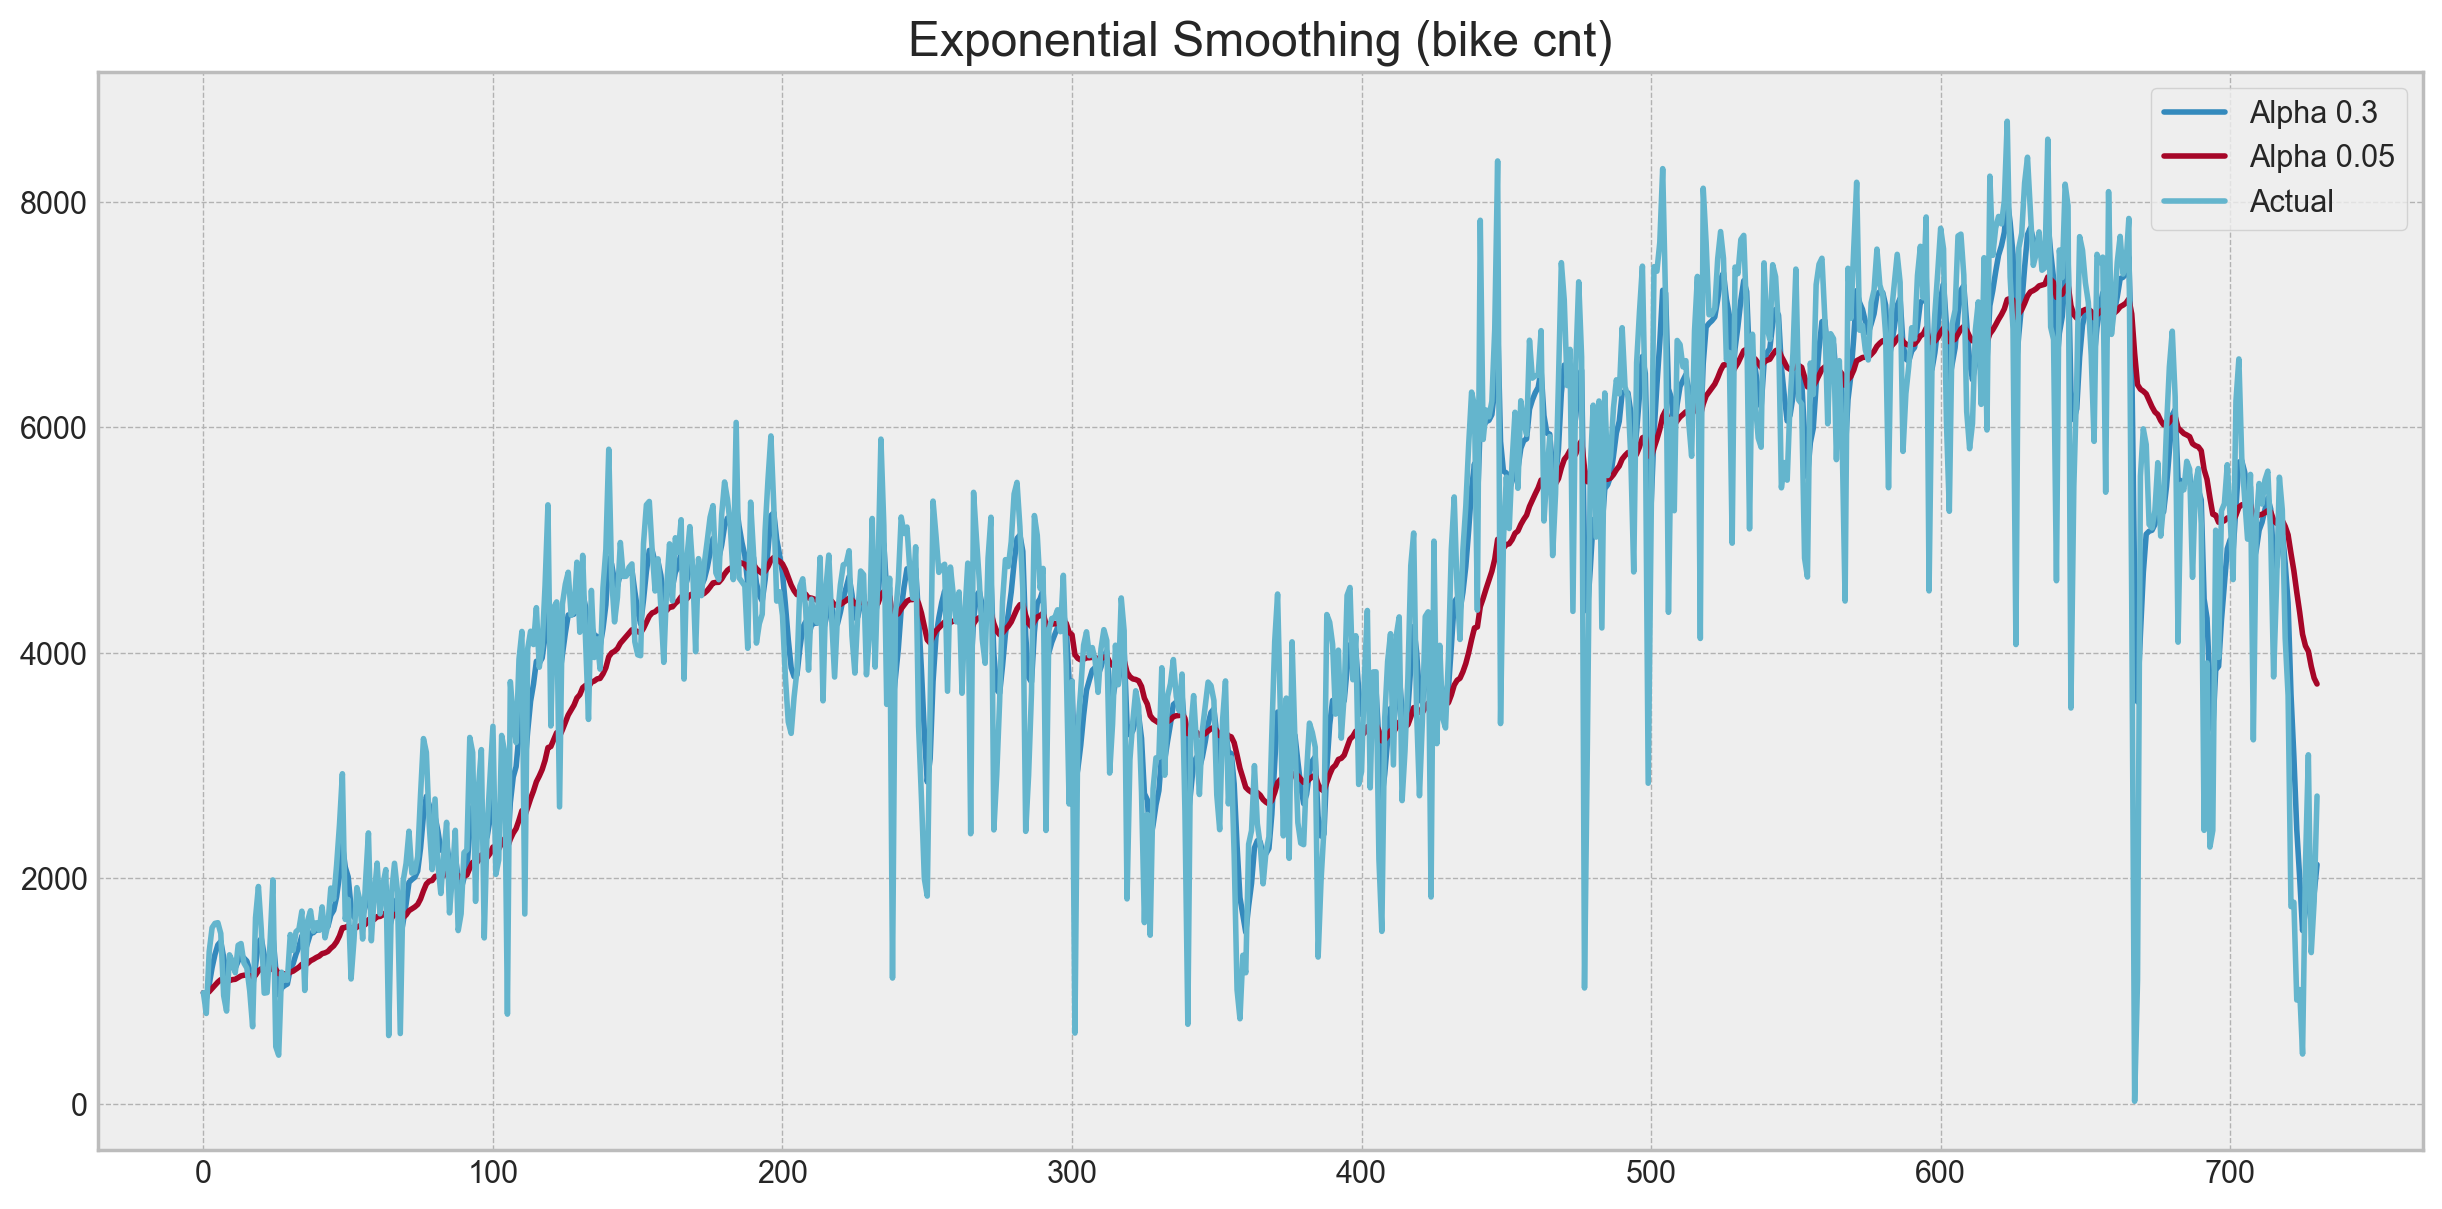

In [200]:
plotExponentialSmoothing(ts["cnt"], [0.3, 0.05])

Larger alpha then it reacts faster to changes, less smooth.

Smaller alpha then it is smoother, slower to react.

Double exponential smoothing (Holt)

In [ ]:
def double_exponential_smoothing(series, alpha, beta):
    result = [series[0]]
    for n in range(1, len(series) + 1):
        if n == 1:
            level, trend = series[0], series[1] - series[0]
        if n >= len(series): 
            value = result[-1]
        else:
            value = series[n]
        last_level, level = level, alpha * value + (1 - alpha) * (level + trend)
        trend = beta * (level - last_level) + (1 - beta) * trend
        result.append(level + trend)
    return result

def plotDoubleExponentialSmoothing(series, alphas, betas):
    with plt.style.context("bmh"):
        plt.figure(figsize=(20, 8))
        for alpha in alphas:
            for beta in betas:
                plt.plot(
                    double_exponential_smoothing(series.values, alpha, beta),
                    label=f"Alpha {alpha}, beta {beta}"
                )
        plt.plot(series.values, label="Actual")
        plt.legend(loc="best")
        plt.title("Double Exponential Smoothing (bike cnt)")
        plt.grid(True)


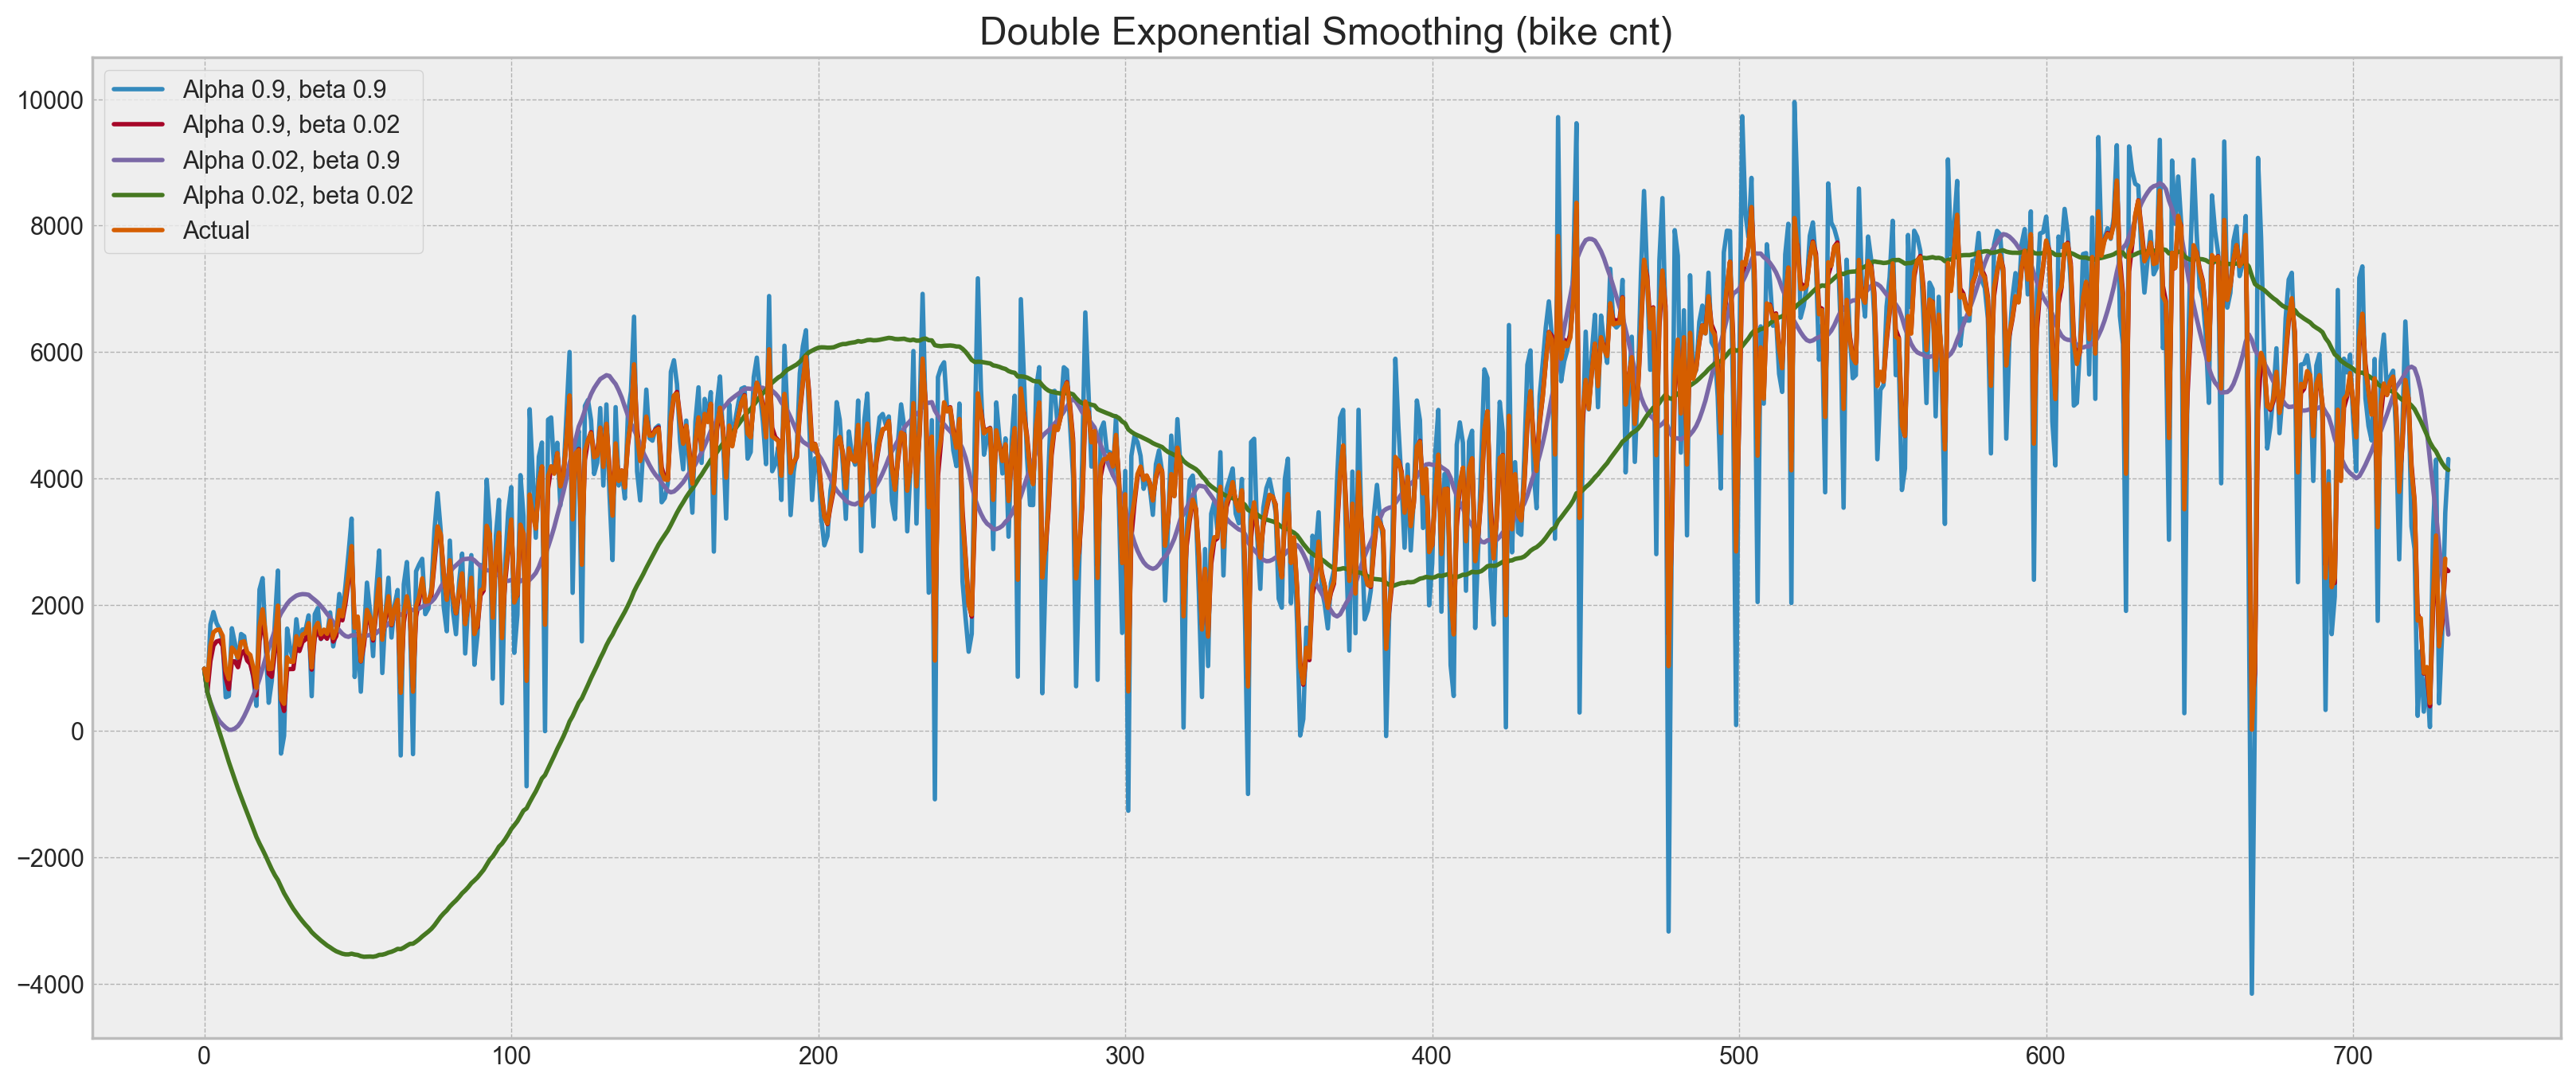

In [202]:
plotDoubleExponentialSmoothing(ts["cnt"], alphas=[0.9, 0.02], betas=[0.9, 0.02])

Triple exponential smoothing (Holt-Winters + Brutlag)

In [203]:
class HoltWinters:
    def __init__(self, series, slen, alpha, beta, gamma, n_preds, scaling_factor=1.96):
        self.series = series
        self.slen = slen
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.n_preds = n_preds
        self.scaling_factor = scaling_factor

    def initial_trend(self):
        s = 0.0
        for i in range(self.slen):
            s += (self.series[i + self.slen] - self.series[i]) / self.slen
        return s / self.slen

    def initial_seasonal_components(self):
        seasonals = {}
        season_averages = []
        n_seasons = int(len(self.series) / self.slen)
        for j in range(n_seasons):
            season_averages.append(
                np.mean(self.series[self.slen * j : self.slen * (j + 1)])
            )
        for i in range(self.slen):
            s = 0.0
            for j in range(n_seasons):
                s += self.series[self.slen * j + i] - season_averages[j]
            seasonals[i] = s / n_seasons
        return seasonals

    def triple_exponential_smoothing(self):
        self.result = []
        self.Smooth = []
        self.Season = []
        self.Trend = []
        self.PredictedDeviation = []
        self.UpperBond = []
        self.LowerBond = []

        seasonals = self.initial_seasonal_components()

        for i in range(len(self.series) + self.n_preds):
            if i == 0:
                smooth = self.series[0]
                trend = self.initial_trend()
                self.result.append(self.series[0])
                self.Smooth.append(smooth)
                self.Trend.append(trend)
                self.Season.append(seasonals[i % self.slen])

                self.PredictedDeviation.append(0)
                self.UpperBond.append(self.result[0])
                self.LowerBond.append(self.result[0])
                continue

            if i >= len(self.series):
                m = i - len(self.series) + 1
                self.result.append((smooth + m * trend) + seasonals[i % self.slen])
                self.PredictedDeviation.append(self.PredictedDeviation[-1] * 1.01)
            else:
                val = self.series[i]
                last_smooth, smooth = (
                    smooth,
                    self.alpha * (val - seasonals[i % self.slen])
                    + (1 - self.alpha) * (smooth + trend),
                )
                trend = self.beta * (smooth - last_smooth) + (1 - self.beta) * trend
                seasonals[i % self.slen] = (
                    self.gamma * (val - smooth)
                    + (1 - self.gamma) * seasonals[i % self.slen]
                )
                self.result.append(smooth + trend + seasonals[i % self.slen])

                self.PredictedDeviation.append(
                    self.gamma * np.abs(self.series[i] - self.result[i])
                    + (1 - self.gamma) * self.PredictedDeviation[-1]
                )

            self.UpperBond.append(
                self.result[-1] + self.scaling_factor * self.PredictedDeviation[-1]
            )
            self.LowerBond.append(
                self.result[-1] - self.scaling_factor * self.PredictedDeviation[-1]
            )

            self.Smooth.append(smooth)
            self.Trend.append(trend)
            self.Season.append(seasonals[i % self.slen])


Time series cross-validation for Holt–Winters

In [204]:
from sklearn.model_selection import TimeSeriesSplit

def timeseriesCVscore(params, series, loss_function=mean_squared_error, slen=7):
    errors = []
    values = series.values
    alpha, beta, gamma = params

    tscv = TimeSeriesSplit(n_splits=3)

    for train_idx, test_idx in tscv.split(values):
        model = HoltWinters(
            series=values[train_idx],
            slen=slen,
            alpha=alpha,
            beta=beta,
            gamma=gamma,
            n_preds=len(test_idx),
        )
        model.triple_exponential_smoothing()
        preds = model.result[-len(test_idx):]
        actual = values[test_idx]
        error = loss_function(actual, preds)
        errors.append(error)

    return np.mean(errors)


In [205]:
data_hw = df["cnt"][:-30]   
slen = 7
x0 = [0.1, 0.1, 0.1]


opt = minimize(
    timeseriesCVscore,
    x0=x0,
    args=(data_hw, mean_squared_error, slen),
    method="TNC",
    bounds=((0, 1), (0, 1), (0, 1)),
)

alpha_final, beta_final, gamma_final = opt.x

In [206]:
model_hw = HoltWinters(
    data_hw.values,
    slen=slen,
    alpha=alpha_final,
    beta=beta_final,
    gamma=gamma_final,
    n_preds=30,      
    scaling_factor=3
)
model_hw.triple_exponential_smoothing()

In [207]:
def plotHoltWinters(series, model, plot_intervals=False, plot_anomalies=False):
    plt.figure(figsize=(20, 10))
    plt.plot(model.result, label="Model")
    plt.plot(series.values, label="Actual")

    error = mean_absolute_percentage_error(
        series.values, model.result[: len(series)]
    )
    plt.title(f"Mean Absolute Percentage Error: {error:.2f}%")

    if plot_intervals:
        plt.plot(model.UpperBond, "r--", alpha=0.5, label="Up/Low confidence")
        plt.plot(model.LowerBond, "r--", alpha=0.5)
        plt.fill_between(
            x=range(0, len(model.result)),
            y1=model.UpperBond,
            y2=model.LowerBond,
            alpha=0.2,
            color="grey",
        )

    if plot_anomalies:
        anomalies = np.array([np.nan] * len(series))
        lower = np.array(model.LowerBond[: len(series)])
        upper = np.array(model.UpperBond[: len(series)])
        vals = series.values
        anomalies[vals < lower] = vals[vals < lower]
        anomalies[vals > upper] = vals[vals > upper]
        plt.plot(anomalies, "o", markersize=10, label="Anomalies")

    plt.vlines(
        len(series),
        ymin=min(model.LowerBond),
        ymax=max(model.UpperBond),
        linestyles="dashed",
    )
    plt.grid(True)
    plt.legend(loc="best")

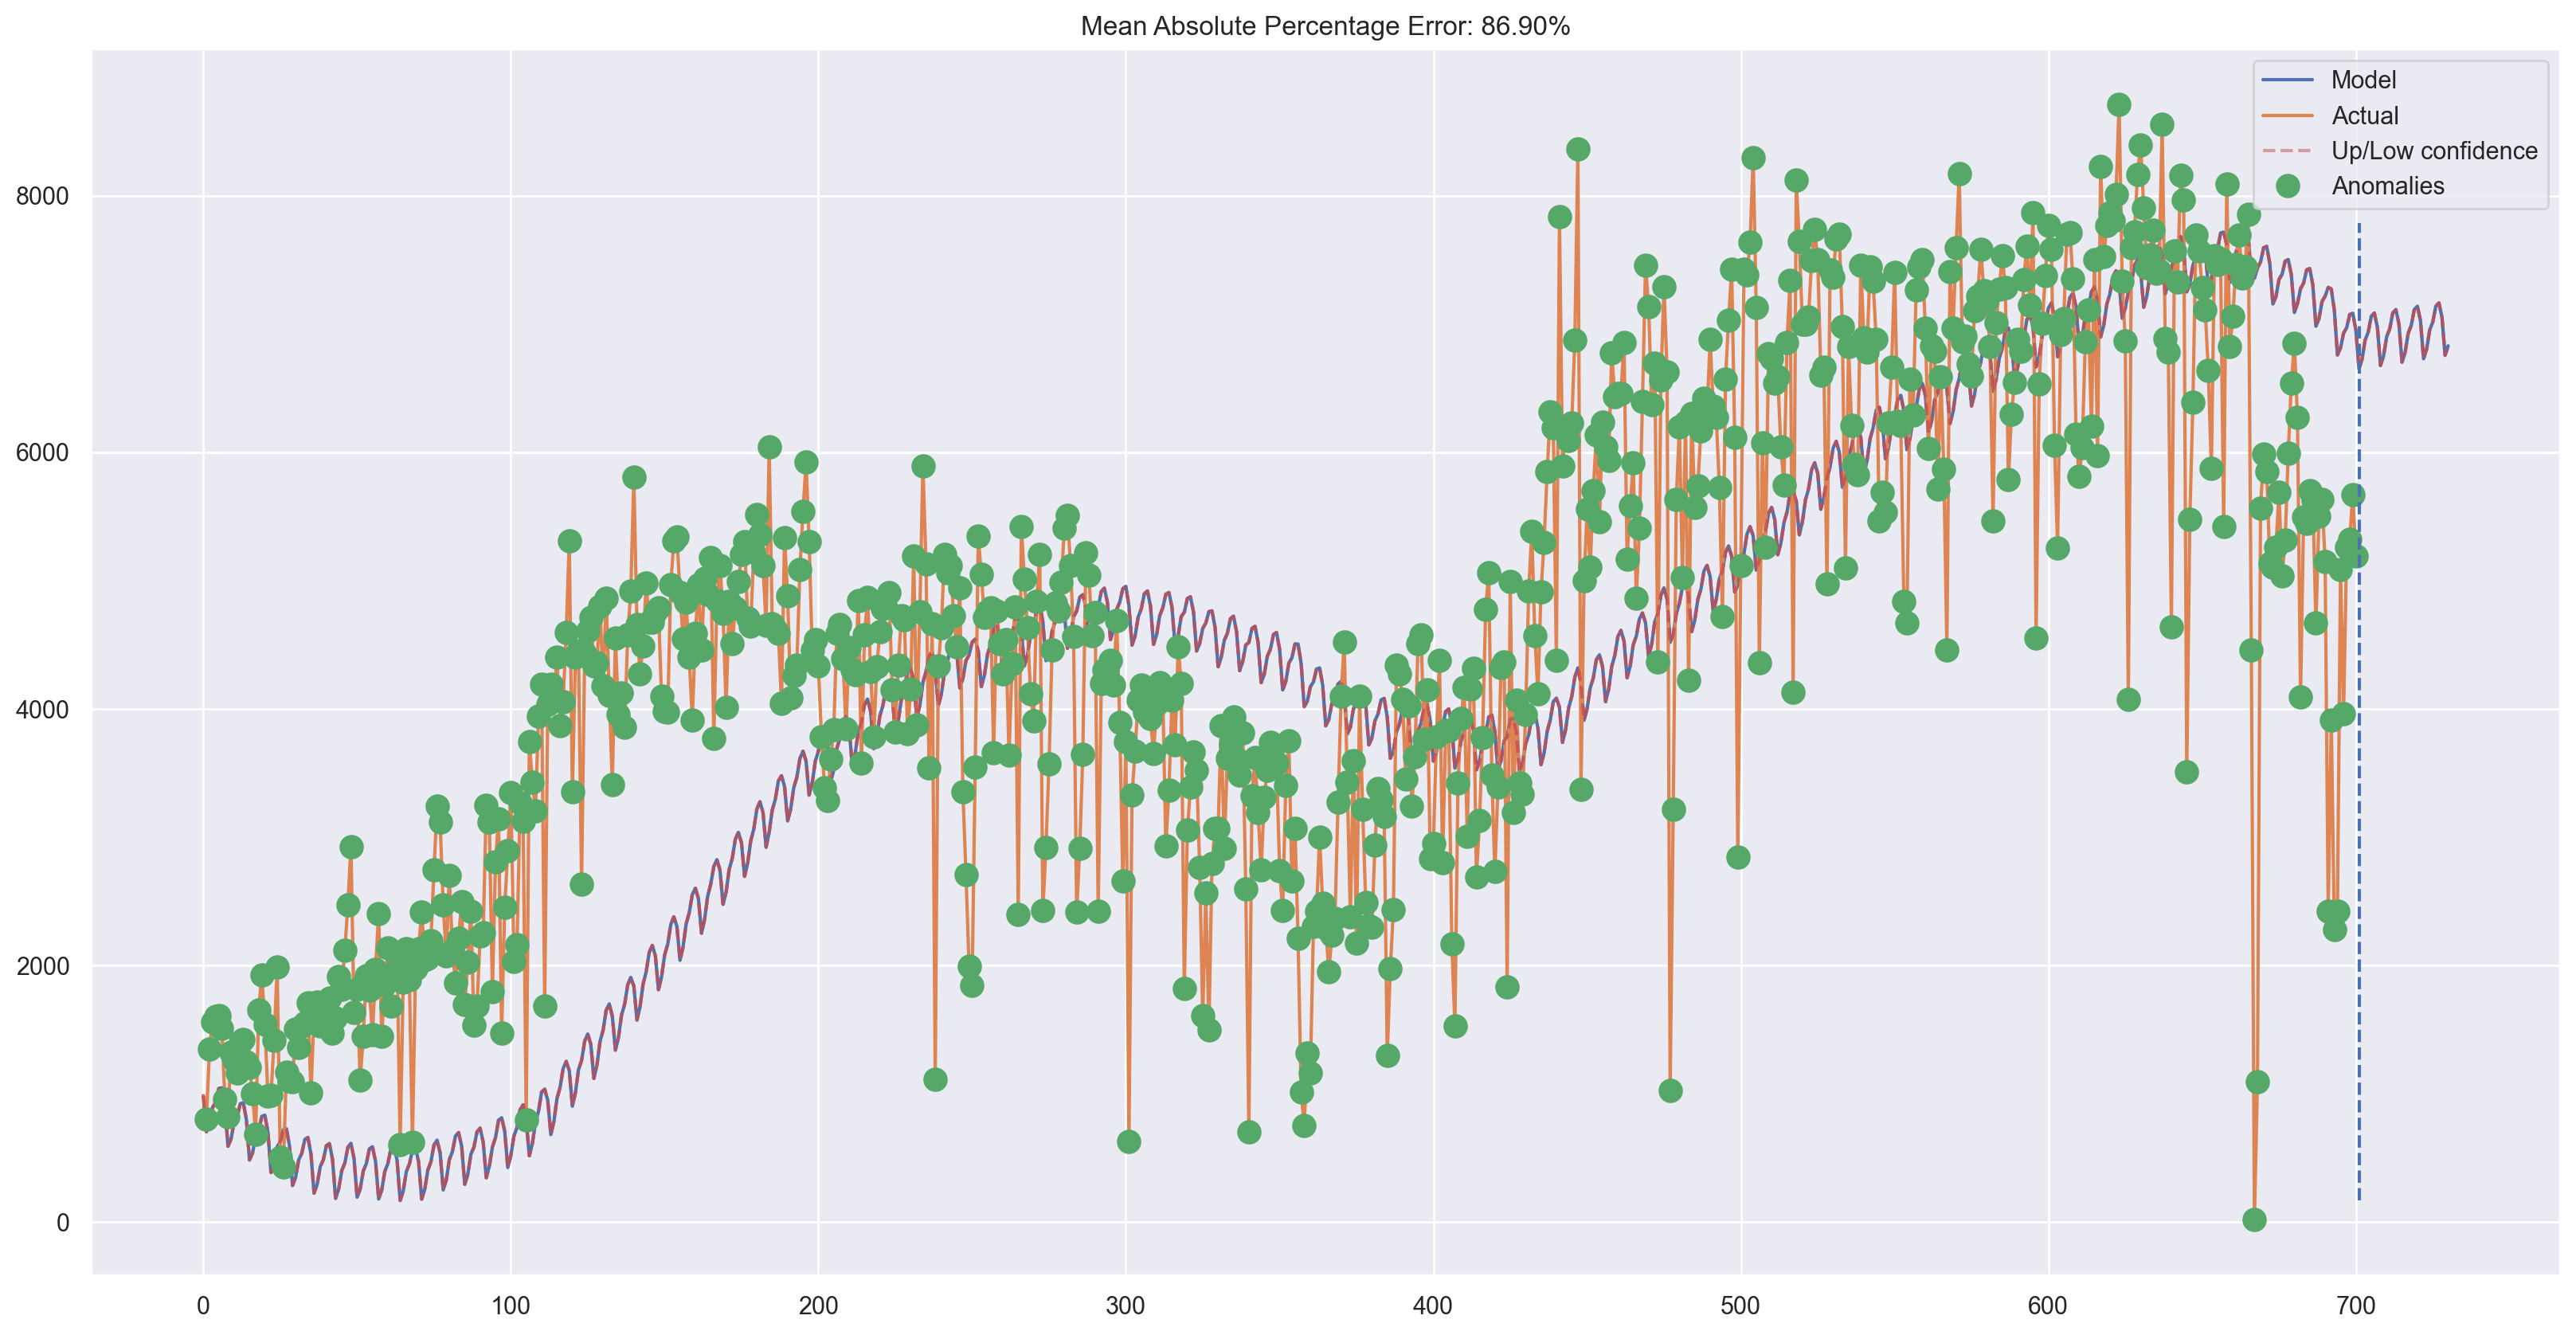

In [208]:
plotHoltWinters(data_hw, model_hw, plot_intervals=True, plot_anomalies=True)

Brutlag deviation

Text(0.5, 1.0, "Brutlag's predicted deviation (bike cnt)")

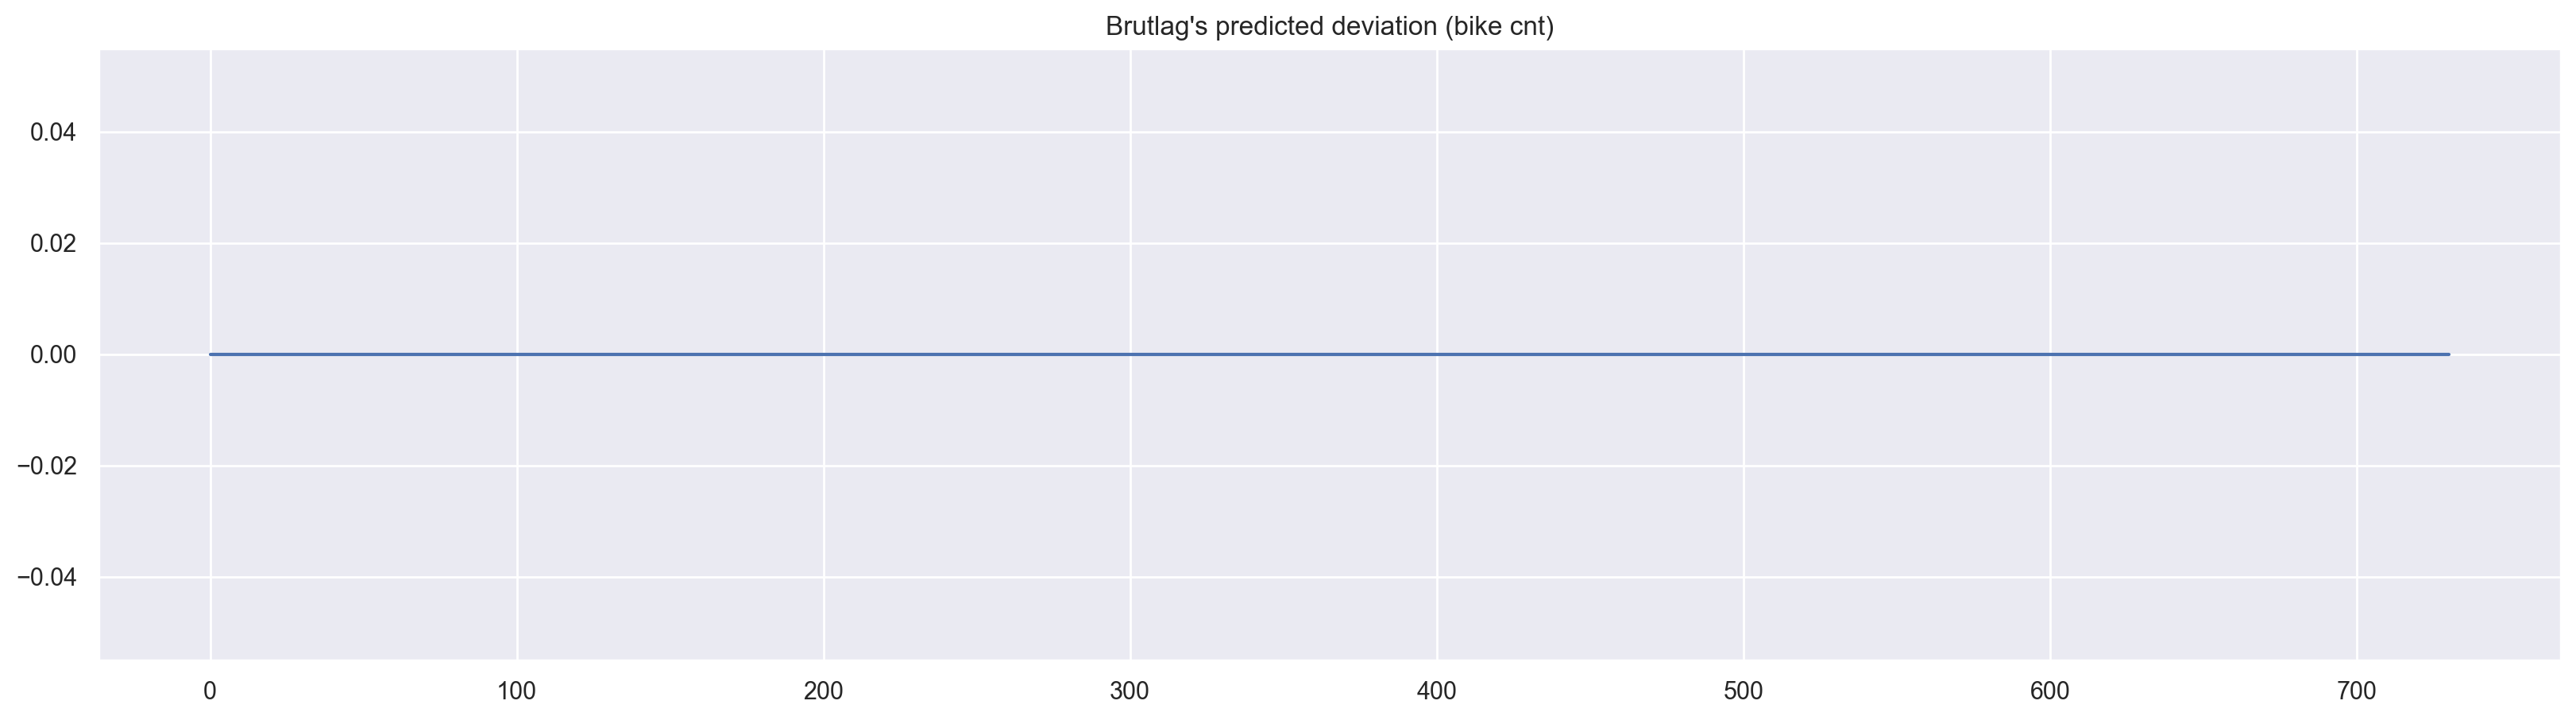

In [209]:
plt.figure(figsize=(20, 5))
plt.plot(model_hw.PredictedDeviation)
plt.grid(True)
plt.title("Brutlag's predicted deviation (bike cnt)")

Stationarity and SARIMA

In [210]:
def tsplot(y, lags=None, figsize=(12, 7), style="bmh"):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    with plt.style.context(style):
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))

        ts_ax.plot(y)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title(
            f"Time Series (Dickey-Fuller p={p_value:.5f})"
        )
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()

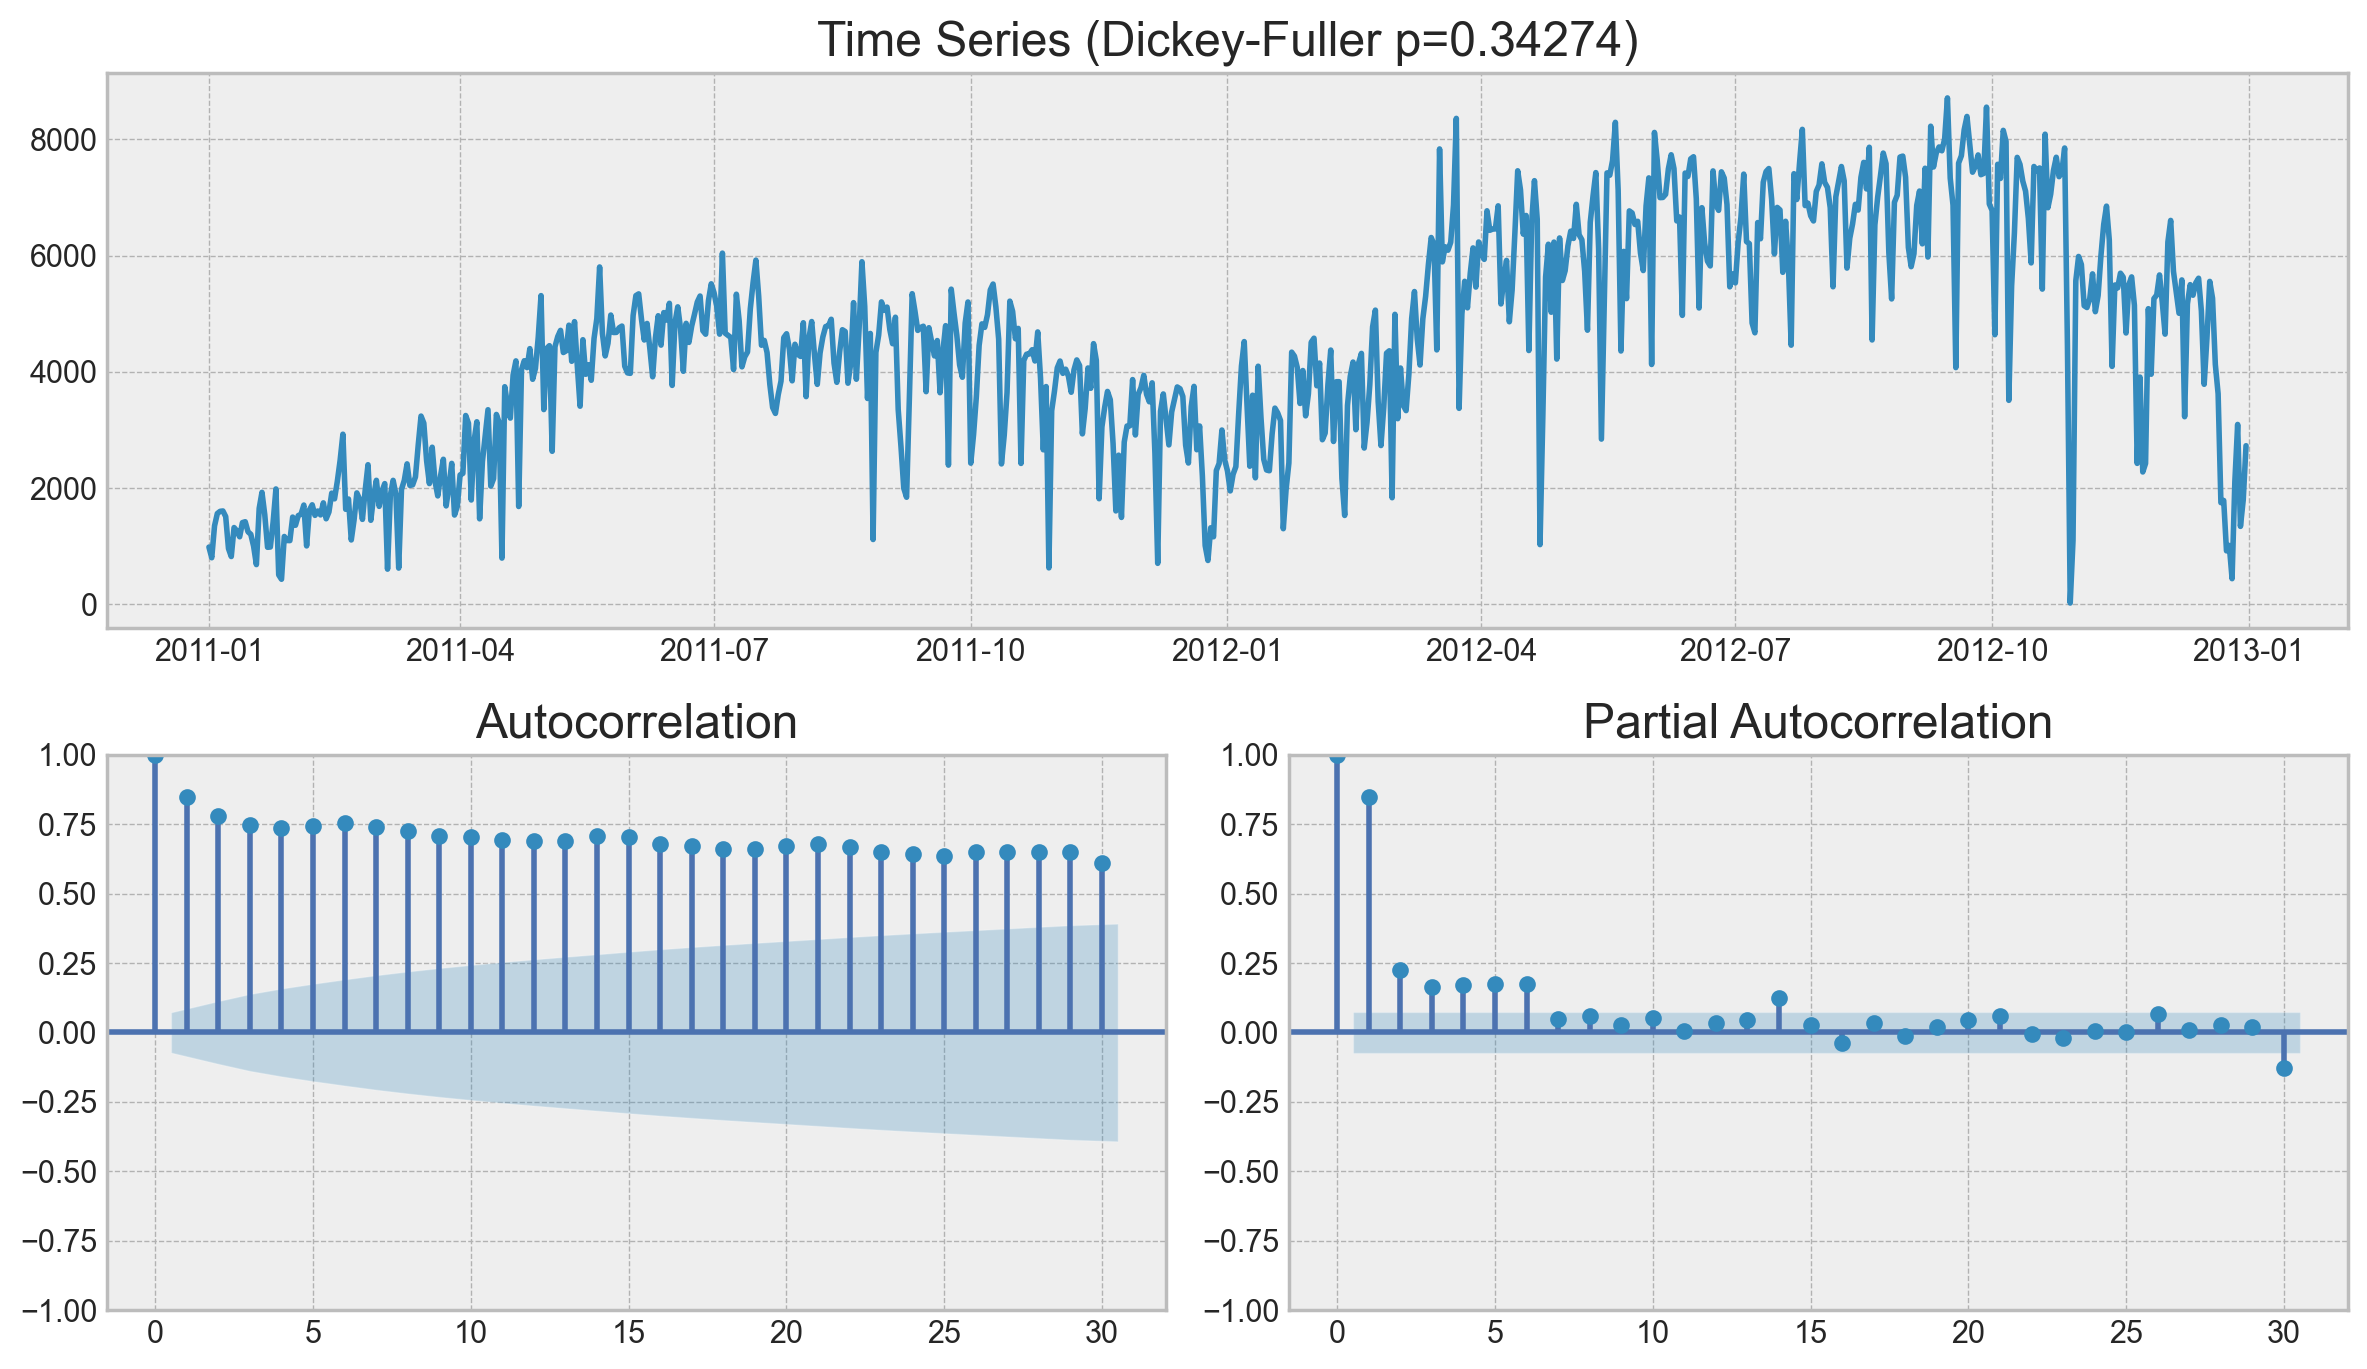

In [211]:
tsplot(ts["cnt"], lags=30)

Seasonal differencing (weekly) and first difference

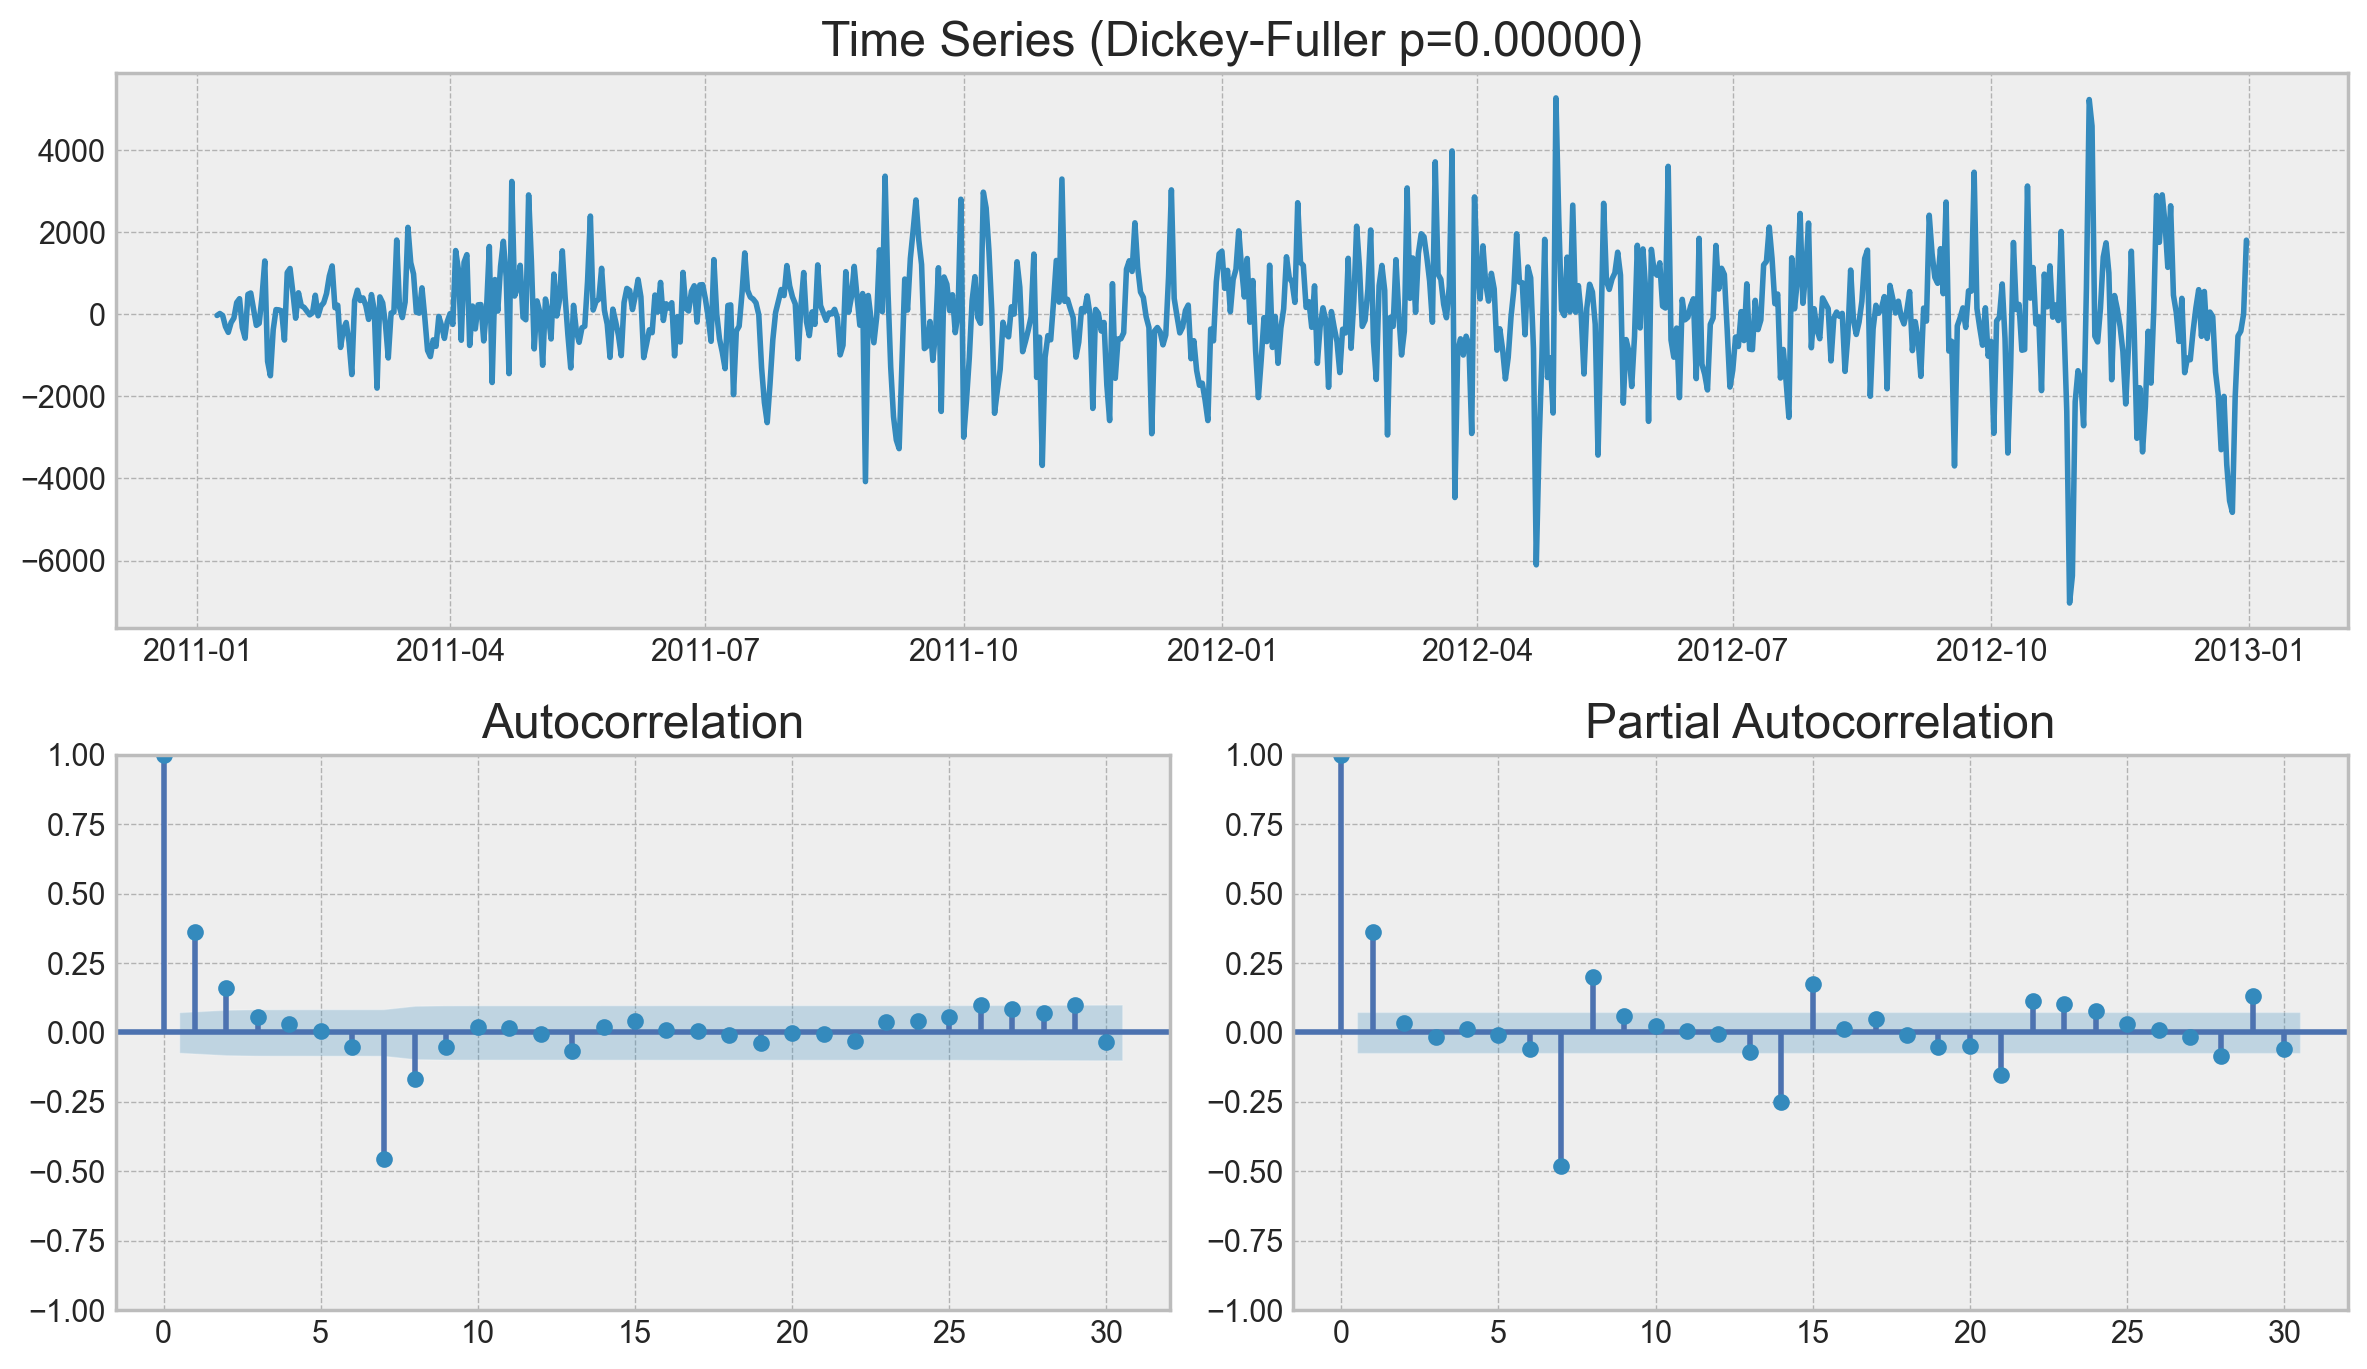

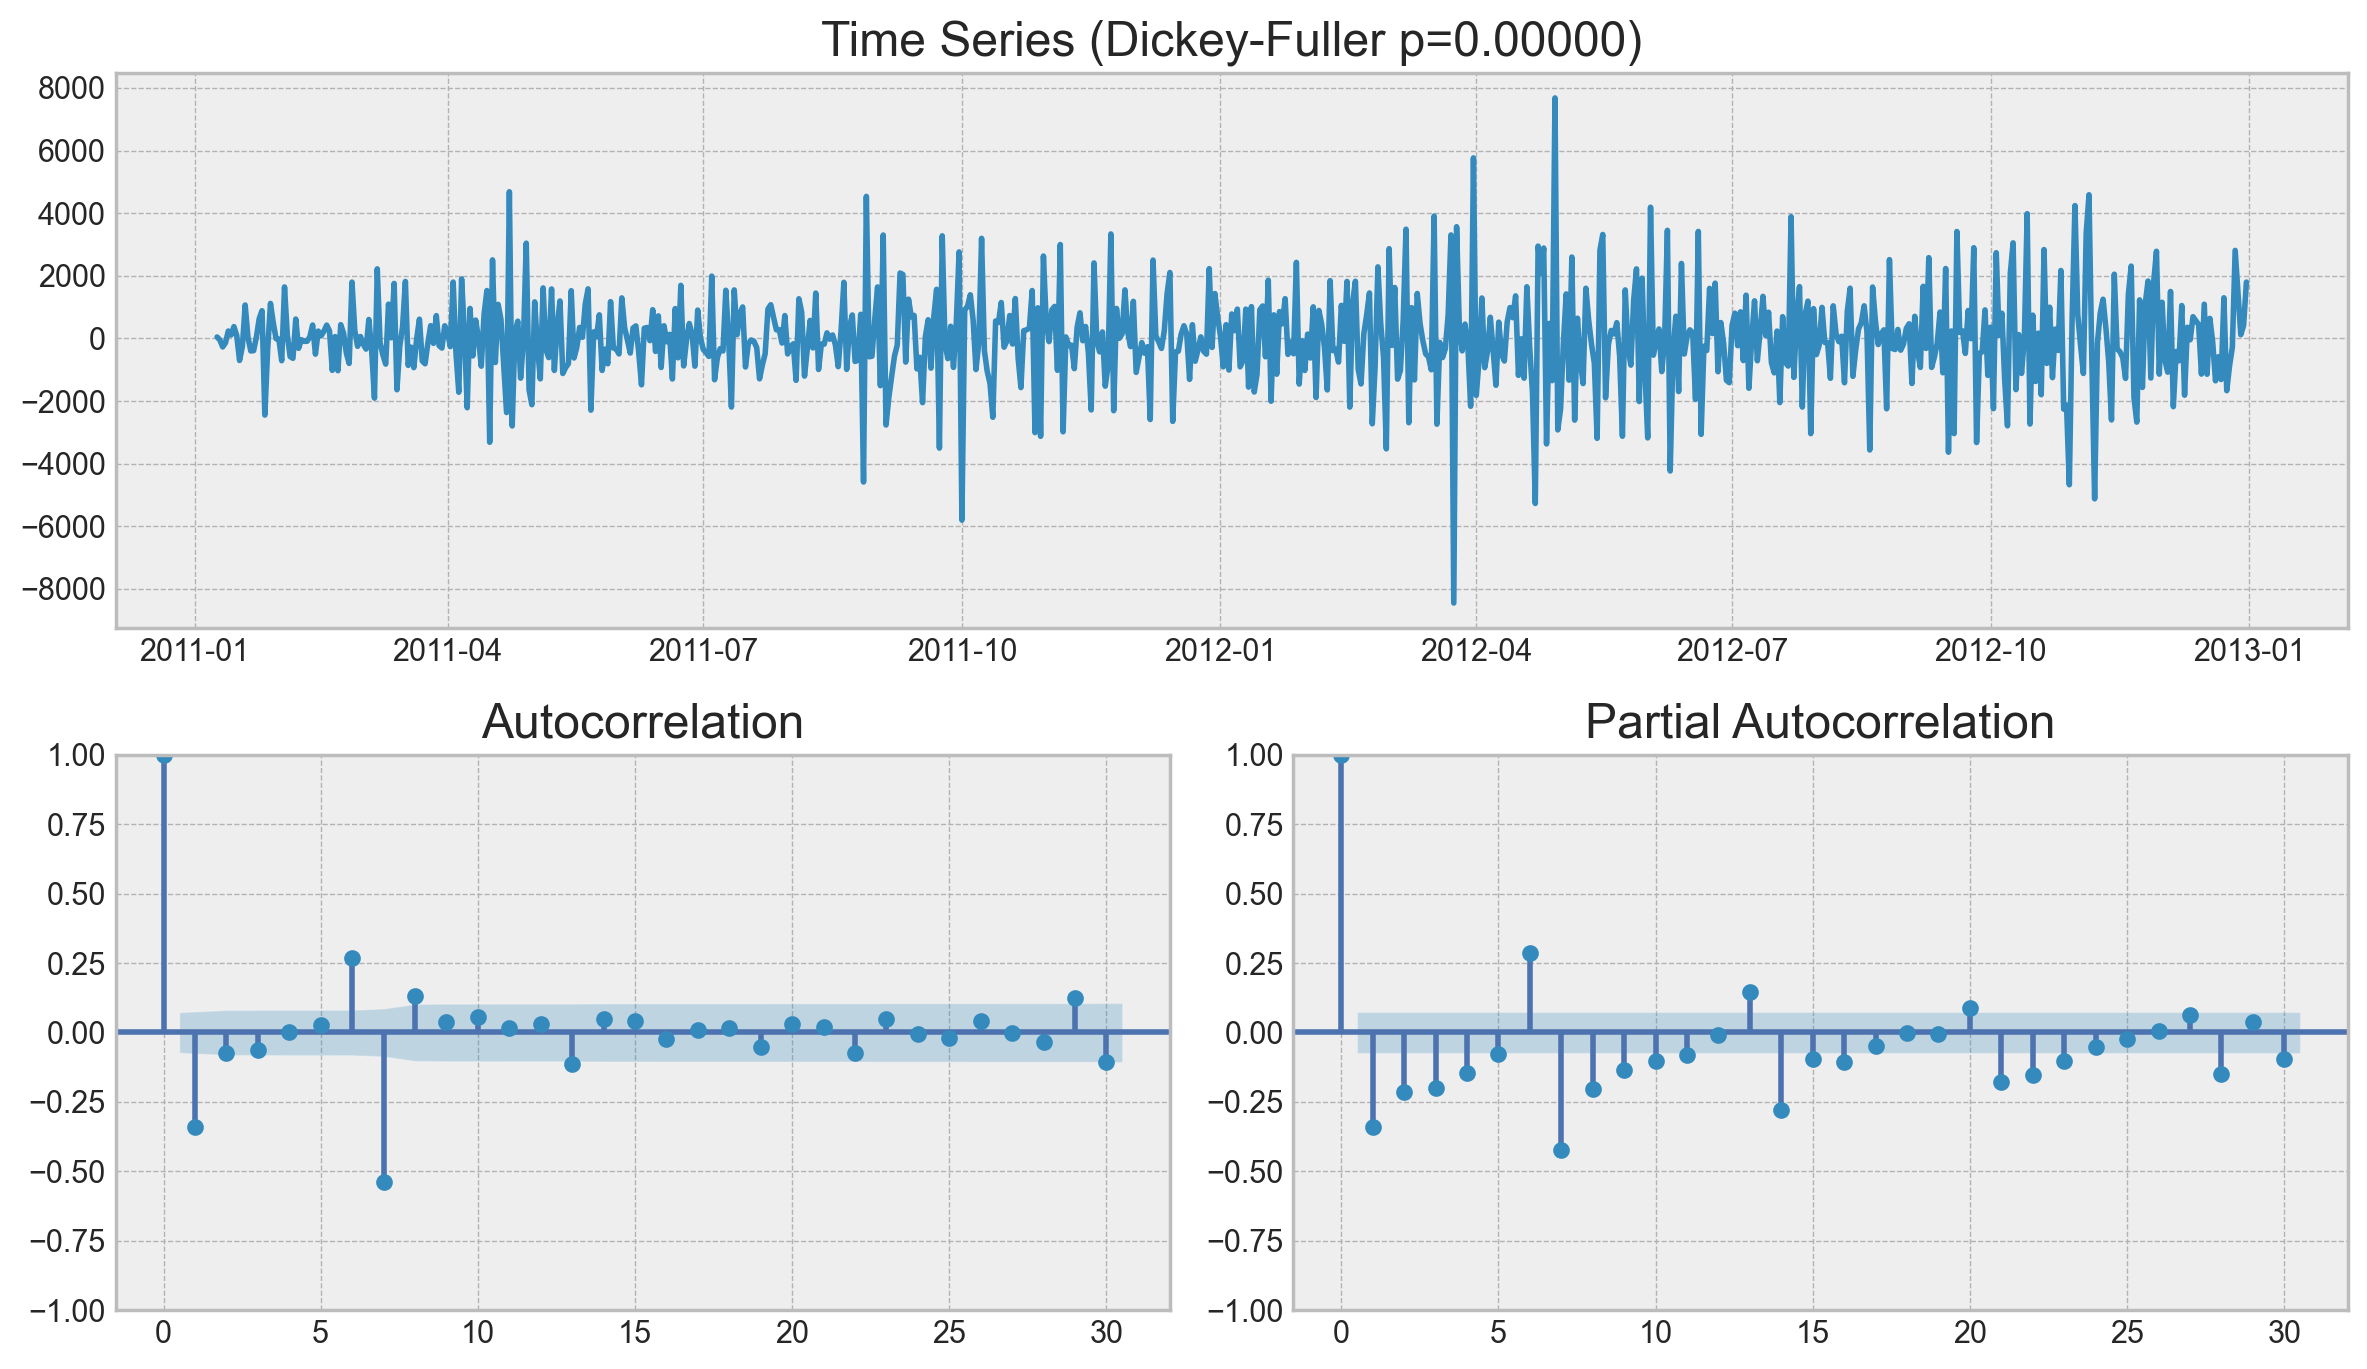

In [212]:
cnt = ts["cnt"]

cnt_diff_season = cnt - cnt.shift(7)
tsplot(cnt_diff_season[7:], lags=30)

cnt_diff = cnt_diff_season - cnt_diff_season.shift(1)
tsplot(cnt_diff[7 + 1:], lags=30)

SARIMA parameter search (daily with weekly seasonality)

In [213]:
ps = range(0, 3)
d = 1
qs = range(0, 3)
Ps = range(0, 2)
D = 1
Qs = range(0, 2)
s = 7  

parameters = product(ps, qs, Ps, Qs)
parameters_list = list(parameters)
len(parameters_list)

36

Optimization

In [214]:
def optimizeSARIMA(series, parameters_list, d, D, s):
    results = []
    best_aic = float("inf")
    best_model = None

    for param in parameters_list:   
        try:
            model = sm.tsa.statespace.SARIMAX(
                series,
                order=(param[0], d, param[1]),
                seasonal_order=(param[2], D, param[3], s),
            ).fit(disp=-1)
        except Exception:
            continue

        aic = model.aic
        if aic < best_aic:
            best_aic = aic
            best_model = model
            best_param = param
        results.append([param, aic])

    result_table = pd.DataFrame(results, columns=["parameters", "aic"])
    result_table = result_table.sort_values("aic").reset_index(drop=True)

    return result_table, best_model

In [215]:
result_table, best_model = optimizeSARIMA(ts["cnt"], parameters_list, d, D, s)
result_table.head()

,parameters,aic
0,"(1, 1, 1, 1)",11949.072963
1,"(2, 1, 0, 1)",11949.856196
2,"(1, 2, 0, 1)",11949.899505
3,"(2, 1, 1, 1)",11950.637064
4,"(1, 2, 1, 1)",11950.726869


In [216]:
print(best_model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                               cnt   No. Observations:                  731
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -5969.536
Date:                           Fri, 28 Nov 2025   AIC                          11949.073
Time:                                   02:16:26   BIC                          11971.990
Sample:                               01-01-2011   HQIC                         11957.918
                                    - 12-31-2012                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3509      0.038      9.294      0.000       0.277       0.425
ma.L1         -0.8912      0.022    -40.311

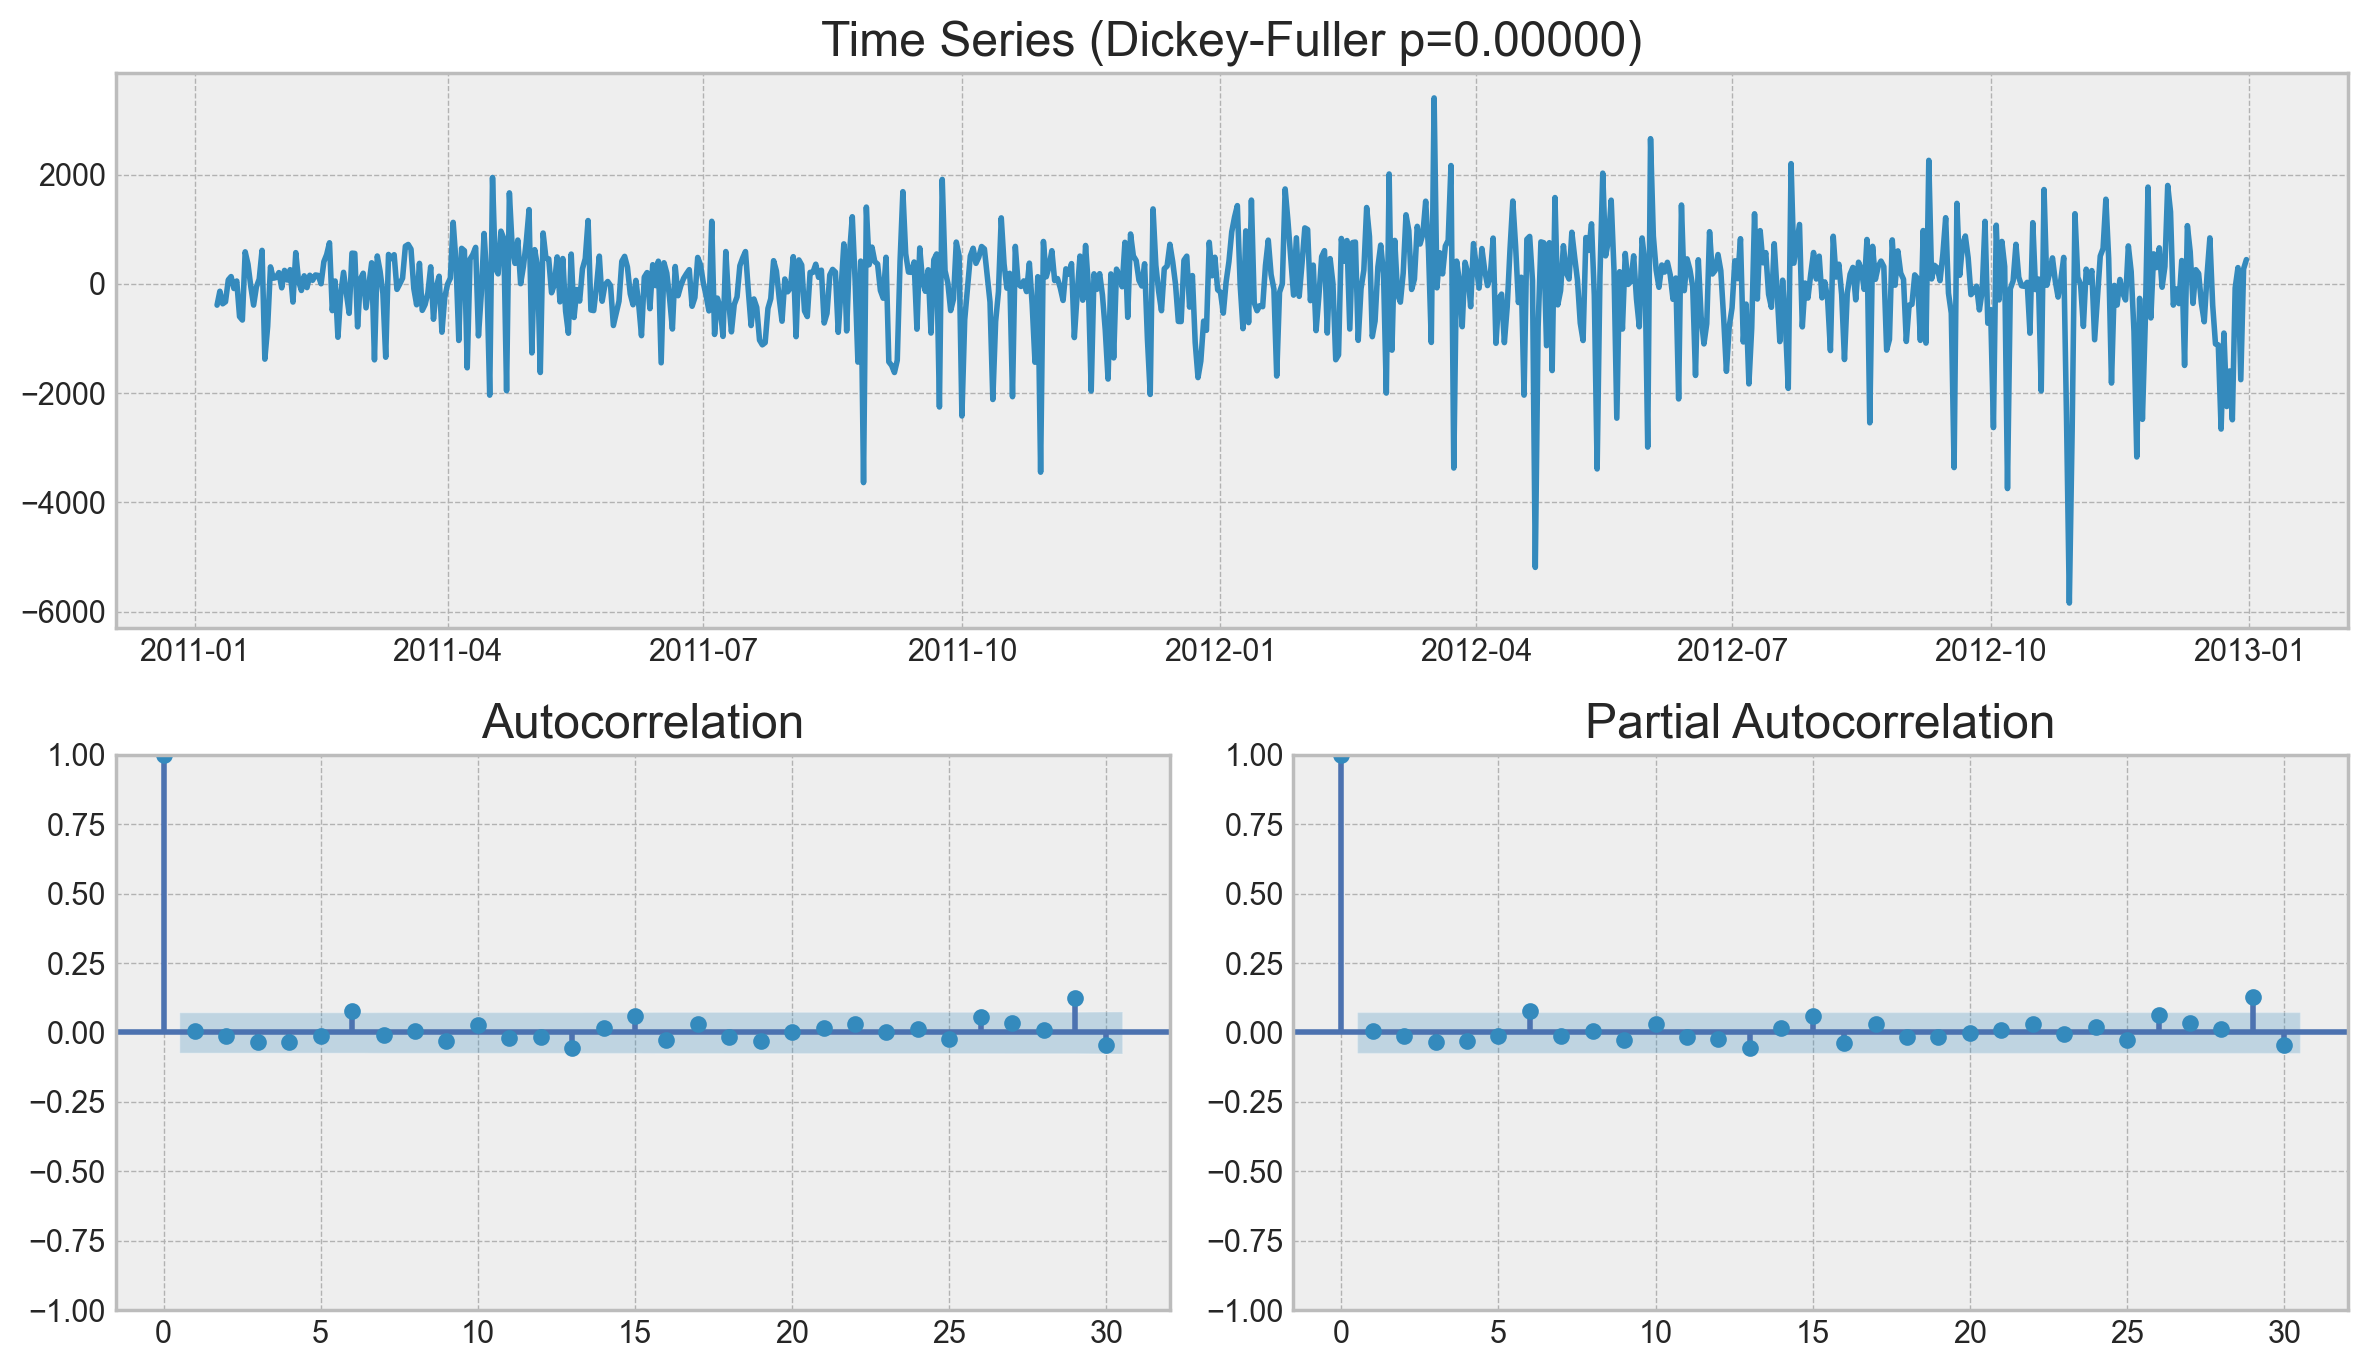

In [217]:
tsplot(best_model.resid[s + d:], lags=30)

In [218]:
def plotSARIMA(series, model, s, d, n_steps):
    data = series.to_frame(name="actual").copy()
    data["arima_model"] = model.fittedvalues
    data["arima_model"][: s + d] = np.nan

    forecast = model.predict(start=data.shape[0], end=data.shape[0] + n_steps)

    error = mean_absolute_percentage_error(
        data["actual"][s + d:], data["arima_model"][s + d:]
    )

    plt.figure(figsize=(15, 7))
    plt.title(f"Mean Absolute Percentage Error: {error:.2f}%")
    plt.plot(forecast, color="r", label="forecast")
    plt.axvspan(data.index[-1], forecast.index[-1], alpha=0.3, color="lightgrey")
    plt.plot(data["actual"], label="actual")
    plt.legend()
    plt.grid(True);

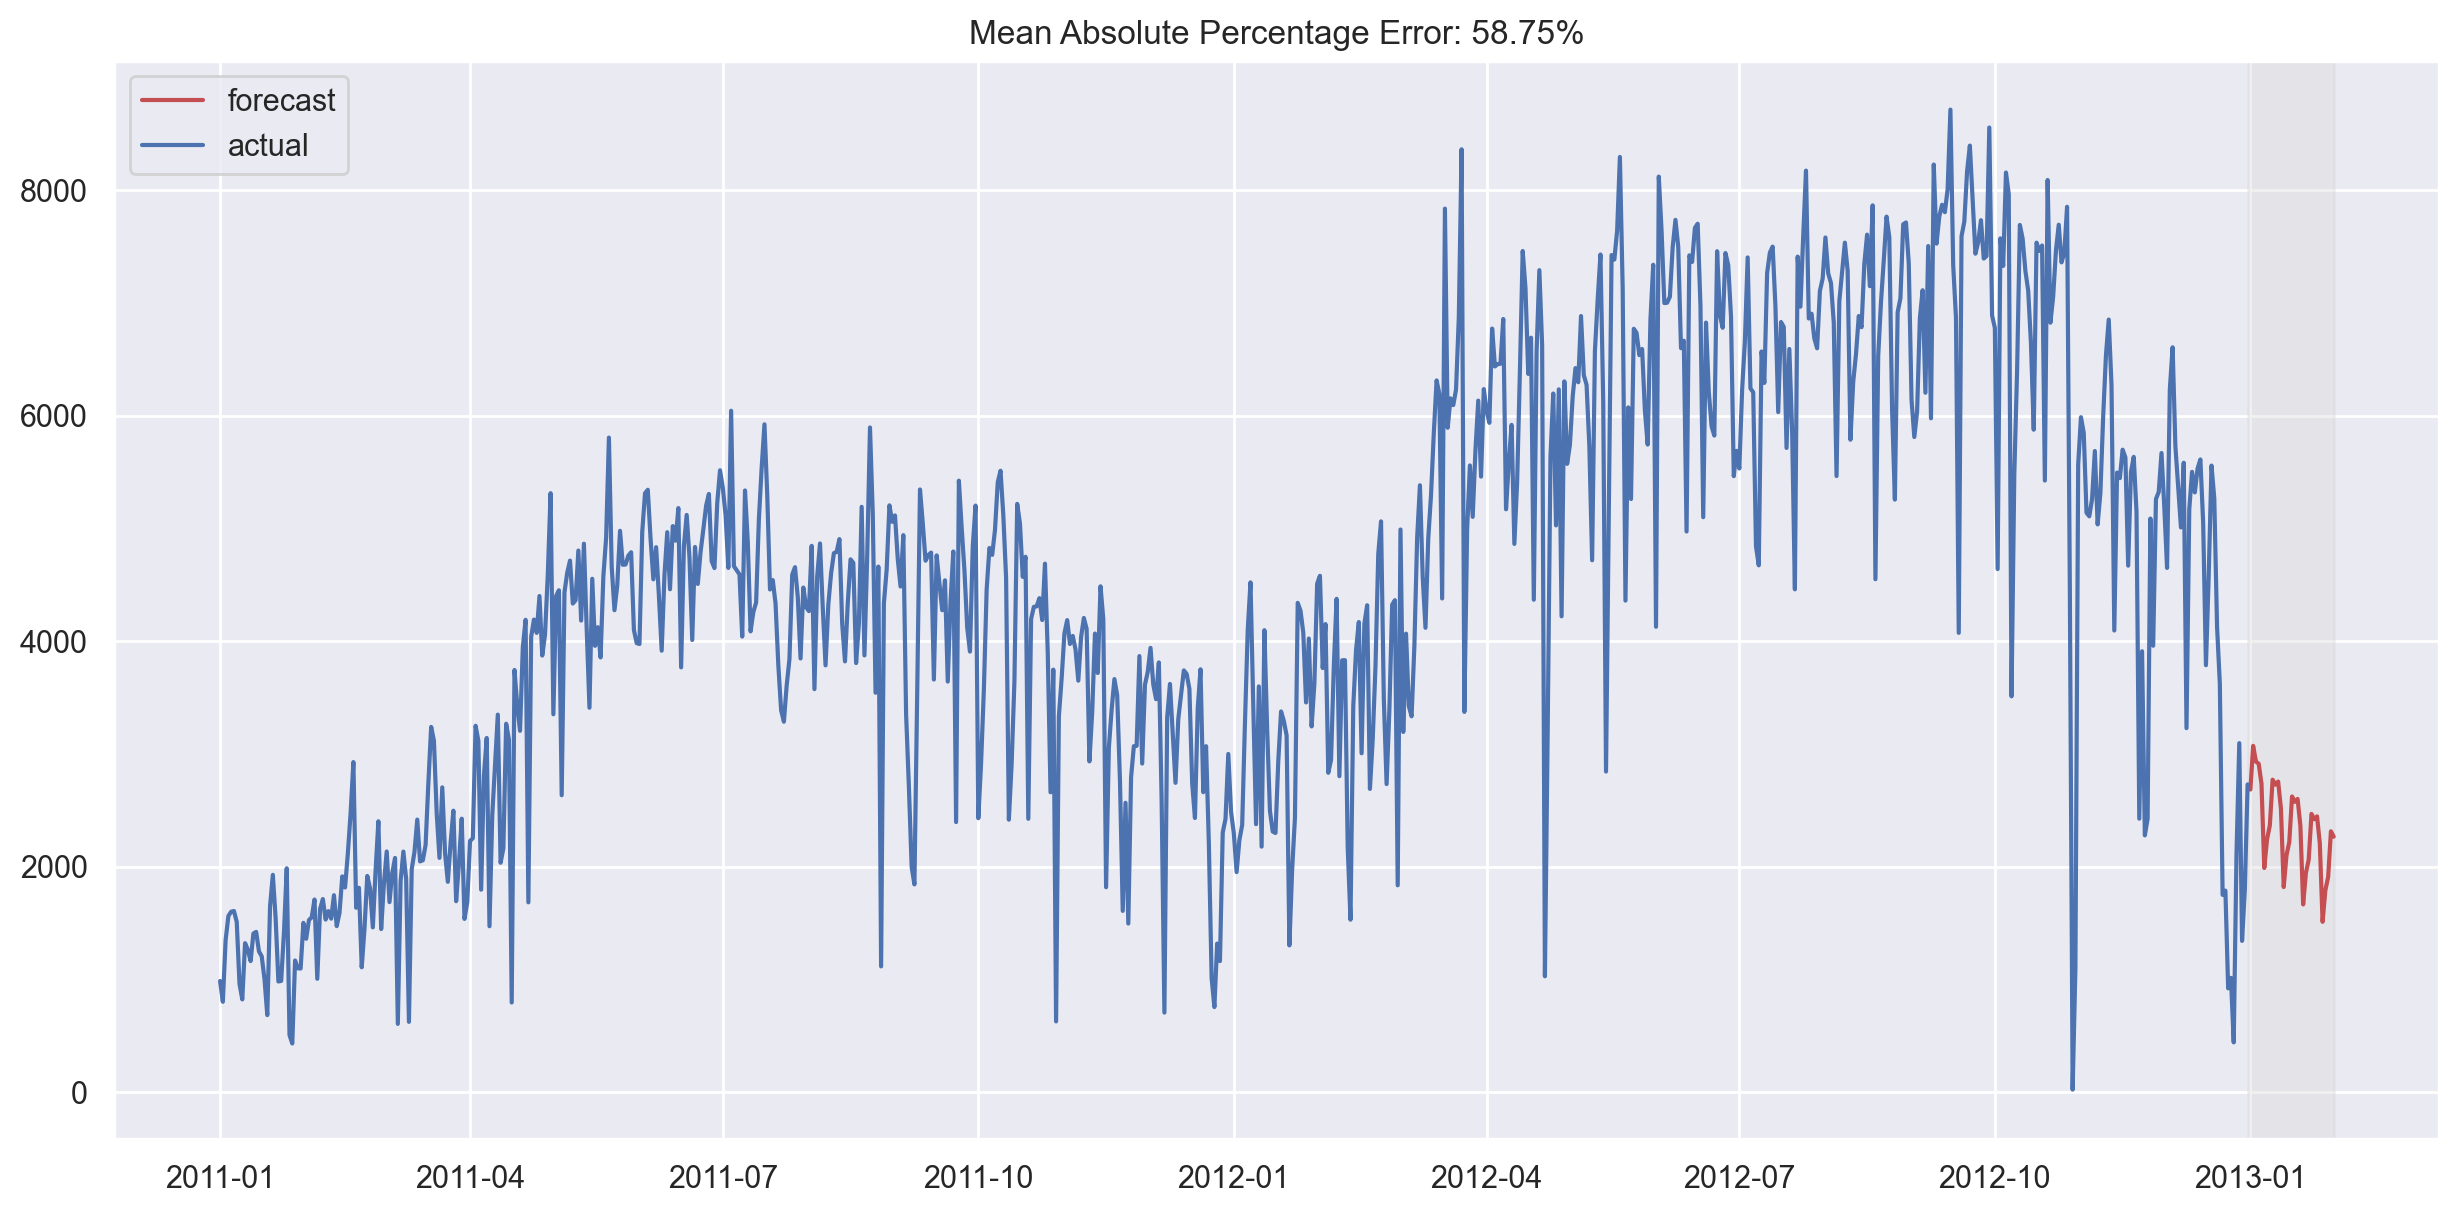

In [219]:
plotSARIMA(ts["cnt"], best_model, s, d, n_steps=30)

Linear models for time series

In [220]:
tscv = TimeSeriesSplit(n_splits=5)

def timeseries_train_test_split(X, y, test_size):
    test_index = int(len(X) * (1 - test_size))
    X_train = X.iloc[:test_index]
    y_train = y.iloc[:test_index]
    X_test = X.iloc[test_index:]
    y_test = y.iloc[test_index:]
    return X_train, X_test, y_train, y_test


lag features

In [221]:
data_lr = pd.DataFrame(ts["cnt"].copy())
data_lr.columns = ["y"]

for i in range(7, 31):
    data_lr[f"lag_{i}"] = data_lr["y"].shift(i)

data_lr.tail()

,y,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,...,lag_21,lag_22,lag_23,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30
dteday,,,,,,,,,,,,,,,,,,,,,
2012-12-27,2114,4128.0,5267.0,5557.0,4585.0,3786.0,5047.0,5611.0,5532.0,5319.0,...,5375.0,5729.0,6606.0,6234.0,4649.0,5191.0,5668.0,5323.0,5260.0,3959.0
2012-12-28,3095,3623.0,4128.0,5267.0,5557.0,4585.0,3786.0,5047.0,5611.0,5532.0,...,5008.0,5375.0,5729.0,6606.0,6234.0,4649.0,5191.0,5668.0,5323.0,5260.0
2012-12-29,1341,1749.0,3623.0,4128.0,5267.0,5557.0,4585.0,3786.0,5047.0,5611.0,...,5582.0,5008.0,5375.0,5729.0,6606.0,6234.0,4649.0,5191.0,5668.0,5323.0
2012-12-30,1796,1787.0,1749.0,3623.0,4128.0,5267.0,5557.0,4585.0,3786.0,5047.0,...,3228.0,5582.0,5008.0,5375.0,5729.0,6606.0,6234.0,4649.0,5191.0,5668.0
2012-12-31,2729,920.0,1787.0,1749.0,3623.0,4128.0,5267.0,5557.0,4585.0,3786.0,...,5170.0,3228.0,5582.0,5008.0,5375.0,5729.0,6606.0,6234.0,4649.0,5191.0


In [222]:
y = data_lr.dropna()["y"]
X = data_lr.dropna().drop(["y"], axis=1)

X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=0.3)

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [223]:
def plotModelResults(model, X_train, X_test, y_train, y_test,
                     plot_intervals=False, plot_anomalies=False):
    prediction = model.predict(X_test)

    plt.figure(figsize=(15, 7))
    plt.plot(prediction, "g", label="prediction", linewidth=2.0)
    plt.plot(y_test.values, label="actual", linewidth=2.0)

    if plot_intervals:
        cv = cross_val_score(
            model, X_train, y_train, cv=tscv, scoring="neg_mean_absolute_error"
        )
        mae = -cv.mean()
        deviation = cv.std()
        scale = 1.96
        lower = prediction - (mae + scale * deviation)
        upper = prediction + (mae + scale * deviation)
        plt.plot(lower, "r--", alpha=0.5, label="bounds")
        plt.plot(upper, "r--", alpha=0.5)

        if plot_anomalies:
            anomalies = np.array([np.nan] * len(y_test))
            anomalies[y_test < lower] = y_test[y_test < lower]
            anomalies[y_test > upper] = y_test[y_test > upper]
            plt.plot(anomalies, "o", markersize=8, label="anomalies")

    error = mean_absolute_percentage_error(y_test, prediction)
    plt.title(f"Mean absolute percentage error {error:.2f}%")
    plt.legend(loc="best")
    plt.grid(True)

def plotCoefficients(model, feature_names):
    coefs = pd.DataFrame(model.coef_, index=feature_names, columns=["coef"])
    coefs["abs"] = np.abs(coefs["coef"])
    coefs = coefs.sort_values(by="abs", ascending=False).drop(columns="abs")

    plt.figure(figsize=(15, 7))
    coefs["coef"].plot(kind="bar")
    plt.grid(axis="y")
    plt.hlines(0, 0, len(coefs), linestyles="dashed");


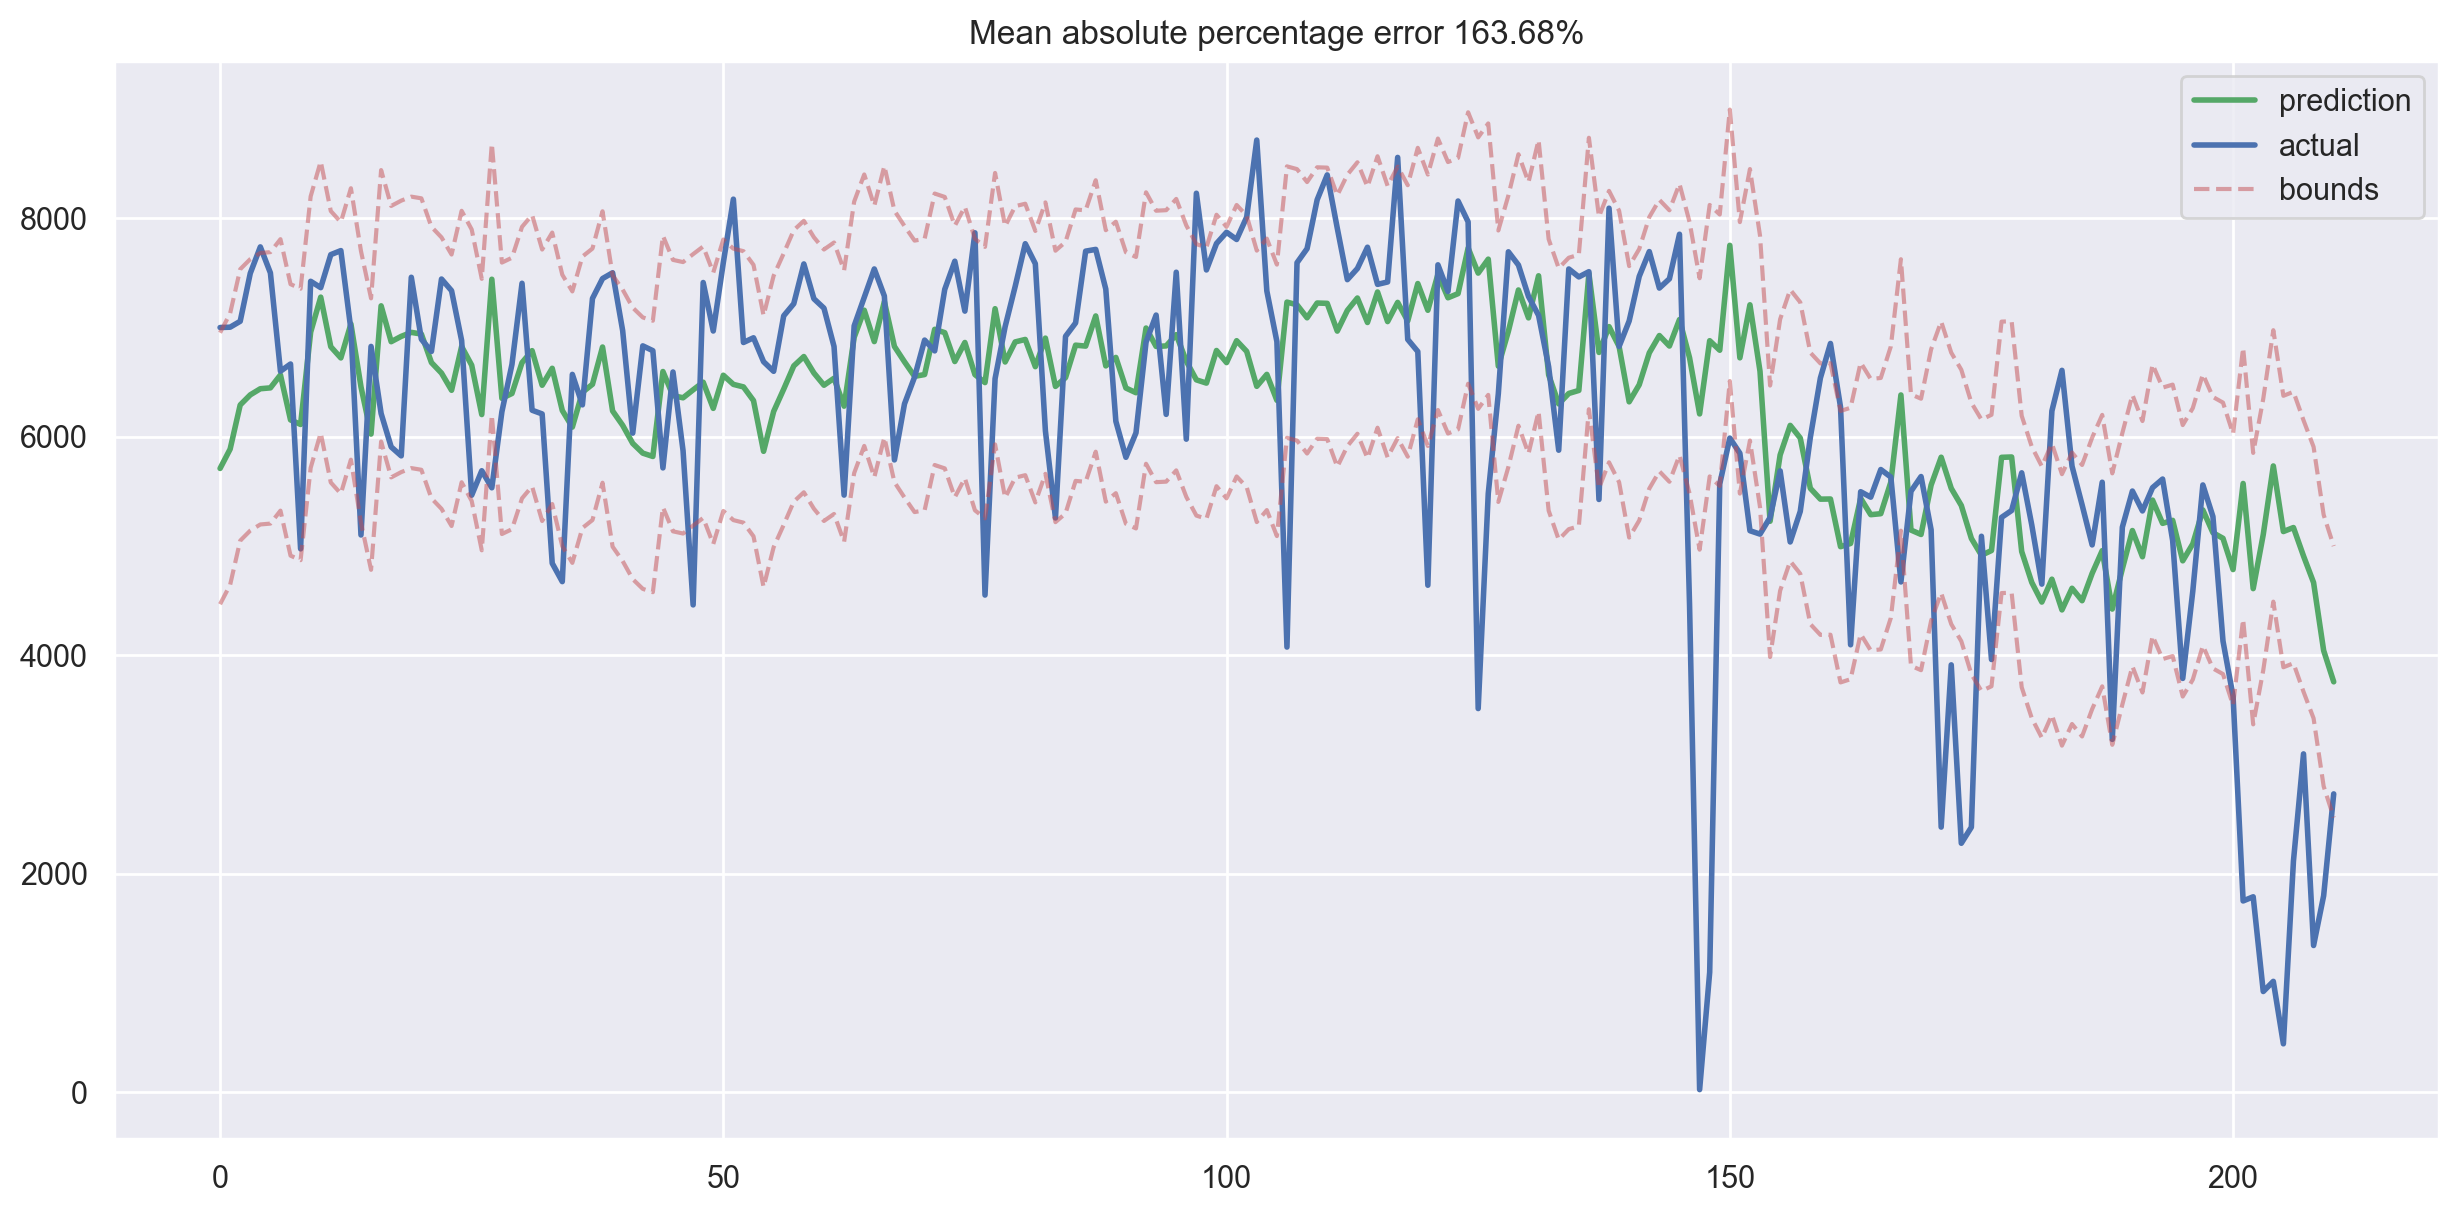

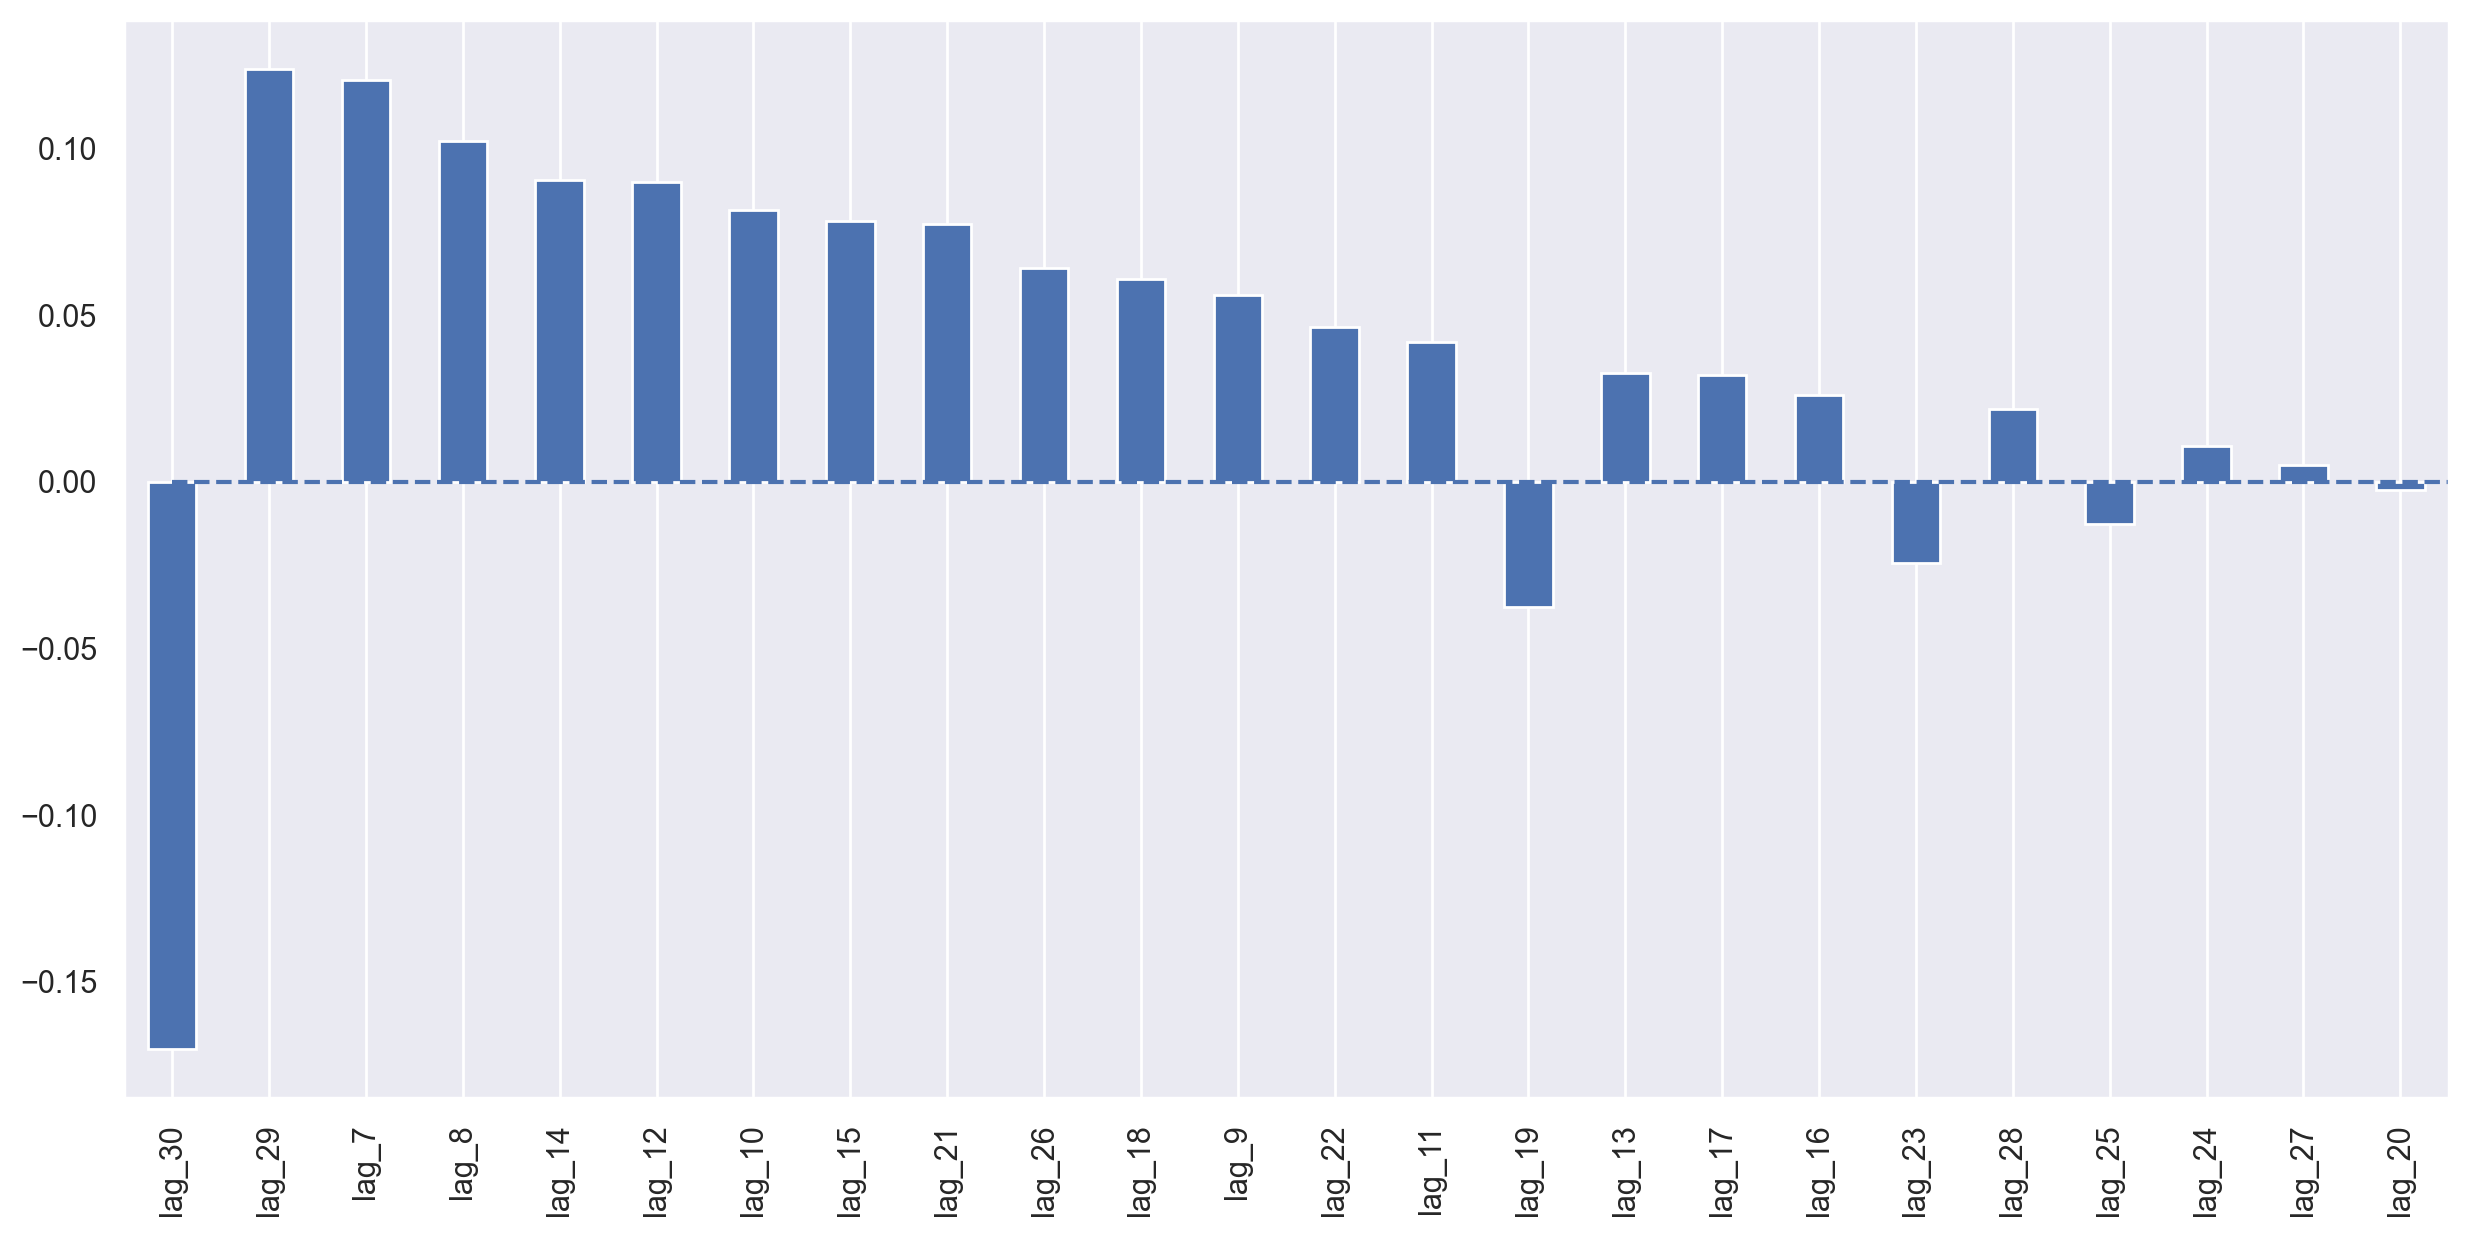

In [224]:
plotModelResults(lr, X_train, X_test, y_train, y_test, plot_intervals=True)
plotCoefficients(lr, X_train.columns)

Modifications with adding date/time features (day of week, month, weekend)

In [225]:
data_lr.index = pd.to_datetime(data_lr.index)
data_lr["dow"] = data_lr.index.dayofweek
data_lr["month"] = data_lr.index.month
data_lr["is_weekend"] = data_lr["dow"].isin([5, 6]).astype(int)

data_lr.tail()

,y,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,...,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30,dow,month,is_weekend
dteday,,,,,,,,,,,,,,,,,,,,,
2012-12-27,2114,4128.0,5267.0,5557.0,4585.0,3786.0,5047.0,5611.0,5532.0,5319.0,...,6234.0,4649.0,5191.0,5668.0,5323.0,5260.0,3959.0,3,12,0
2012-12-28,3095,3623.0,4128.0,5267.0,5557.0,4585.0,3786.0,5047.0,5611.0,5532.0,...,6606.0,6234.0,4649.0,5191.0,5668.0,5323.0,5260.0,4,12,0
2012-12-29,1341,1749.0,3623.0,4128.0,5267.0,5557.0,4585.0,3786.0,5047.0,5611.0,...,5729.0,6606.0,6234.0,4649.0,5191.0,5668.0,5323.0,5,12,1
2012-12-30,1796,1787.0,1749.0,3623.0,4128.0,5267.0,5557.0,4585.0,3786.0,5047.0,...,5375.0,5729.0,6606.0,6234.0,4649.0,5191.0,5668.0,6,12,1
2012-12-31,2729,920.0,1787.0,1749.0,3623.0,4128.0,5267.0,5557.0,4585.0,3786.0,...,5008.0,5375.0,5729.0,6606.0,6234.0,4649.0,5191.0,0,12,0


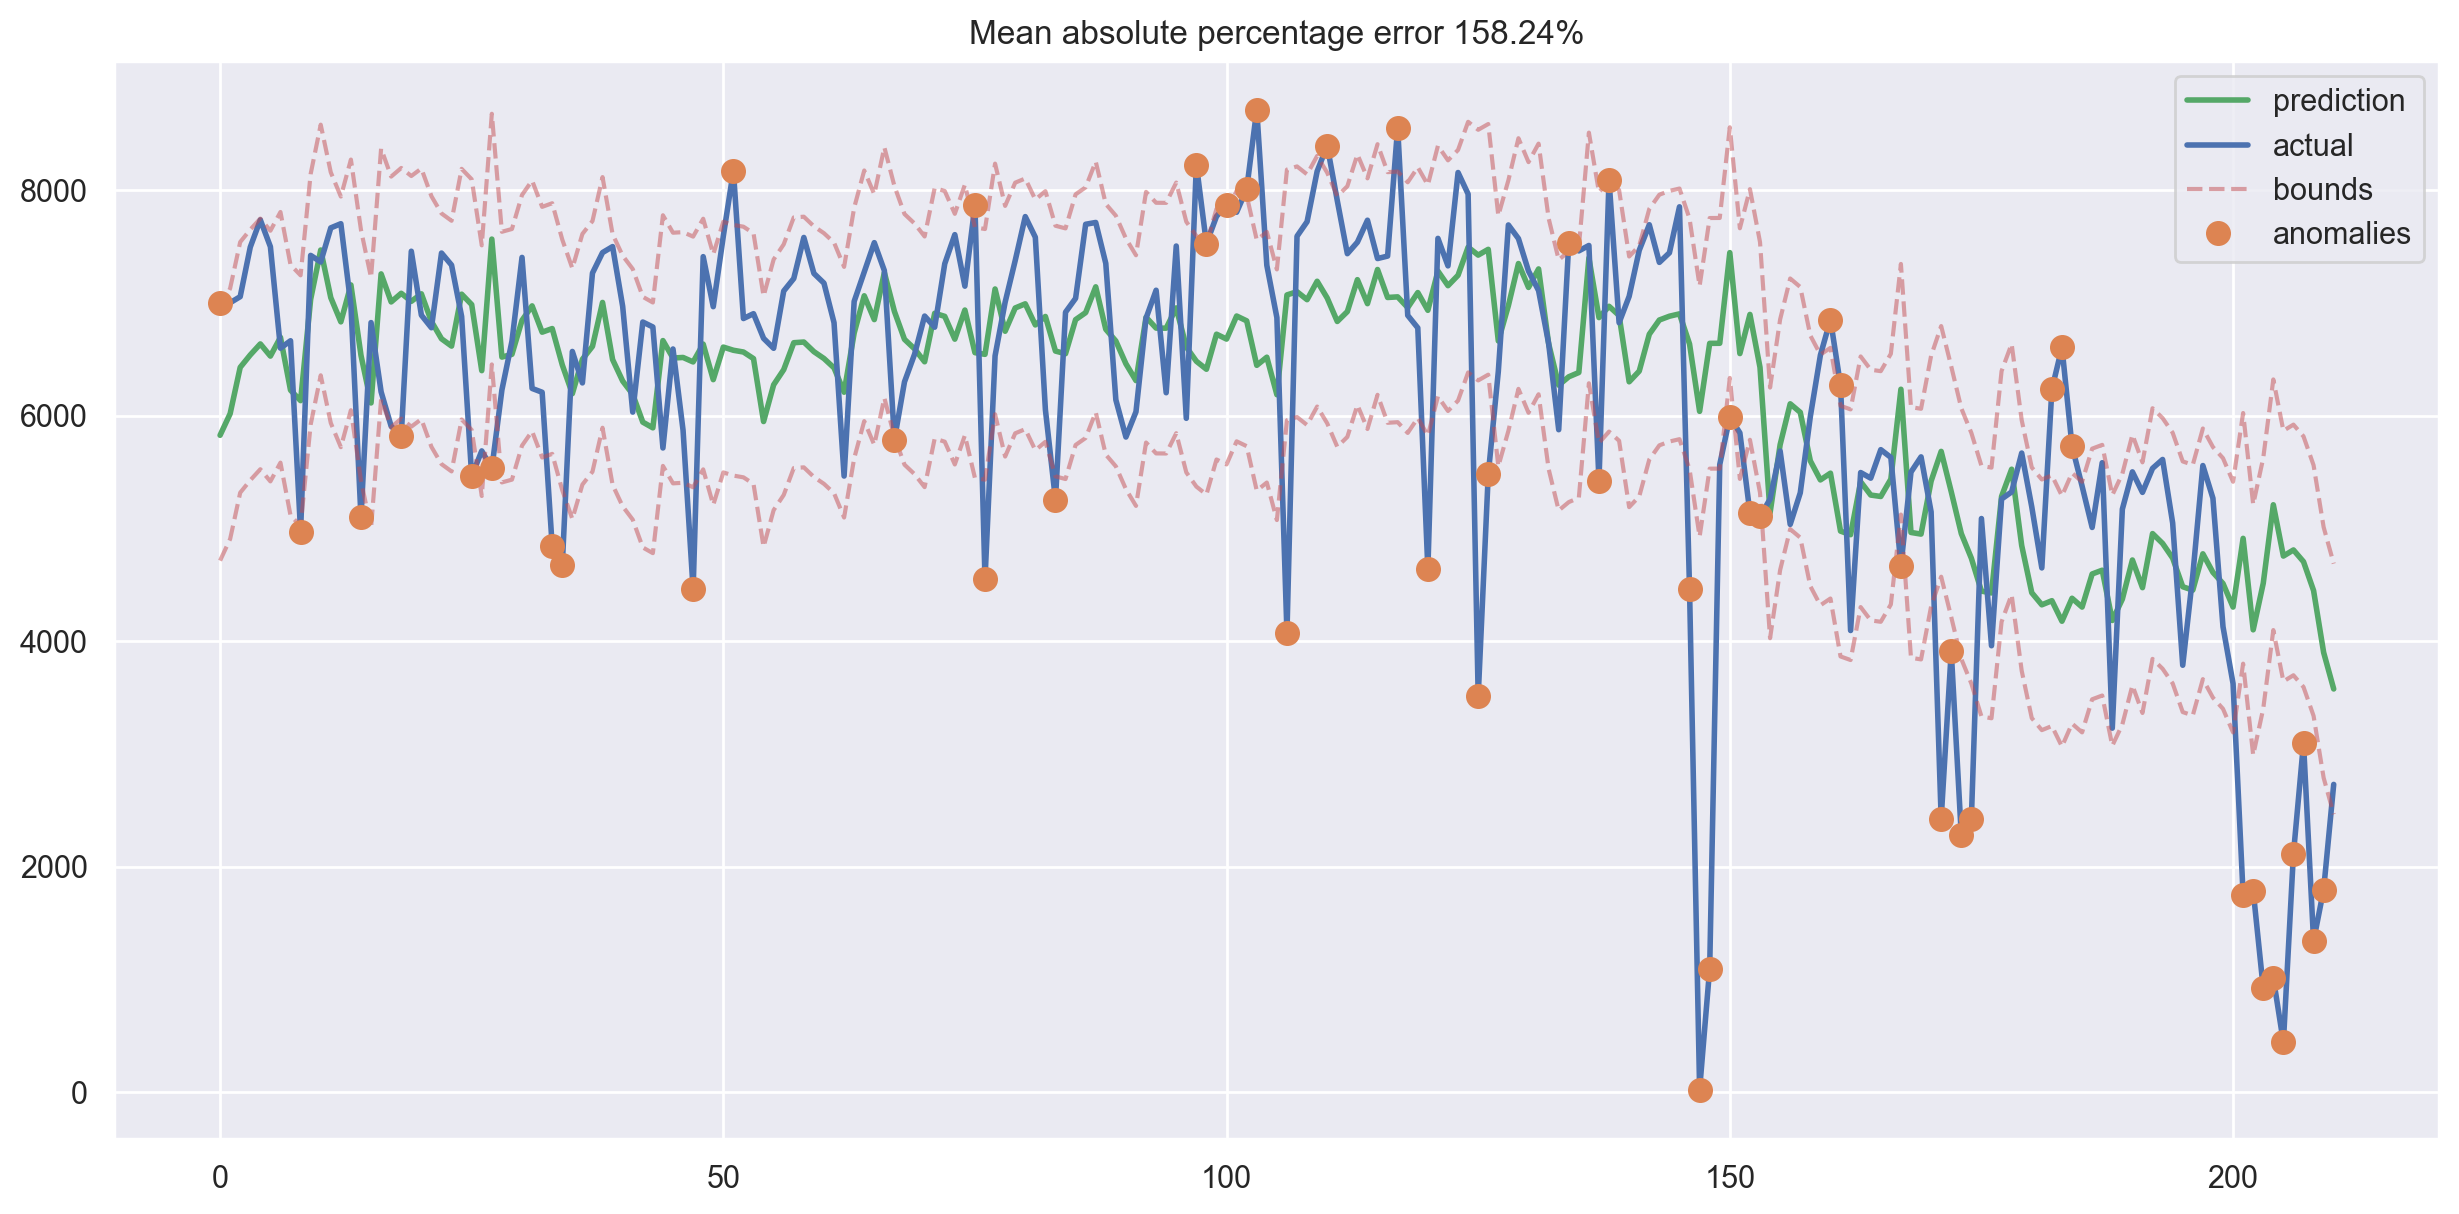

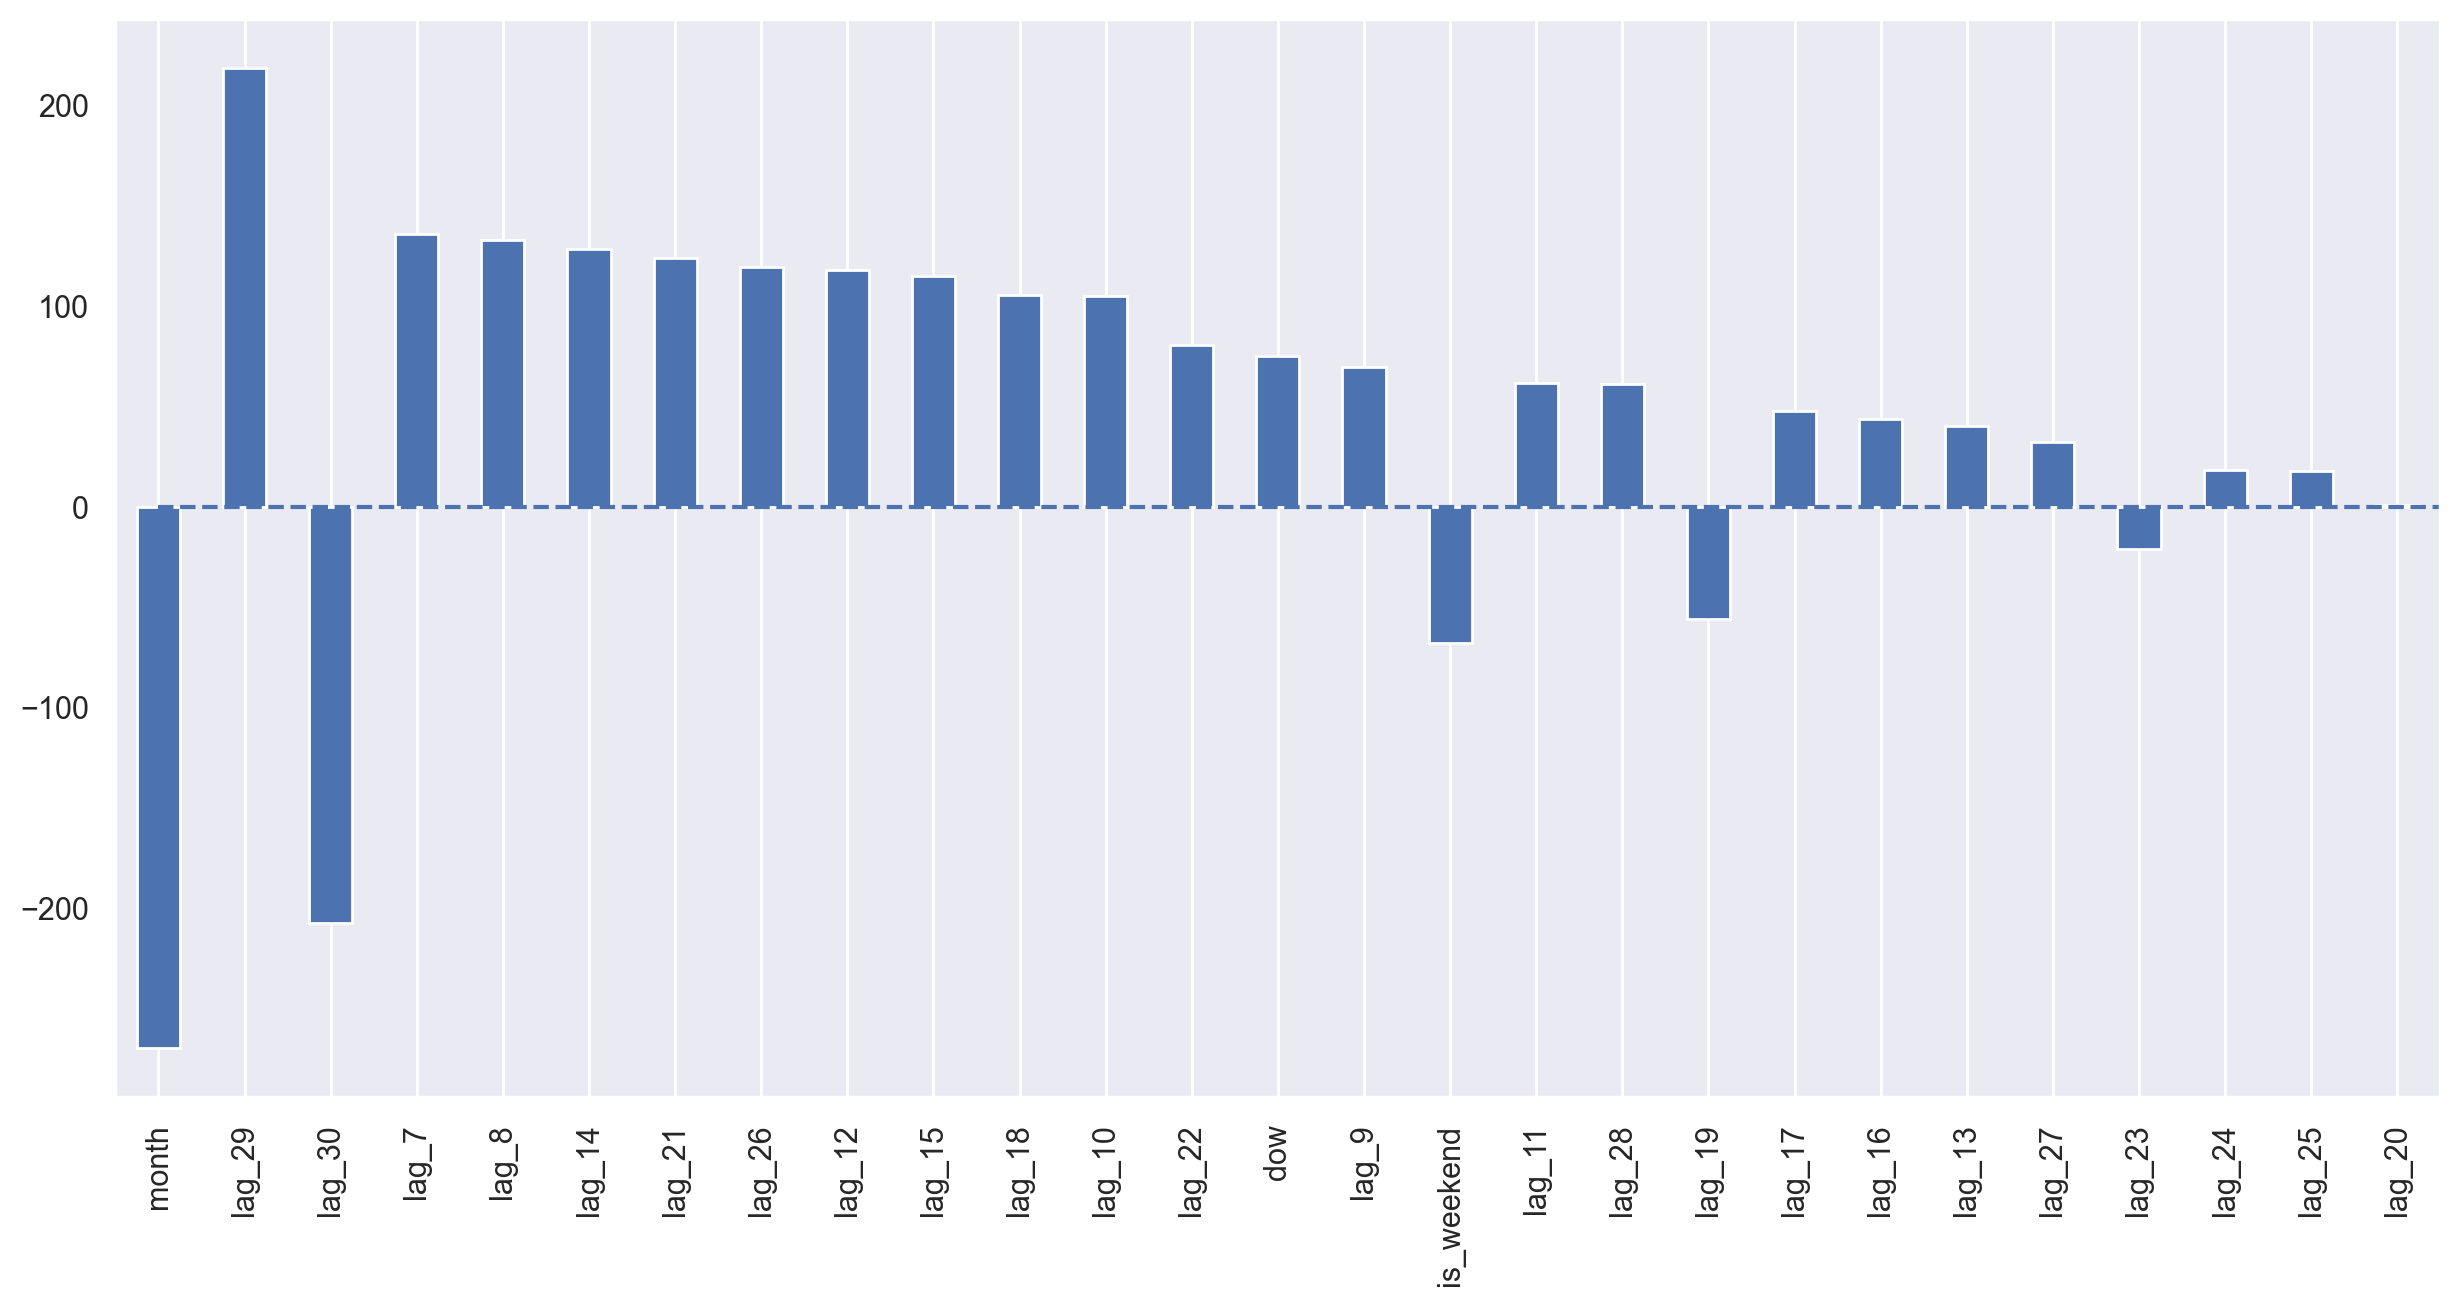

In [226]:
scaler = StandardScaler()
y = data_lr.dropna()["y"]
X = data_lr.dropna().drop(["y"], axis=1)

X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=0.3)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

plotModelResults(lr, X_train_scaled, X_test_scaled, y_train, y_test,
                 plot_intervals=True, plot_anomalies=True)
plotCoefficients(lr, X_train.columns)


Target encoding: day-of-week by average rentals

In [227]:
def code_mean(data, cat_feature, real_feature):
    return dict(data.groupby(cat_feature)[real_feature].mean())

In [228]:
def prepareData(series, lag_start, lag_end, test_size, target_encoding=False):
    data = pd.DataFrame(series.copy())
    data.columns = ["y"]

    for i in range(lag_start, lag_end):
        data[f"lag_{i}"] = data["y"].shift(i)

    data.index = pd.to_datetime(data.index)
    data["dow"] = data.index.dayofweek
    data["month"] = data.index.month
    data["is_weekend"] = data["dow"].isin([5, 6]).astype(int)

    if target_encoding:
        test_index = int(len(data.dropna()) * (1 - test_size))
        data_train = data.iloc[:test_index]

        dow_mean = code_mean(data_train, "dow", "y")
        month_mean = code_mean(data_train, "month", "y")

        data["dow_avg"] = data["dow"].map(dow_mean)
        data["month_avg"] = data["month"].map(month_mean)

        data.drop(["dow", "month"], axis=1, inplace=True)

    y = data.dropna()["y"]
    X = data.dropna().drop(["y"], axis=1)

    X_train, X_test, y_train, y_test = timeseries_train_test_split(
        X, y, test_size=test_size
    )
    return X_train, X_test, y_train, y_test

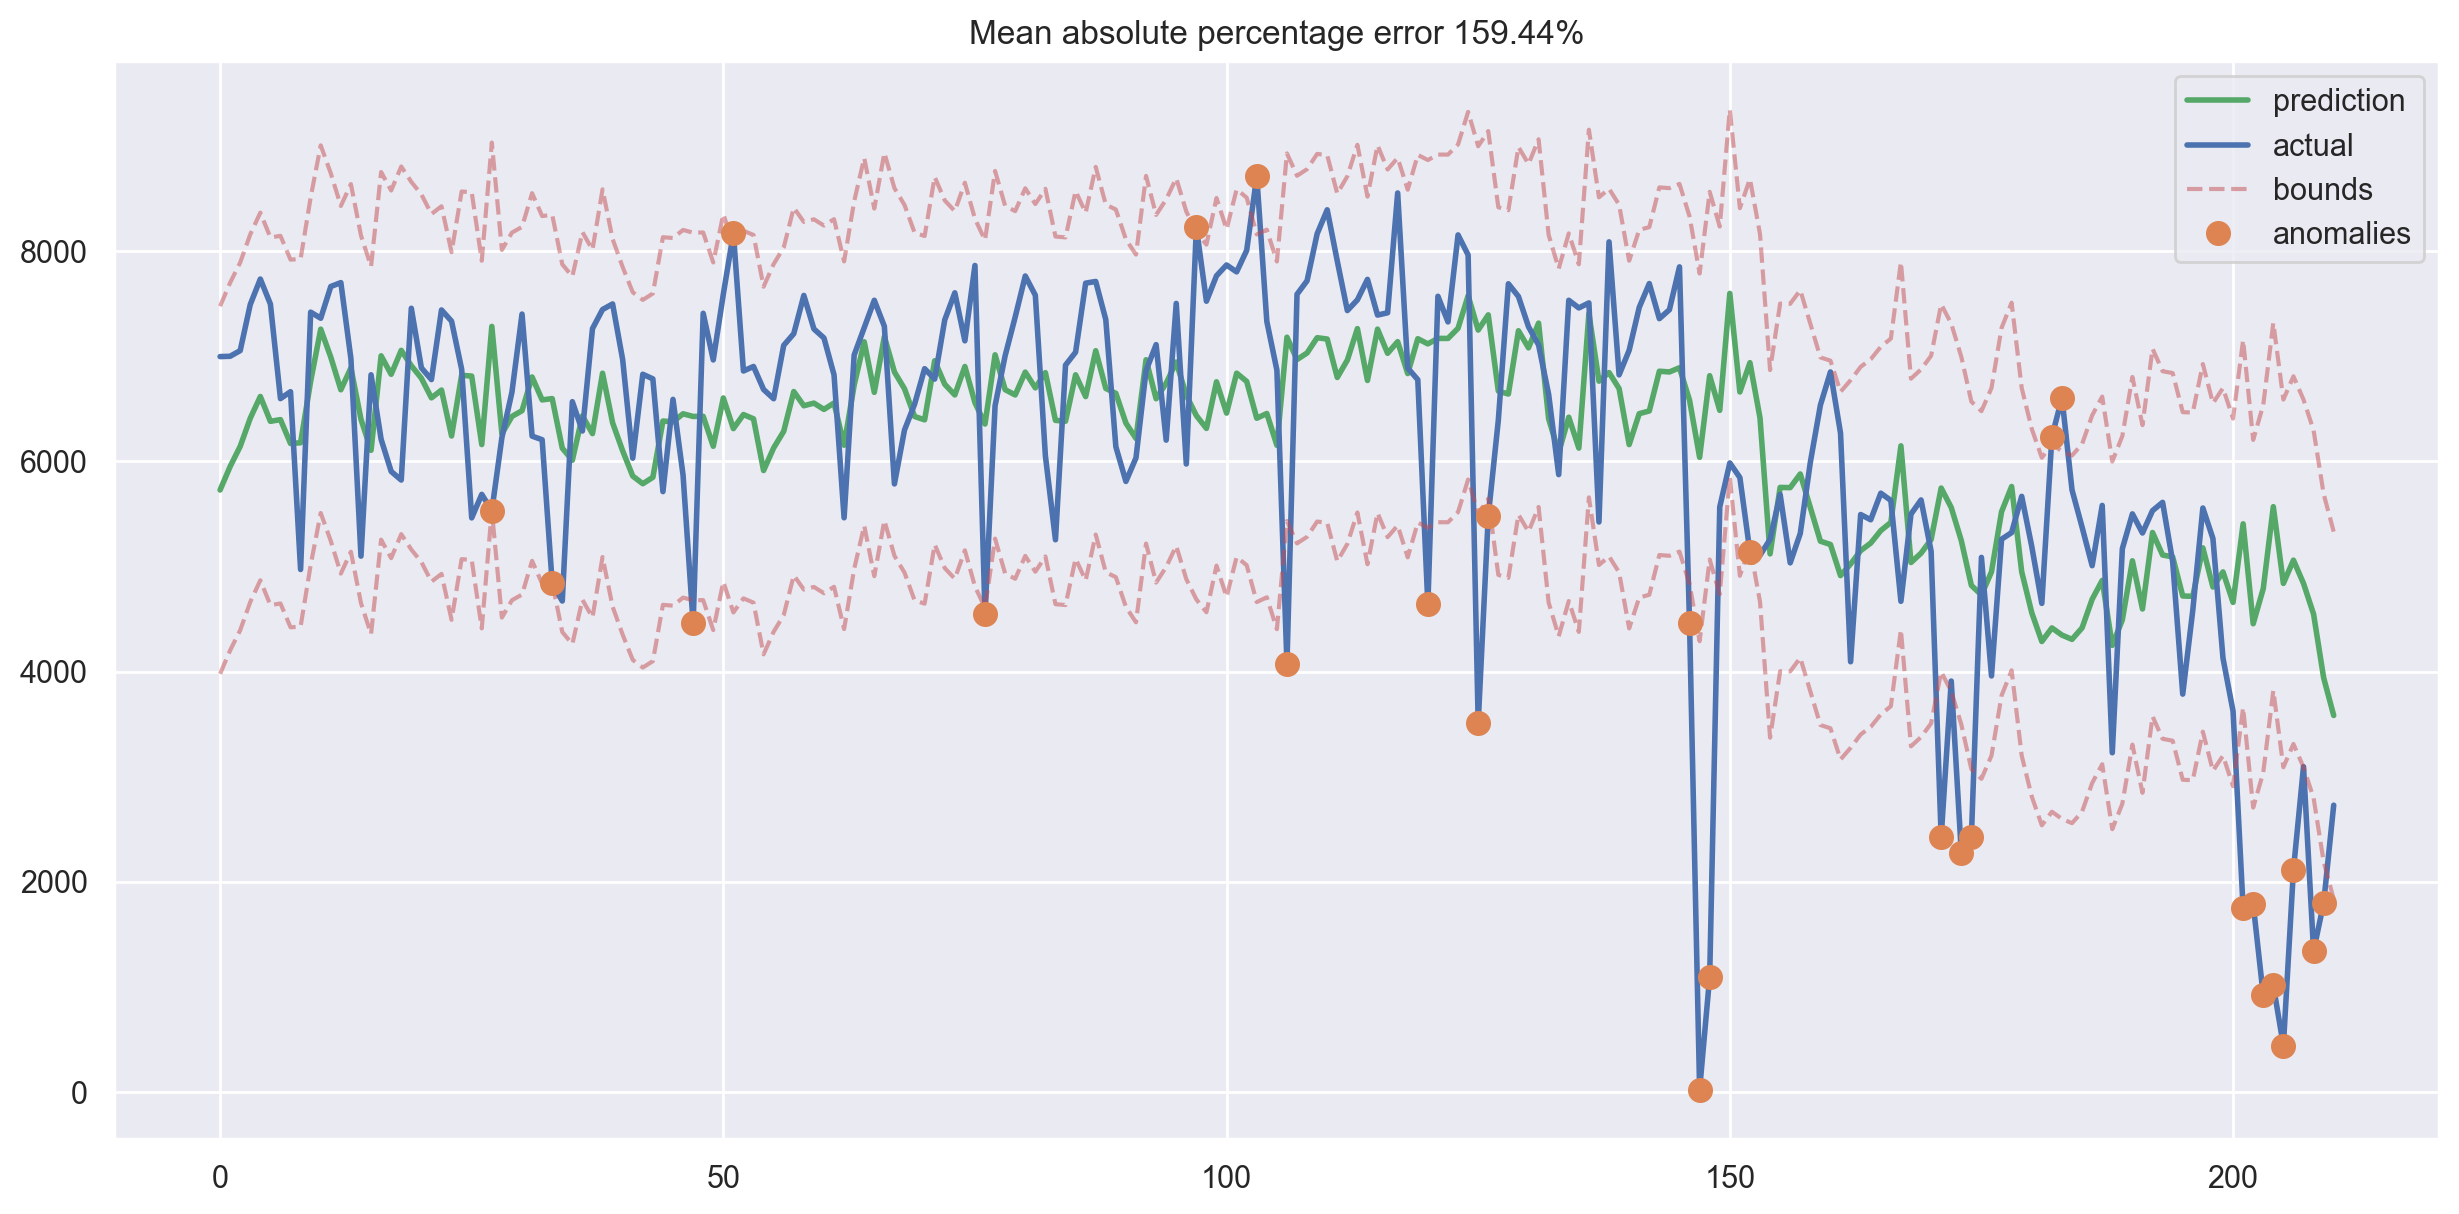

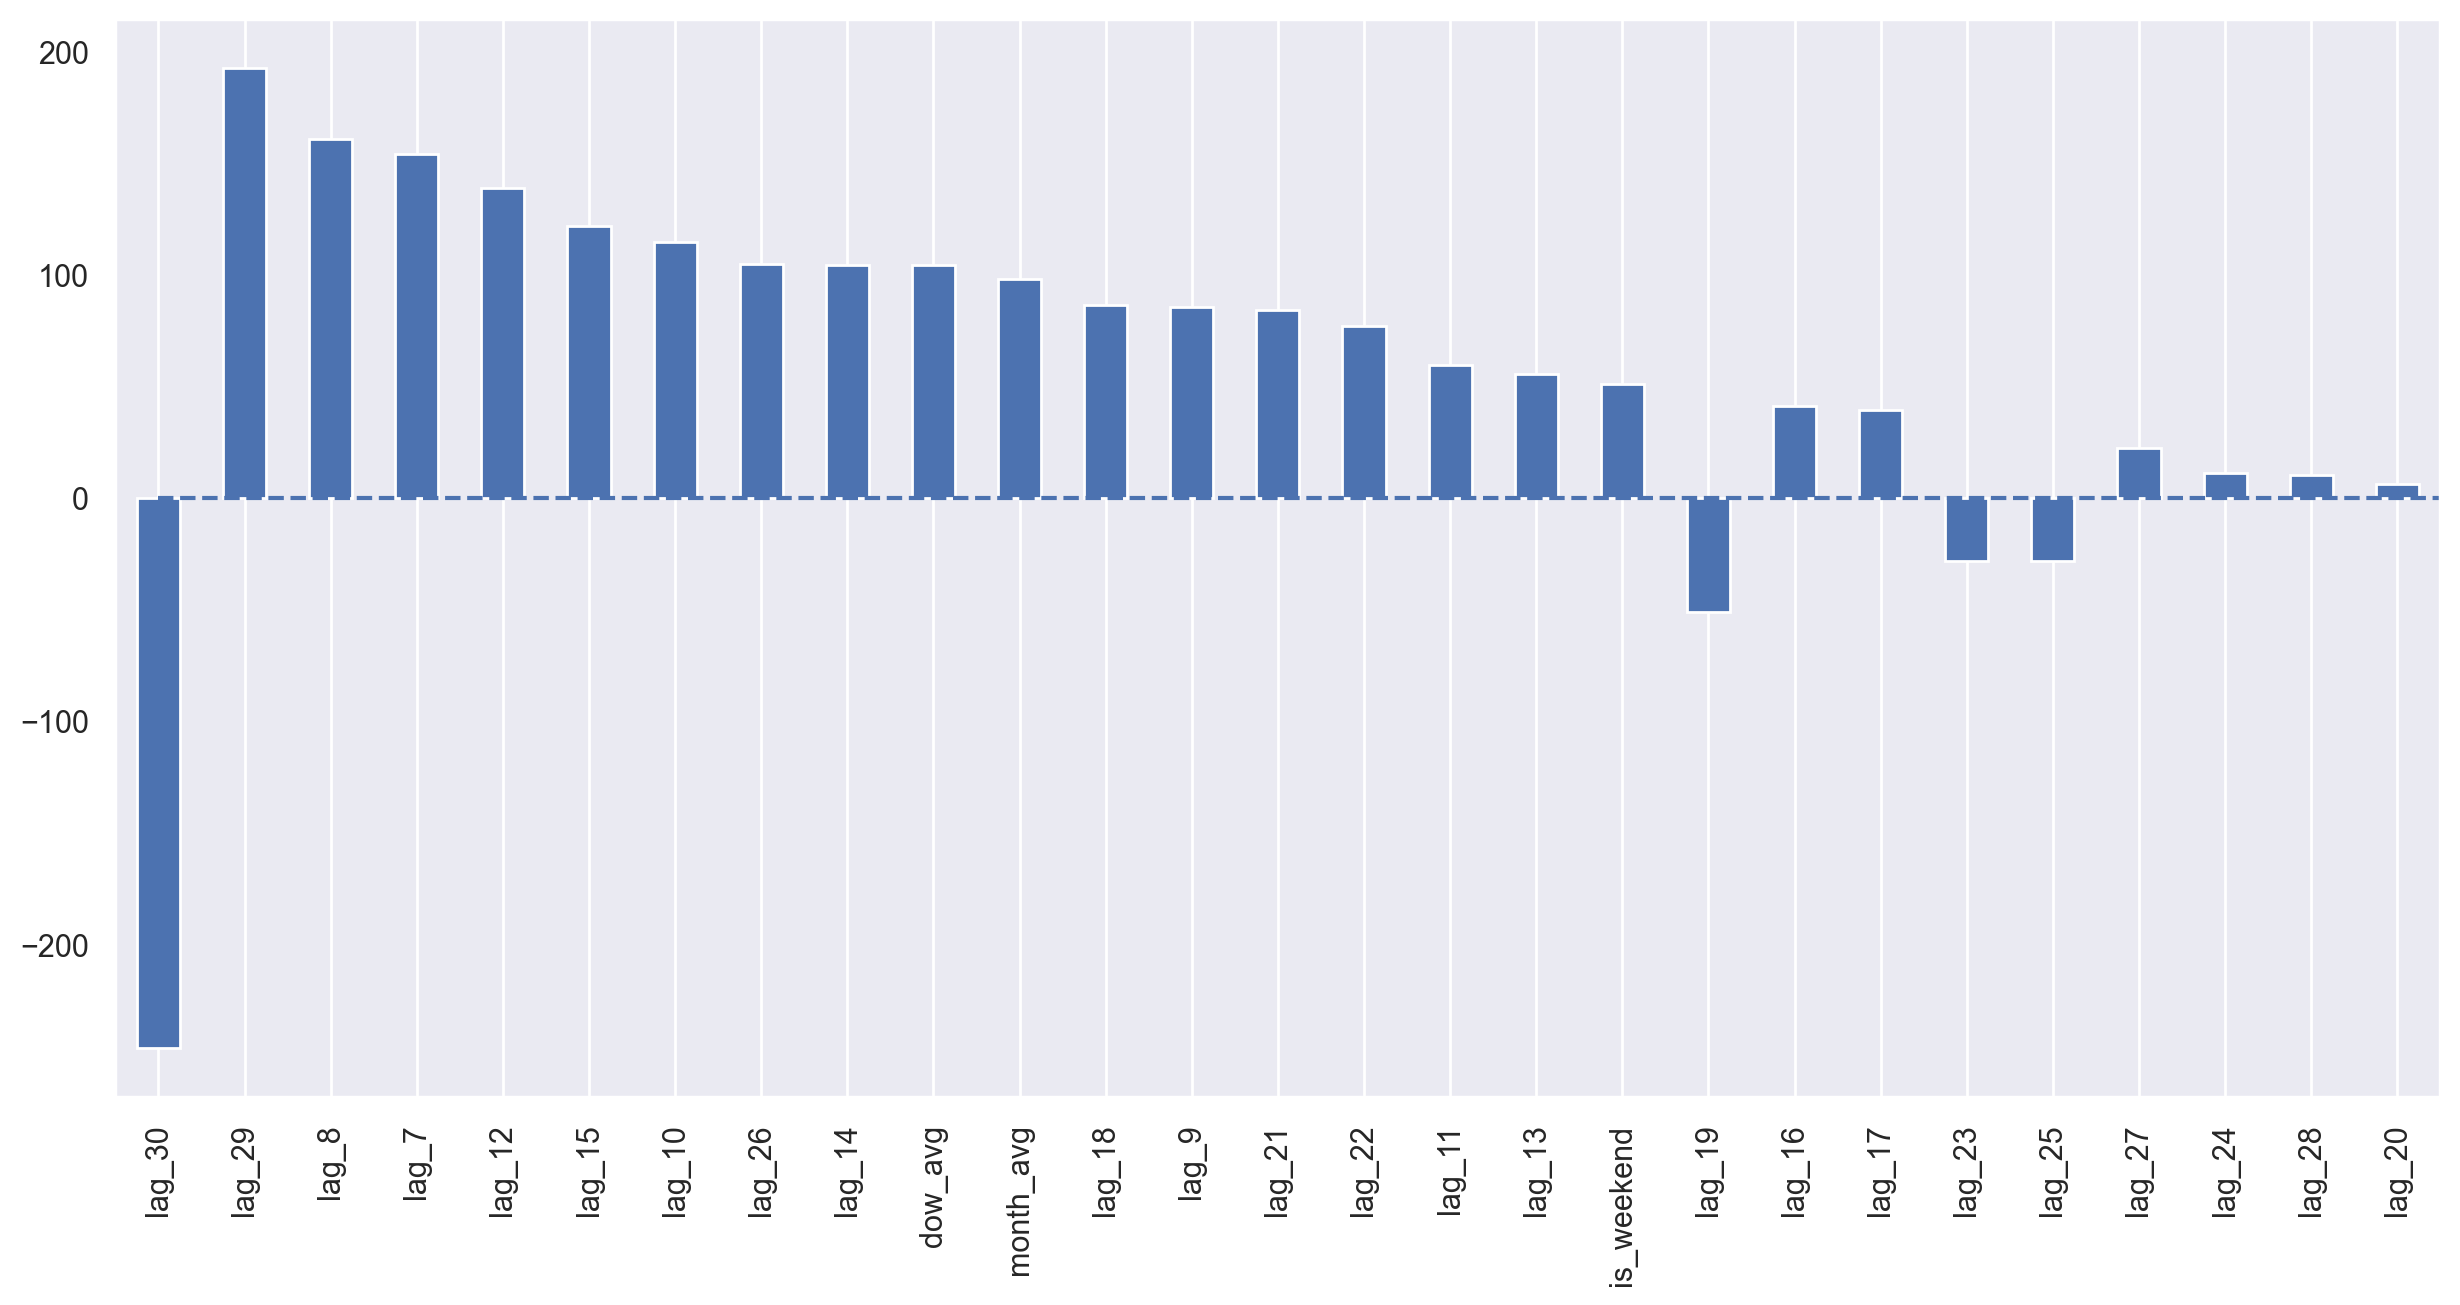

In [229]:
X_train, X_test, y_train, y_test = prepareData(
    ts["cnt"], lag_start=7, lag_end=31, test_size=0.3, target_encoding=True
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

plotModelResults(lr, X_train_scaled, X_test_scaled, y_train, y_test,
                 plot_intervals=True, plot_anomalies=True)
plotCoefficients(lr, X_train.columns)

Regularization and feature selection: Ridge & Lasso

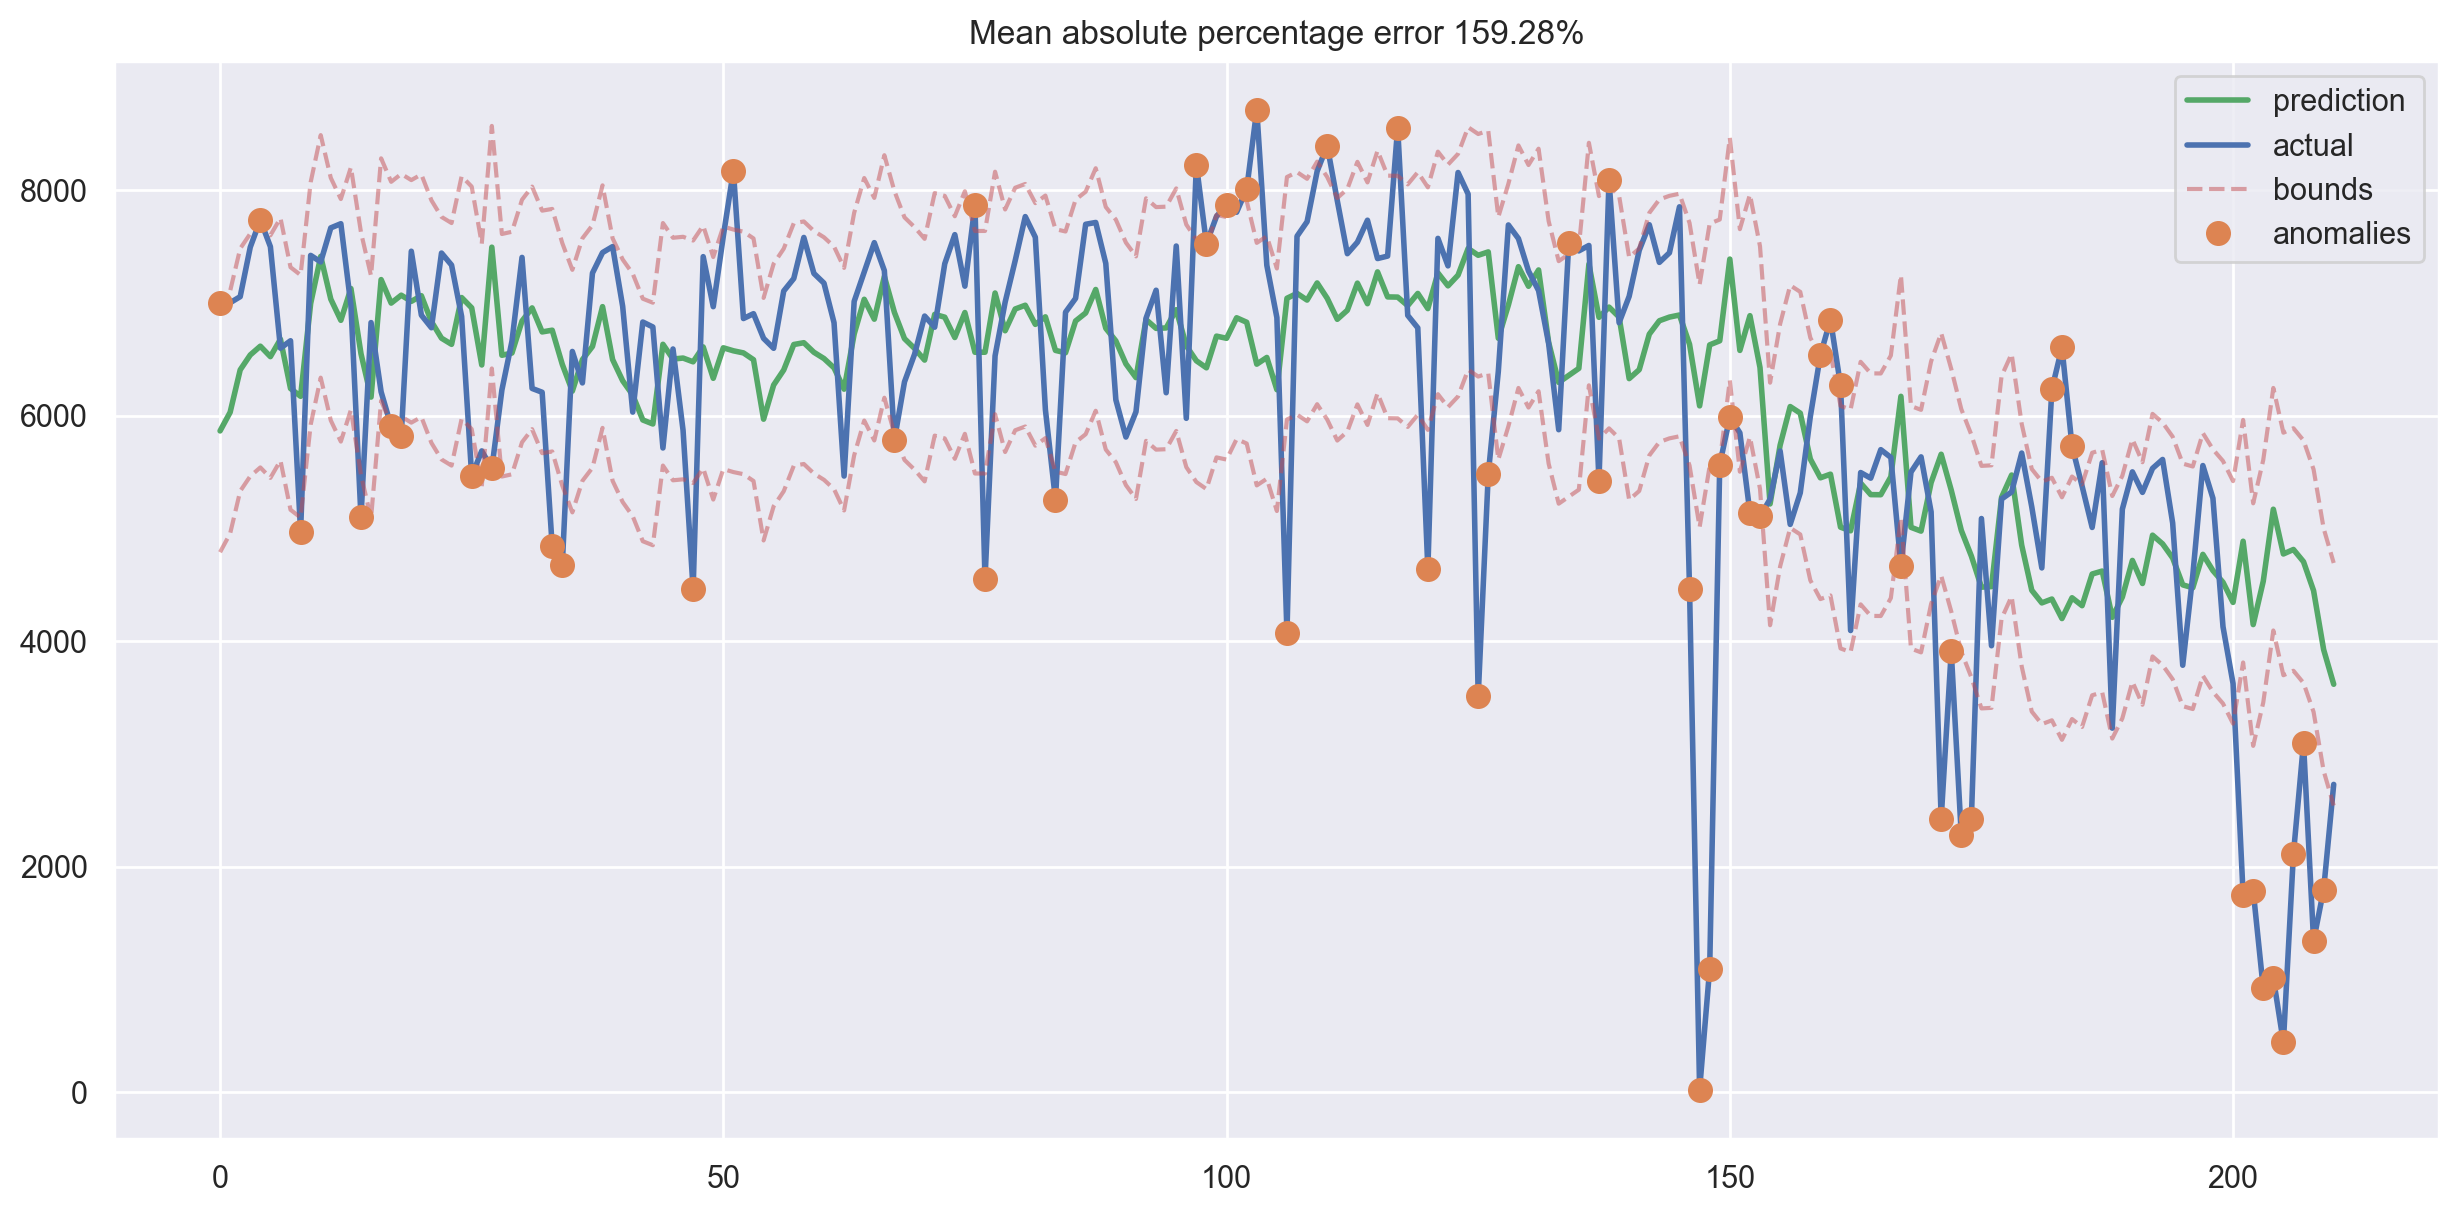

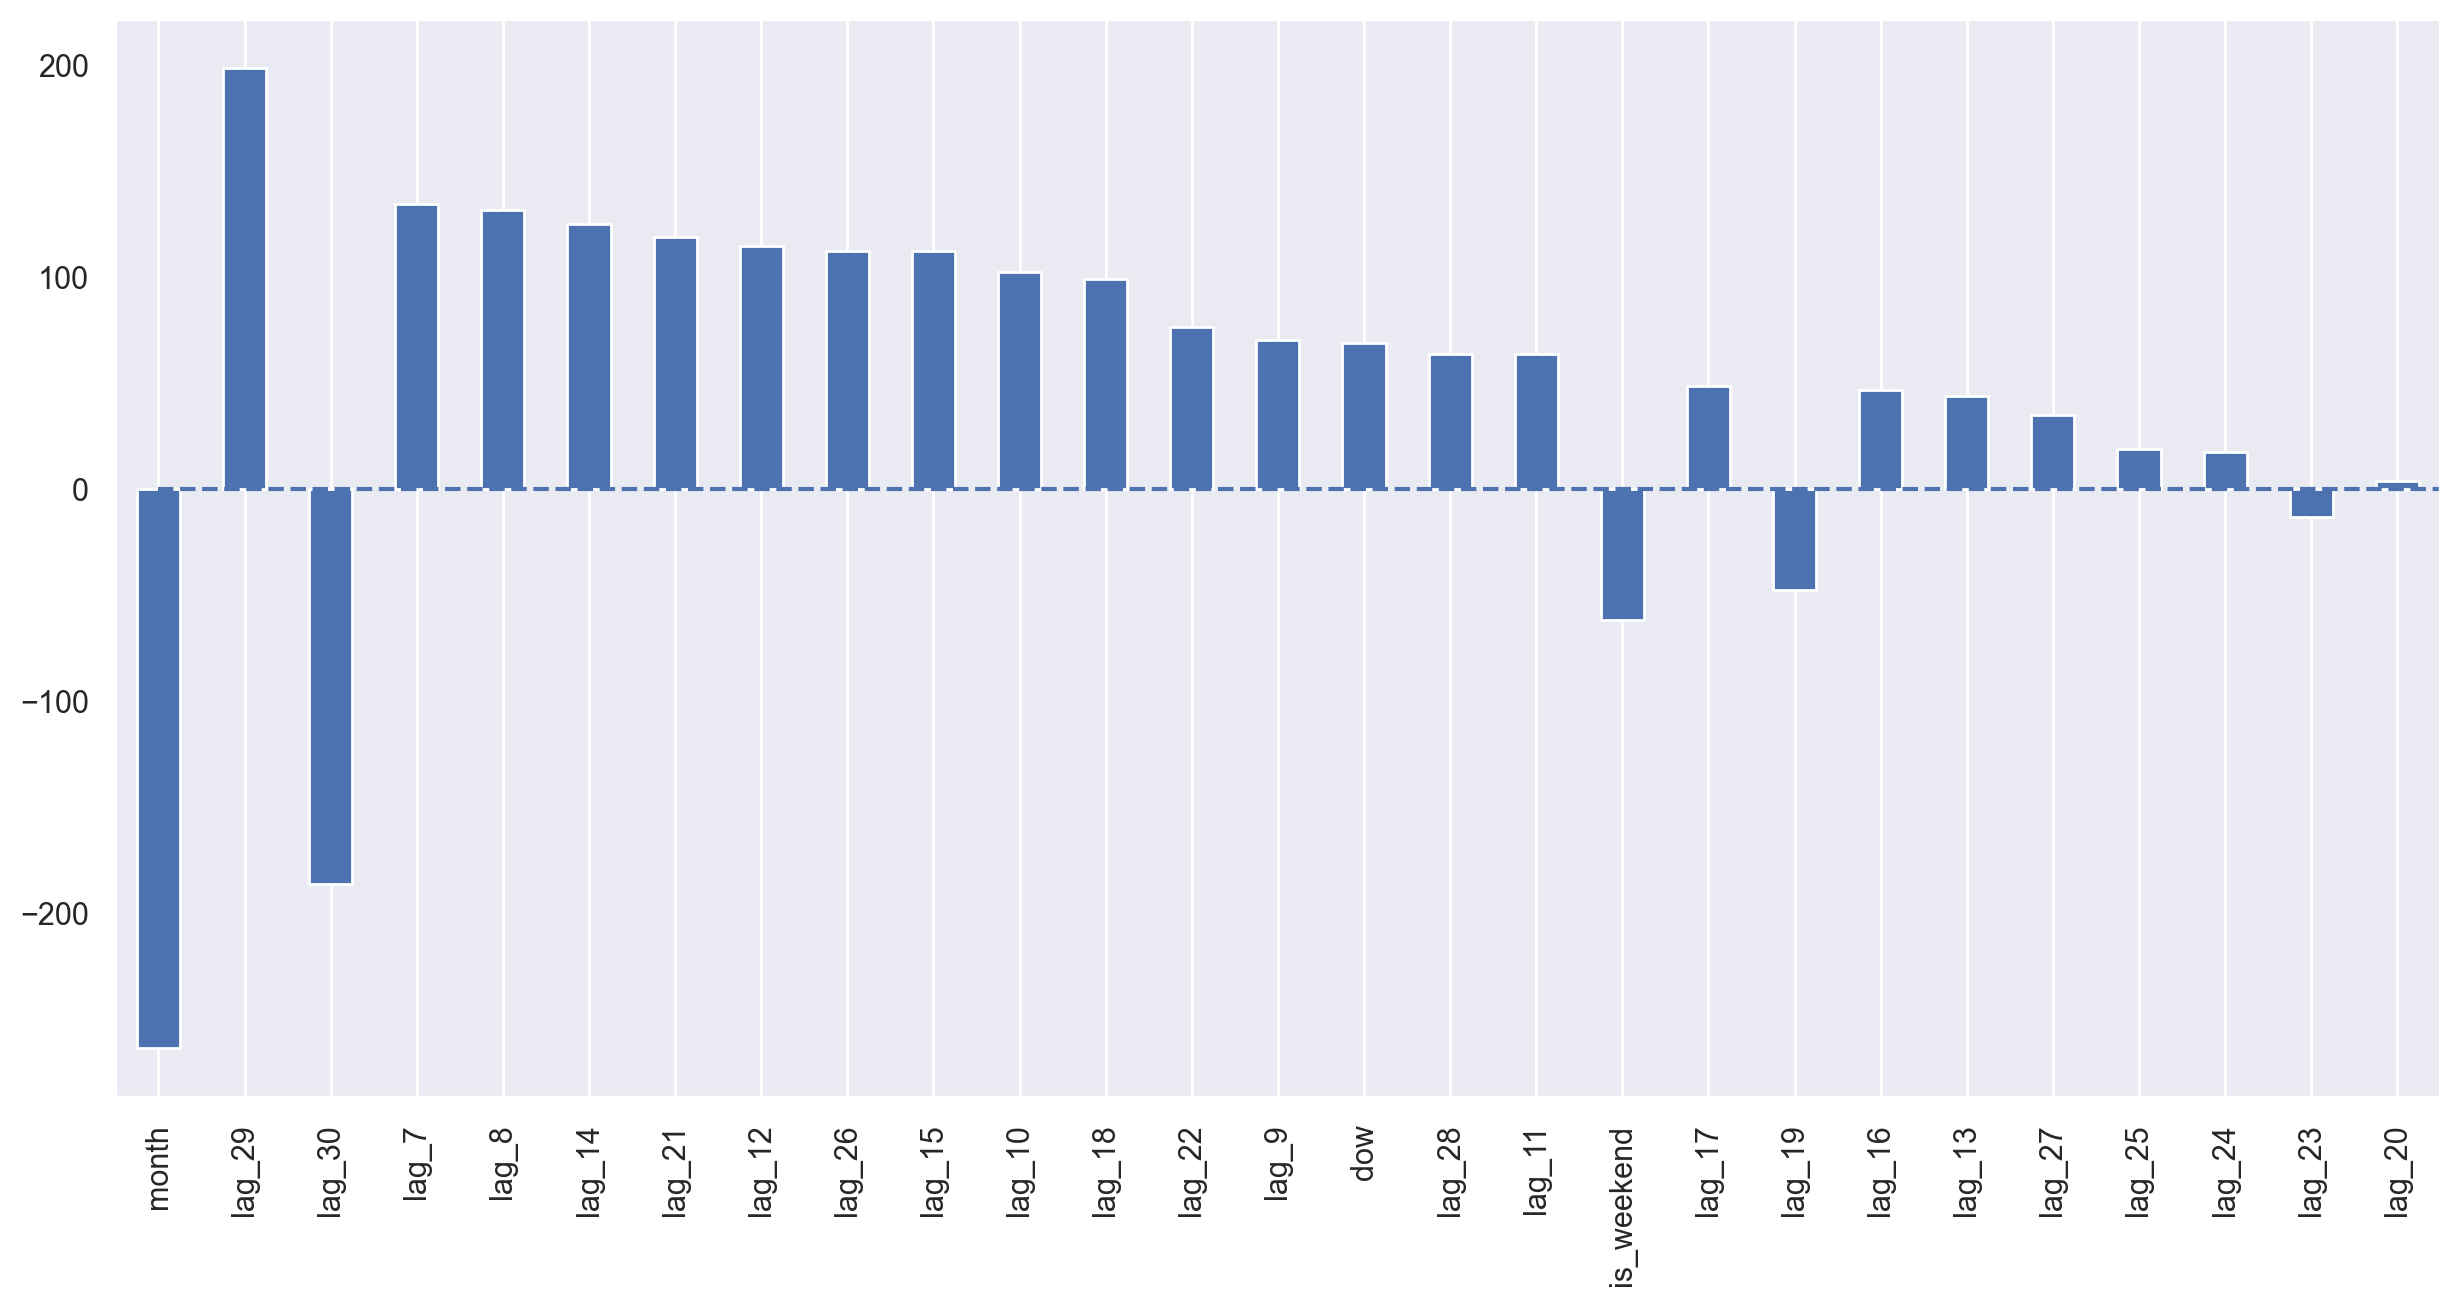

In [230]:
X_train, X_test, y_train, y_test = prepareData(
    ts["cnt"], lag_start=7, lag_end=31, test_size=0.3, target_encoding=False
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = RidgeCV(cv=tscv)
ridge.fit(X_train_scaled, y_train)

plotModelResults(ridge, X_train_scaled, X_test_scaled, y_train, y_test,
                 plot_intervals=True, plot_anomalies=True)
plotCoefficients(ridge, X_train.columns)


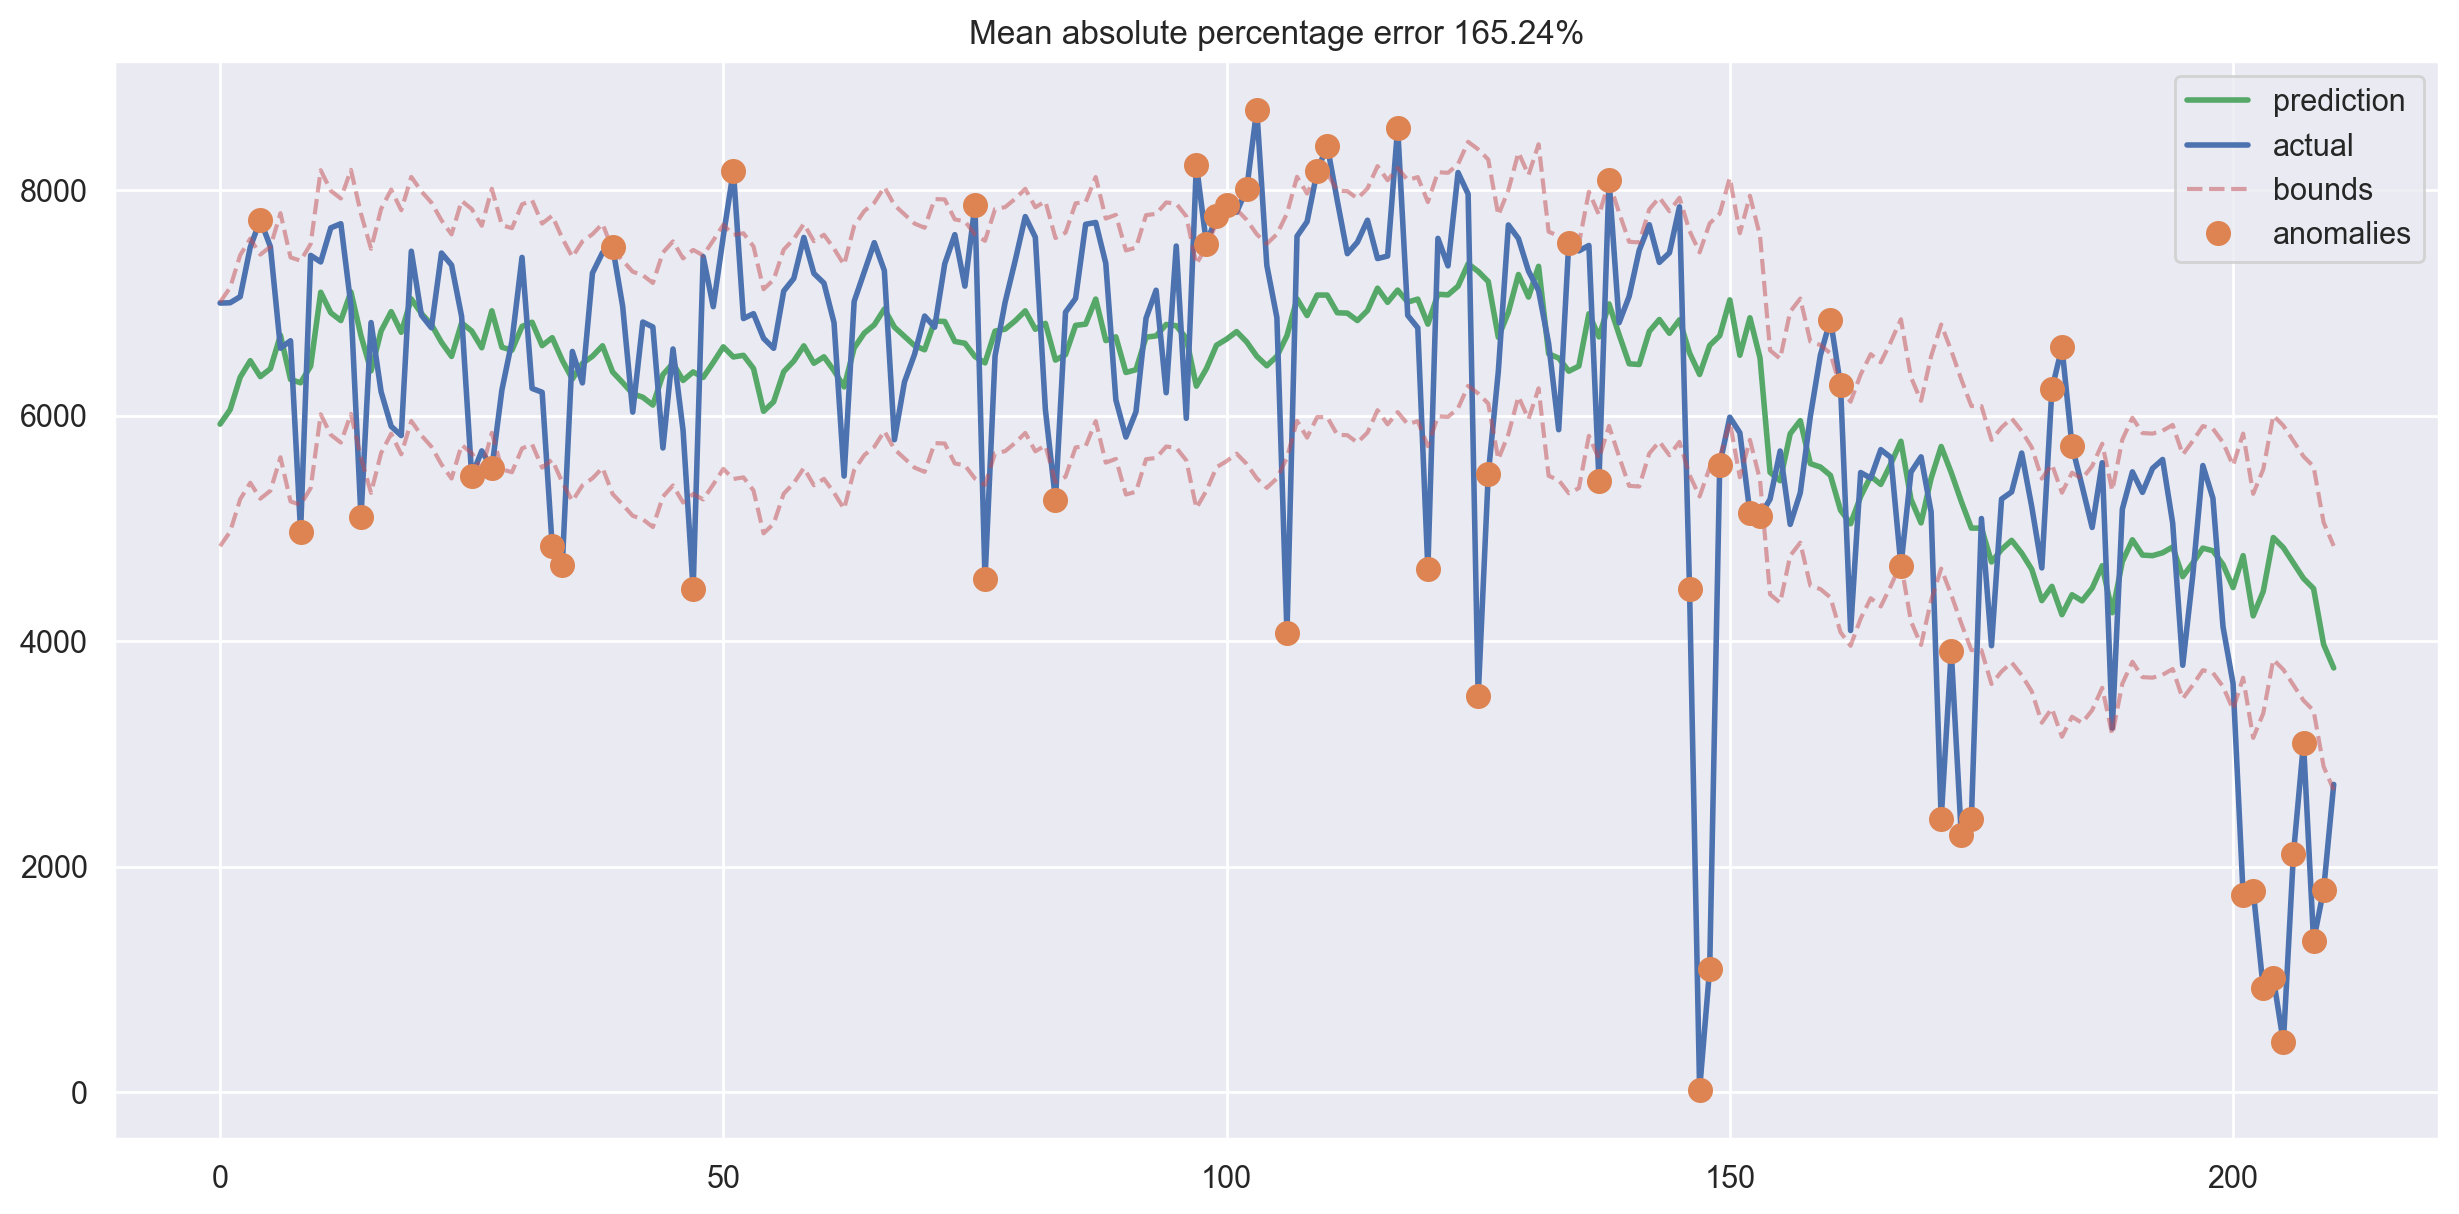

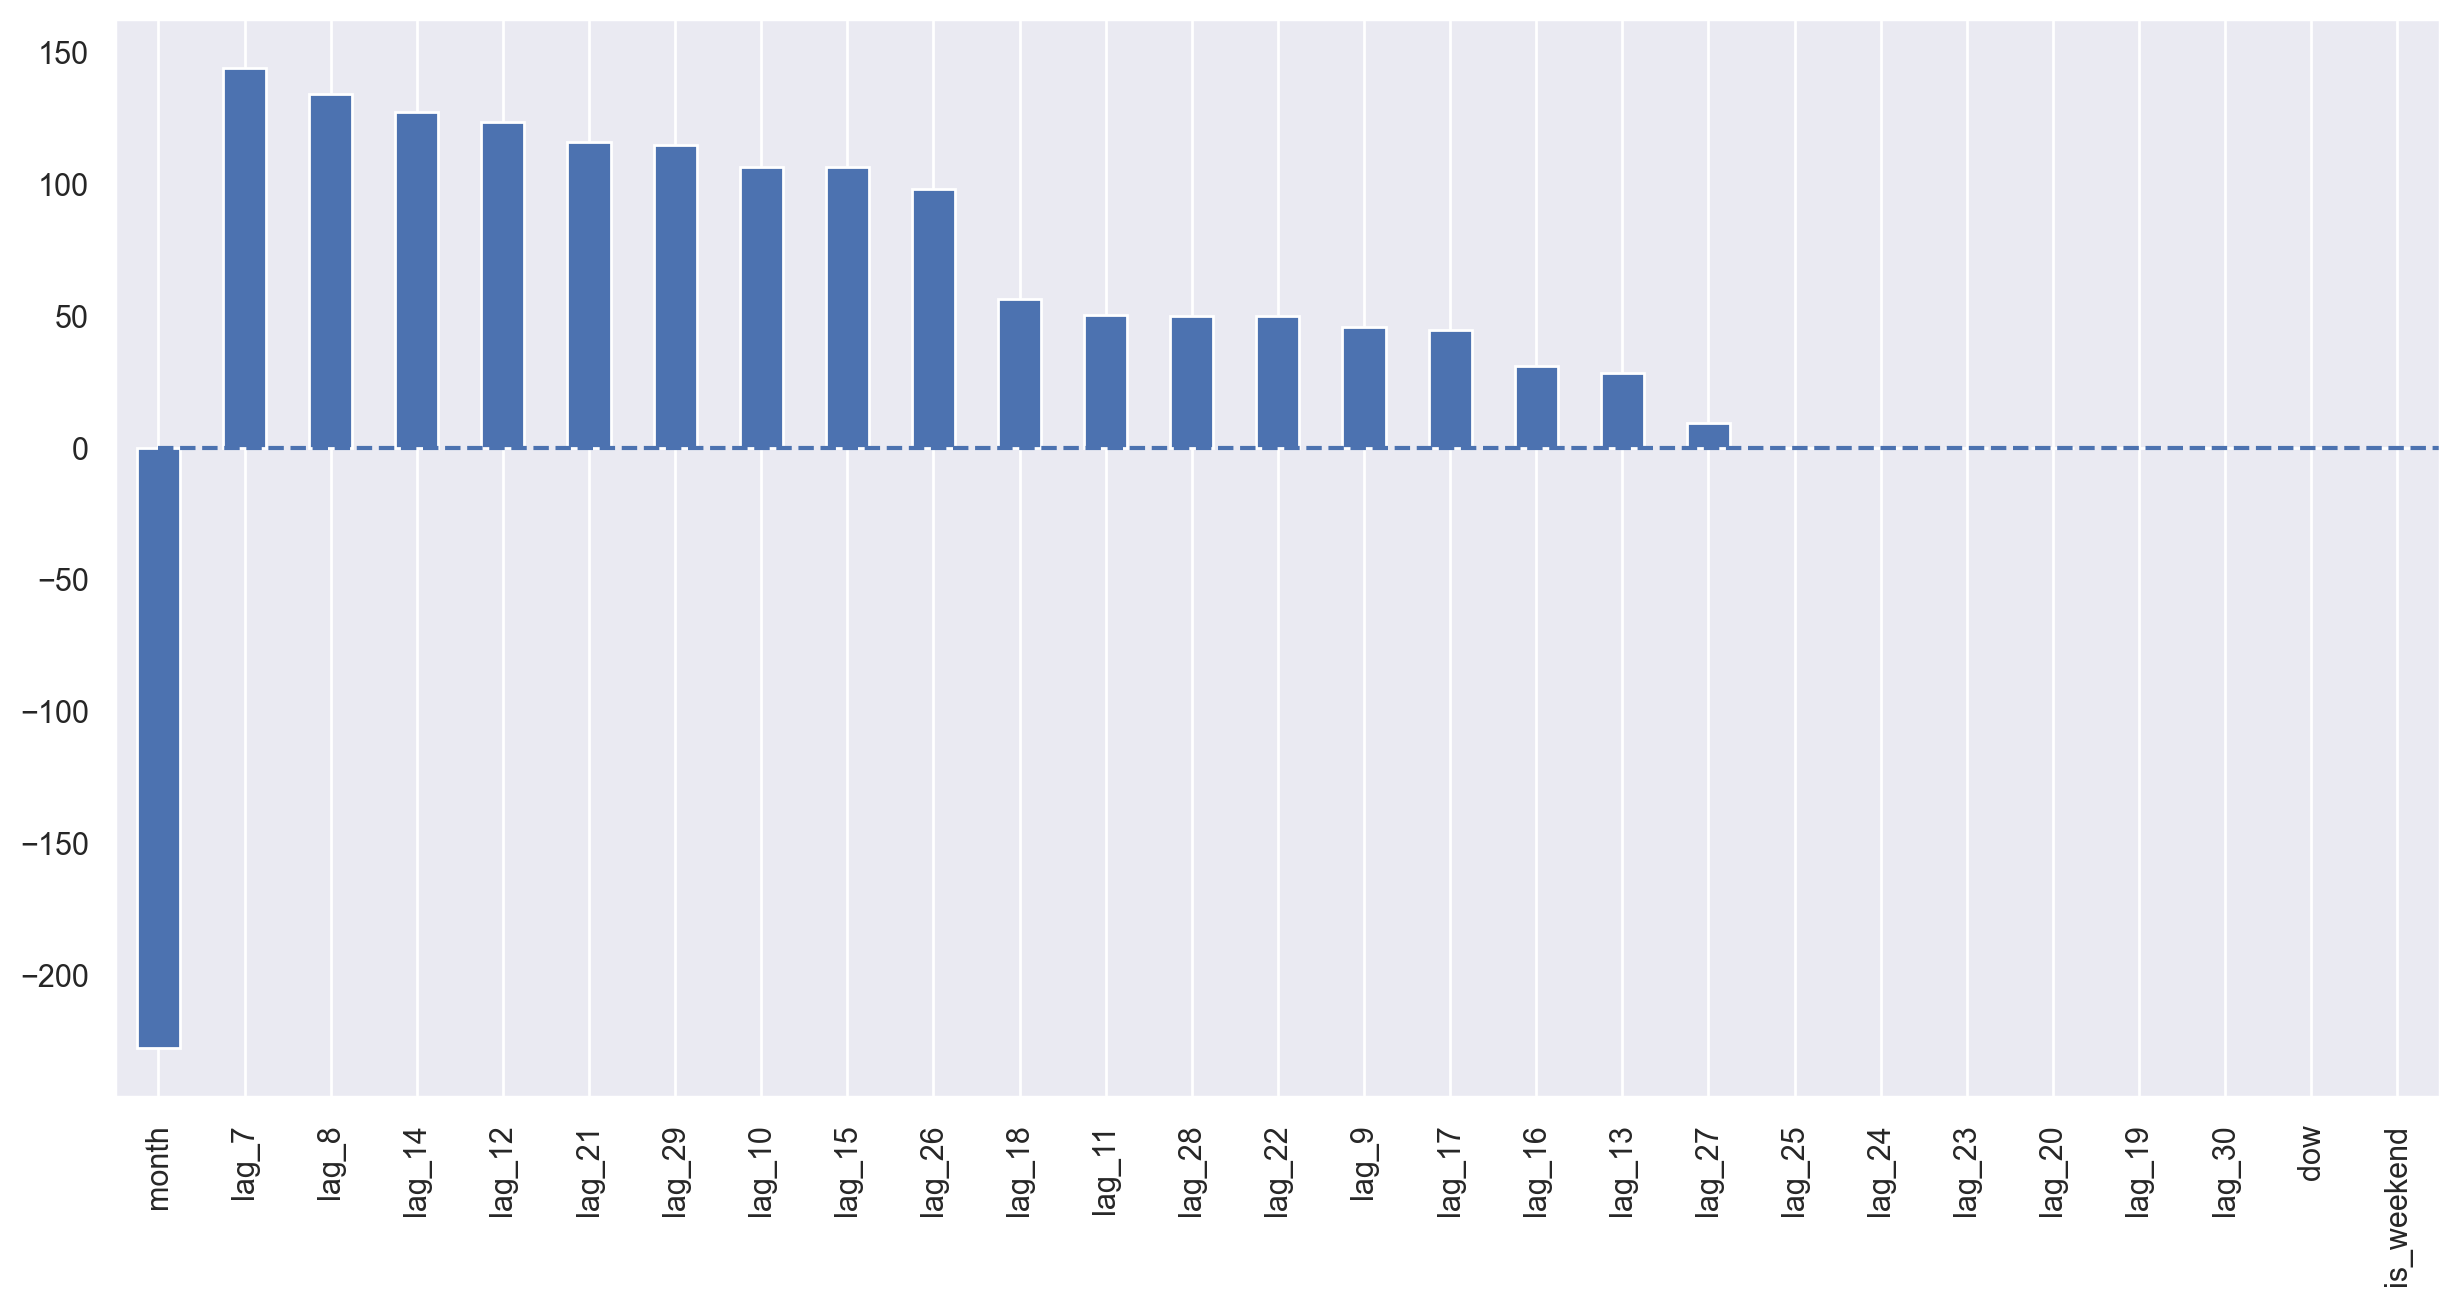

In [231]:
lasso = LassoCV(cv=tscv)
lasso.fit(X_train_scaled, y_train)

plotModelResults(lasso, X_train_scaled, X_test_scaled, y_train, y_test,
                 plot_intervals=True, plot_anomalies=True)
plotCoefficients(lasso, X_train.columns)

Ridge shrinks coefficients but rarely to zero.

Lasso can zero-out unimportant lags so automatic feature selection.

Boosting - XGBoost

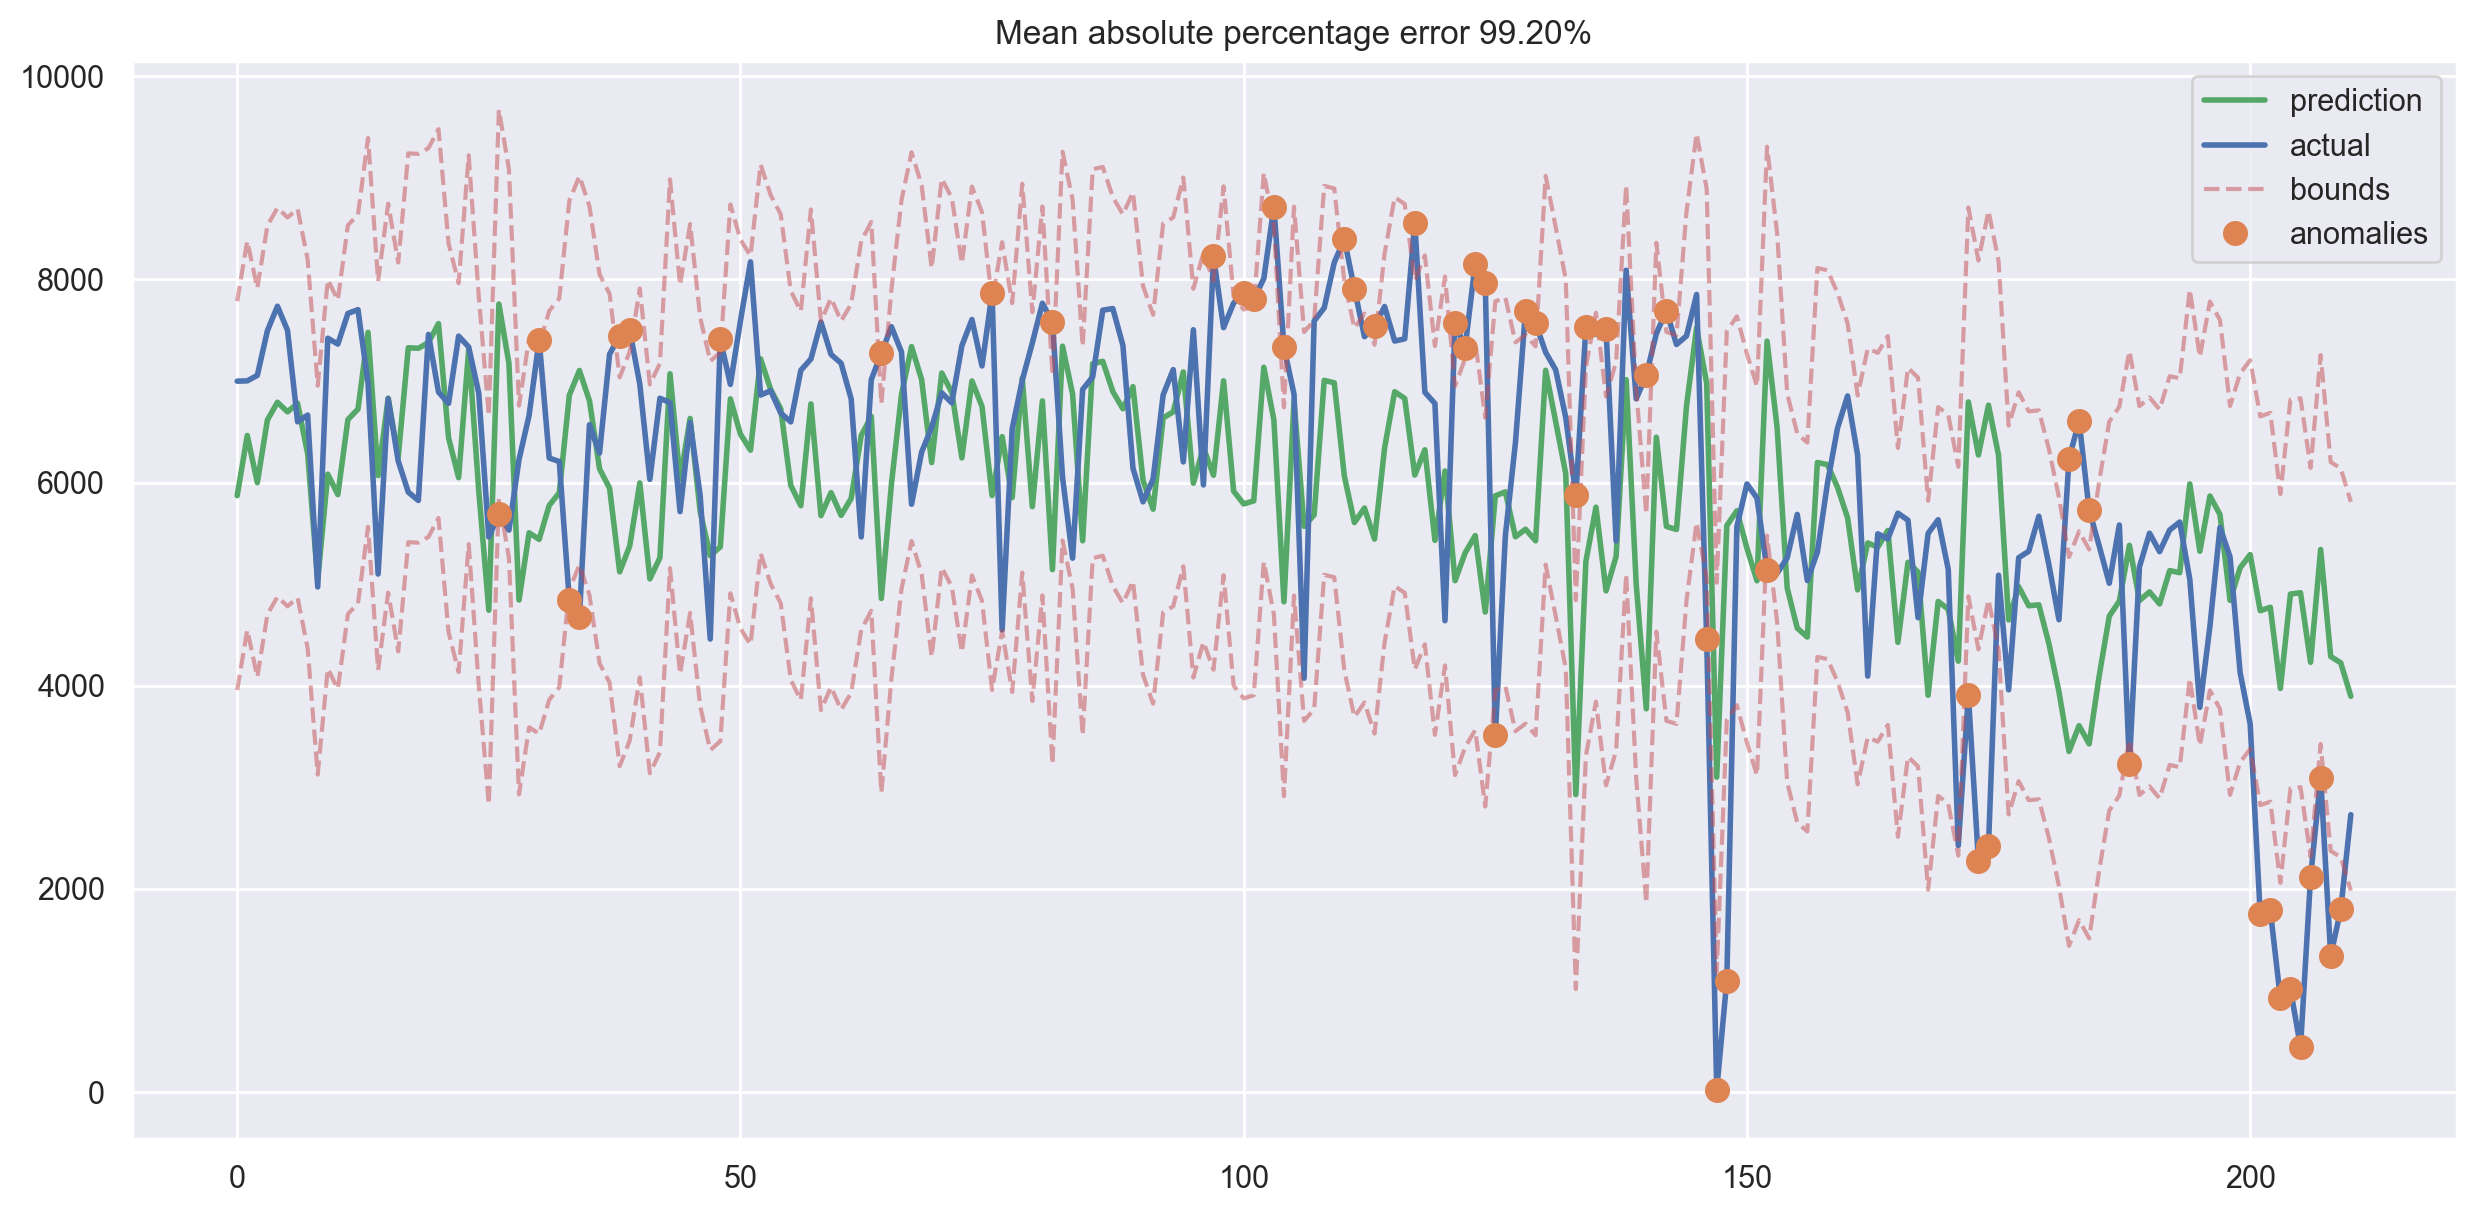

In [232]:
xgb = XGBRegressor(verbosity=0, random_state=17)
xgb.fit(X_train_scaled, y_train)

plotModelResults(xgb, X_train_scaled, X_test_scaled, y_train, y_test,
                 plot_intervals=True, plot_anomalies=True)